In [1]:

from pathlib import Path
import os
RUNNER_SECTION = '02_black_scholes_final_benchmark'
RUNNER_RUN_DIR = Path('/content/drive/MyDrive/MFE_neural_hedging_report_outputs/source_runs/02_black_scholes_final_benchmark')
RUNNER_RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Runner section:", RUNNER_SECTION)
print("Runner run dir:", RUNNER_RUN_DIR)
os.chdir(RUNNER_RUN_DIR)



Runner section: 02_black_scholes_final_benchmark
Runner run dir: /content/drive/MyDrive/MFE_neural_hedging_report_outputs/source_runs/02_black_scholes_final_benchmark


# Final Benchmark Comparison for the Minimal Black--Scholes Hedging Task

This notebook implements the **Priority 1** final benchmark comparison.

It evaluates the selected neural hedge against the following strategies:

1. **No hedge**
2. **Black--Scholes delta hedge** sampled on the discrete rebalancing grid
3. **Discrete-time MSE-optimal hedge**
4. **Polynomial hedge baseline**
5. **Final selected neural hedge**

The goal is to produce a clean final table with:

\[
\text{Premium},\quad
\mathbb{E}[HE],\quad
\operatorname{Std}(HE),\quad
\operatorname{RMSE},\quad
q_{1\%}(HE),\quad
q_{5\%}(HE),\quad
\operatorname{CVaR}_{95},\quad
\operatorname{CVaR}_{99}.
\]

The sign convention is:

\[
HE = V_T - \Phi(S_T),
\]

so **negative hedge error means a shortfall/loss for the option seller**. For tail-risk metrics we define loss as:

\[
L = -HE.
\]

In [2]:
# ============================================================
# 1. Configuration
# ============================================================

from dataclasses import dataclass, asdict
from pathlib import Path
import json
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

@dataclass
class Config:
    # Black--Scholes minimal-task parameters
    S0: float = 1.0
    K: float = 0.9
    T: float = 0.5
    r: float = 0.0
    sigma: float = 0.4
    N: int = 125

    # Monte Carlo path counts
    n_train: int = 100_000
    n_val: int = 30_000
    n_test: int = 100_000

    # Neural network architecture: selected final shared normalized Markov MLP
    width: int = 64
    depth: int = 3
    hidden_activation: str = "tanh"
    output_activation: str = "sigmoid"

    # Training
    batch_size: int = 4096
    learning_rate: float = 1e-3
    max_epochs: int = 250
    patience: int = 20

    # Polynomial hedge baseline
    polynomial_degree: int = 2
    poly_fit_rows: int = 500_000

    # Reproducibility / outputs
    seed: int = 123
    output_dir: str = "final_benchmark_outputs"

    # Set to True for a quick smoke test before the full run
    quick_run: bool = False

cfg = Config()

if cfg.quick_run:
    cfg.n_train = 10_000
    cfg.n_val = 5_000
    cfg.n_test = 10_000
    cfg.max_epochs = 5
    cfg.patience = 3
    cfg.poly_fit_rows = 50_000

out_dir = Path(cfg.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)

np.random.seed(cfg.seed)

print(json.dumps(asdict(cfg), indent=2))

# This notebook uses the self-financing wealth convention
# V_T = premium + sum delta_n (S_{n+1} - S_n).
# That convention is directly valid for r=0, which is the minimal-task setup.
if abs(cfg.r) > 1e-12:
    print("WARNING: This notebook is written for the r=0 minimal task. "
          "If r != 0, discounting / cash-account accrual should be added carefully.")

{
  "S0": 1.0,
  "K": 0.9,
  "T": 0.5,
  "r": 0.0,
  "sigma": 0.4,
  "N": 125,
  "n_train": 100000,
  "n_val": 30000,
  "n_test": 100000,
  "width": 64,
  "depth": 3,
  "hidden_activation": "tanh",
  "output_activation": "sigmoid",
  "batch_size": 4096,
  "learning_rate": 0.001,
  "max_epochs": 250,
  "patience": 20,
  "polynomial_degree": 2,
  "poly_fit_rows": 500000,
  "seed": 123,
  "output_dir": "final_benchmark_outputs",
  "quick_run": false
}


In [3]:
# ============================================================
# 2. Black--Scholes utilities and GBM simulation
# ============================================================

try:
    from scipy.special import ndtr
except Exception as e:
    raise ImportError("This notebook requires scipy.special.ndtr for the normal CDF.") from e


def norm_cdf(x):
    return ndtr(x)


def bs_call_price(S, tau, cfg=cfg):
    """
    Black--Scholes European call price under risk-neutral dynamics.
    Handles scalar or array S and tau.
    """
    S = np.asarray(S, dtype=np.float64)
    tau = np.asarray(tau, dtype=np.float64)

    intrinsic = np.maximum(S - cfg.K, 0.0)
    tau_safe = np.maximum(tau, 1e-12)

    d1 = (np.log(S / cfg.K) + (cfg.r + 0.5 * cfg.sigma**2) * tau_safe) / (cfg.sigma * np.sqrt(tau_safe))
    d2 = d1 - cfg.sigma * np.sqrt(tau_safe)

    price = S * norm_cdf(d1) - cfg.K * np.exp(-cfg.r * tau_safe) * norm_cdf(d2)
    return np.where(tau <= 0, intrinsic, price)


def bs_call_delta(S, tau, cfg=cfg):
    """
    Black--Scholes European call delta.
    Handles scalar or array S and tau.
    """
    S = np.asarray(S, dtype=np.float64)
    tau = np.asarray(tau, dtype=np.float64)

    tau_safe = np.maximum(tau, 1e-12)
    d1 = (np.log(S / cfg.K) + (cfg.r + 0.5 * cfg.sigma**2) * tau_safe) / (cfg.sigma * np.sqrt(tau_safe))
    delta = norm_cdf(d1)

    # At expiry, the call delta is the payoff derivative away from the strike.
    expiry_delta = (S > cfg.K).astype(np.float64)
    return np.where(tau <= 0, expiry_delta, delta)


def simulate_gbm_paths(n_paths, cfg=cfg, seed=None):
    """
    Simulate risk-neutral GBM paths:
        dS_t = r S_t dt + sigma S_t dW_t

    Returns an array of shape (n_paths, N+1), including S_0.
    """
    rng = np.random.default_rng(seed)
    dt = cfg.T / cfg.N
    Z = rng.standard_normal(size=(n_paths, cfg.N)).astype(np.float32)

    increments = (cfg.r - 0.5 * cfg.sigma**2) * dt + cfg.sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(increments, axis=1)

    paths = np.empty((n_paths, cfg.N + 1), dtype=np.float32)
    paths[:, 0] = cfg.S0
    paths[:, 1:] = cfg.S0 * np.exp(log_paths)
    return paths


def call_payoff(S_T, cfg=cfg):
    return np.maximum(S_T - cfg.K, 0.0)


dt = cfg.T / cfg.N
t_grid = np.arange(cfg.N) * dt
tau_grid = cfg.T - t_grid
tau_norm_grid = tau_grid / cfg.T

bs_price_0 = float(bs_call_price(cfg.S0, cfg.T, cfg))
print(f"Black--Scholes initial price: {bs_price_0:.8f}")

Black--Scholes initial price: 0.16411068


In [4]:
# ============================================================
# 3. Generate independent train / validation / test paths
# ============================================================

start = time.time()

paths_train = simulate_gbm_paths(cfg.n_train, cfg, seed=cfg.seed + 1)
paths_val = simulate_gbm_paths(cfg.n_val, cfg, seed=cfg.seed + 2)
paths_test = simulate_gbm_paths(cfg.n_test, cfg, seed=cfg.seed + 3)

payoff_train = call_payoff(paths_train[:, -1], cfg)
payoff_val = call_payoff(paths_val[:, -1], cfg)
payoff_test = call_payoff(paths_test[:, -1], cfg)

print(f"Generated paths in {time.time() - start:.1f}s")
print("Train paths:", paths_train.shape)
print("Val paths:  ", paths_val.shape)
print("Test paths: ", paths_test.shape)

# Basic simulation sanity checks
mc_call = np.mean(payoff_test) * np.exp(-cfg.r * cfg.T)
mean_ST = np.mean(paths_test[:, -1])
theory_mean_ST = cfg.S0 * np.exp(cfg.r * cfg.T)
var_log_return = np.var(np.log(paths_test[:, -1] / cfg.S0))
theory_var_log_return = cfg.sigma**2 * cfg.T

print("\nSimulation checks:")
print(f"MC call price estimate: {mc_call:.8f}")
print(f"BS call price:          {bs_price_0:.8f}")
print(f"E[S_T] MC:              {mean_ST:.8f}")
print(f"E[S_T] theory:          {theory_mean_ST:.8f}")
print(f"Var(log S_T/S_0) MC:    {var_log_return:.8f}")
print(f"Var(log S_T/S_0) theory:{theory_var_log_return:.8f}")

Generated paths in 0.9s
Train paths: (100000, 126)
Val paths:   (30000, 126)
Test paths:  (100000, 126)

Simulation checks:
MC call price estimate: 0.16483206
BS call price:          0.16411068
E[S_T] MC:              1.00137091
E[S_T] theory:          1.00000000
Var(log S_T/S_0) MC:    0.07971355
Var(log S_T/S_0) theory:0.08000000


In [5]:
# ============================================================
# 4. Hedge-error and metric utilities
# ============================================================

def hedge_error(paths, deltas, premium, cfg=cfg):
    """
    Terminal hedging error:
        HE = V_T - payoff
           = premium + sum delta_n (S_{n+1} - S_n) - payoff(S_T)

    paths:  shape (M, N+1)
    deltas: shape (M, N)
    """
    dS = paths[:, 1:] - paths[:, :-1]
    terminal_wealth = premium + np.sum(deltas * dS, axis=1)
    payoff = call_payoff(paths[:, -1], cfg)
    return terminal_wealth - payoff


def cvar_loss_from_he(he, alpha=0.95):
    """
    CVaR_alpha of seller loss L = -HE.
    """
    loss = -np.asarray(he)
    var_alpha = np.quantile(loss, alpha)
    tail = loss[loss >= var_alpha]
    return float(np.mean(tail))


def strategy_metrics(name, he, premium, runtime=None):
    """
    Returns a dictionary of final benchmark metrics.
    """
    he = np.asarray(he)
    loss = -he
    out = {
        "Strategy": name,
        "Premium": float(premium),
        "Mean HE": float(np.mean(he)),
        "Std HE": float(np.std(he, ddof=1)),
        "RMSE": float(np.sqrt(np.mean(he**2))),
        "HE q01": float(np.quantile(he, 0.01)),
        "HE q05": float(np.quantile(he, 0.05)),
        "Loss VaR95": float(np.quantile(loss, 0.95)),
        "Loss CVaR95": cvar_loss_from_he(he, 0.95),
        "Loss VaR99": float(np.quantile(loss, 0.99)),
        "Loss CVaR99": cvar_loss_from_he(he, 0.99),
    }
    if runtime is not None:
        out["Runtime (s)"] = float(runtime)
    return out

In [6]:
# ============================================================
# 5. Analytic benchmark hedges
# ============================================================

def bs_delta_hedge(paths, cfg=cfg):
    """
    Black--Scholes delta sampled at the discrete rebalancing dates.
    """
    S = paths[:, :-1].astype(np.float64)
    tau = tau_grid[None, :]
    deltas = bs_call_delta(S, tau, cfg)
    return deltas.astype(np.float32)


def dt_mse_optimal_delta_hedge(paths, cfg=cfg):
    """
    Discrete-time MSE-optimal hedge for the r=0 Black--Scholes minimal task.

    For stock martingale S and payoff H = (S_T-K)^+, the optimal predictable
    coefficient on each increment is

        delta_n^DT = E[H (S_{n+1}-S_n) | S_n] / E[(S_{n+1}-S_n)^2 | S_n].

    In the Black--Scholes lognormal model this has a closed-form expression.

    This benchmark is the fairest comparison for the neural hedge because it
    matches the finite rebalancing grid and MSE objective.
    """
    if abs(cfg.r) > 1e-12:
        raise ValueError("This closed-form DT benchmark is implemented for r=0.")

    h = cfg.T / cfg.N
    S = paths[:, :-1].astype(np.float64)
    tau = tau_grid[None, :].astype(np.float64)
    tau_safe = np.maximum(tau, 1e-12)

    sqrt_tau = np.sqrt(tau_safe)
    d1 = (np.log(S / cfg.K) + 0.5 * cfg.sigma**2 * tau_safe) / (cfg.sigma * sqrt_tau)
    d2 = d1 - cfg.sigma * sqrt_tau

    C = bs_call_price(S, tau, cfg)

    shift = cfg.sigma * h / sqrt_tau
    numerator = (
        S**2 * np.exp(cfg.sigma**2 * h) * norm_cdf(d1 + shift)
        - cfg.K * S * norm_cdf(d2 + shift)
        - S * C
    )
    denominator = S**2 * (np.exp(cfg.sigma**2 * h) - 1.0)

    delta = numerator / denominator
    return delta.astype(np.float32)


# Compute benchmark deltas on test paths
start = time.time()
deltas_no = np.zeros((cfg.n_test, cfg.N), dtype=np.float32)
he_no = hedge_error(paths_test, deltas_no, bs_price_0, cfg)
time_no = time.time() - start

start = time.time()
deltas_bs = bs_delta_hedge(paths_test, cfg)
he_bs = hedge_error(paths_test, deltas_bs, bs_price_0, cfg)
time_bs = time.time() - start

start = time.time()
deltas_dt = dt_mse_optimal_delta_hedge(paths_test, cfg)
he_dt = hedge_error(paths_test, deltas_dt, bs_price_0, cfg)
time_dt = time.time() - start

benchmark_rows = [
    strategy_metrics("No hedge", he_no, bs_price_0, runtime=time_no),
    strategy_metrics("Black--Scholes delta", he_bs, bs_price_0, runtime=time_bs),
    strategy_metrics("Discrete-time MSE-optimal", he_dt, bs_price_0, runtime=time_dt),
]

pd.DataFrame(benchmark_rows)

,Strategy,Premium,Mean HE,Std HE,RMSE,HE q01,HE q05,Loss VaR95,Loss CVaR95,Loss VaR99,Loss CVaR99,Runtime (s)
0,No hedge,0.164111,-0.000721,0.227257,0.227257,-0.791519,-0.465571,0.465571,0.669267,0.791519,0.992283,0.058062
1,Black--Scholes delta,0.164111,-0.000046,0.007810,0.007810,-0.021436,-0.012874,0.012874,0.018105,0.021436,0.026636,0.502376
2,Discrete-time MSE-optimal,0.164111,-0.000045,0.007810,0.007810,-0.021468,-0.012886,0.012886,0.018124,0.021468,0.026652,1.803190


In [7]:
# ============================================================
# 6. Polynomial hedge baseline
# ============================================================

def polynomial_design(x1, x2, degree=2):
    """
    Polynomial features in two variables x1 and x2 up to total degree.
    Includes an intercept.
    """
    cols = [np.ones_like(x1)]
    for total_degree in range(1, degree + 1):
        for power_x1 in range(total_degree + 1):
            power_x2 = total_degree - power_x1
            cols.append((x1 ** power_x1) * (x2 ** power_x2))
    return np.column_stack(cols)


def fit_polynomial_to_dt_delta(paths, cfg=cfg, degree=2, n_rows=500_000, seed=123):
    """
    Fits a simple polynomial approximation to the analytic DT-optimal delta.
    This is a non-neural function-approximation benchmark.

    To avoid building a huge design matrix, we sample random (path,time) pairs.
    """
    rng = np.random.default_rng(seed)
    M = paths.shape[0]
    N = cfg.N

    # Compute DT labels on training paths.
    dt_labels = dt_mse_optimal_delta_hedge(paths, cfg)

    n_rows = min(n_rows, M * N)
    path_idx = rng.integers(0, M, size=n_rows)
    time_idx = rng.integers(0, N, size=n_rows)

    S_sample = paths[path_idx, time_idx].astype(np.float64)
    x1 = np.log(S_sample / cfg.K)
    x2 = tau_norm_grid[time_idx].astype(np.float64)
    y = dt_labels[path_idx, time_idx].astype(np.float64)

    X = polynomial_design(x1, x2, degree)
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coef


def predict_polynomial_delta(paths, coef, cfg=cfg, degree=2, path_batch=10_000):
    """
    Predict polynomial hedge deltas in path batches to avoid large memory spikes.
    """
    M = paths.shape[0]
    out = np.empty((M, cfg.N), dtype=np.float32)

    for start in range(0, M, path_batch):
        end = min(start + path_batch, M)
        S = paths[start:end, :-1].astype(np.float64)
        x1 = np.log(S / cfg.K).reshape(-1)
        x2 = np.broadcast_to(tau_norm_grid[None, :], S.shape).reshape(-1)

        X = polynomial_design(x1, x2, degree)
        pred = X @ coef

        # For a European call hedge, clipping to [0,1] is economically natural.
        pred = np.clip(pred, 0.0, 1.0)
        out[start:end, :] = pred.reshape(end - start, cfg.N).astype(np.float32)

    return out


start = time.time()
poly_coef = fit_polynomial_to_dt_delta(
    paths_train,
    cfg=cfg,
    degree=cfg.polynomial_degree,
    n_rows=cfg.poly_fit_rows,
    seed=cfg.seed + 10,
)
deltas_poly = predict_polynomial_delta(paths_test, poly_coef, cfg=cfg, degree=cfg.polynomial_degree)
he_poly = hedge_error(paths_test, deltas_poly, bs_price_0, cfg)
time_poly = time.time() - start

benchmark_rows.append(strategy_metrics(f"Polynomial degree {cfg.polynomial_degree}", he_poly, bs_price_0, runtime=time_poly))
pd.DataFrame(benchmark_rows)

,Strategy,Premium,Mean HE,Std HE,RMSE,HE q01,HE q05,Loss VaR95,Loss CVaR95,Loss VaR99,Loss CVaR99,Runtime (s)
0,No hedge,0.164111,-0.000721,0.227257,0.227257,-0.791519,-0.465571,0.465571,0.669267,0.791519,0.992283,0.058062
1,Black--Scholes delta,0.164111,-0.000046,0.007810,0.007810,-0.021436,-0.012874,0.012874,0.018105,0.021436,0.026636,0.502376
2,Discrete-time MSE-optimal,0.164111,-0.000045,0.007810,0.007810,-0.021468,-0.012886,0.012886,0.018124,0.021468,0.026652,1.803190
3,Polynomial degree 2,0.164111,0.000014,0.022183,0.022183,-0.035282,-0.028673,0.028673,0.032729,0.035282,0.038453,3.046859


In [8]:
# ============================================================
# 7. Neural hedge model
# ============================================================

try:
    import tensorflow as tf
except Exception as e:
    raise ImportError(
        "TensorFlow is required for the neural hedge section. "
        "Install tensorflow or run this section in the same environment as the tuning notebook."
    ) from e

tf.keras.utils.set_random_seed(cfg.seed)


class SharedMarkovHedge(tf.keras.Model):
    """
    Shared Markov MLP:
        delta_n = f_theta(log(S_n/K), tau_n/T)

    The same neural network is reused at every hedging date.
    """
    def __init__(self, cfg, initial_premium):
        super().__init__()
        self.cfg = cfg
        self.premium = self.add_weight(
            name="premium",
            shape=(),
            initializer=tf.keras.initializers.Constant(initial_premium),
            trainable=True,
            dtype=tf.float32,
        )

        layers = [tf.keras.layers.InputLayer(shape=(2,))]
        for _ in range(cfg.depth):
            layers.append(tf.keras.layers.Dense(cfg.width, activation=cfg.hidden_activation))
        layers.append(tf.keras.layers.Dense(1, activation=cfg.output_activation))
        self.net = tf.keras.Sequential(layers)

        self.tau_norm_tf = tf.constant(tau_norm_grid.astype(np.float32), dtype=tf.float32)

    def make_features(self, paths):
        S = paths[:, :-1]
        log_m = tf.math.log(S / tf.constant(self.cfg.K, dtype=tf.float32))
        tau_feat = tf.broadcast_to(self.tau_norm_tf[None, :], tf.shape(S))
        return tf.stack([log_m, tau_feat], axis=-1)

    def call(self, paths, training=False):
        features = self.make_features(paths)
        batch_size = tf.shape(paths)[0]

        flat_features = tf.reshape(features, (-1, 2))
        flat_delta = self.net(flat_features, training=training)
        deltas = tf.reshape(flat_delta[:, 0], (batch_size, self.cfg.N))

        dS = paths[:, 1:] - paths[:, :-1]
        payoff = tf.nn.relu(paths[:, -1] - tf.constant(self.cfg.K, dtype=tf.float32))

        terminal_wealth = self.premium + tf.reduce_sum(deltas * dS, axis=1)
        he = terminal_wealth - payoff
        return he, deltas


def train_neural_hedge(paths_train, paths_val, cfg=cfg, initial_premium=bs_price_0):
    model = SharedMarkovHedge(cfg, initial_premium)
    optimizer = tf.keras.optimizers.Adam(learning_rate=cfg.learning_rate)

    train_ds = (
        tf.data.Dataset.from_tensor_slices(paths_train.astype(np.float32))
        .shuffle(buffer_size=min(len(paths_train), 50_000), seed=cfg.seed, reshuffle_each_iteration=True)
        .batch(cfg.batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        tf.data.Dataset.from_tensor_slices(paths_val.astype(np.float32))
        .batch(cfg.batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    @tf.function
    def train_step(batch):
        with tf.GradientTape() as tape:
            he, _ = model(batch, training=True)
            loss = tf.reduce_mean(tf.square(he))
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    @tf.function
    def eval_step(batch):
        he, _ = model(batch, training=False)
        return tf.reduce_sum(tf.square(he)), tf.shape(he)[0]

    best_val = np.inf
    best_weights = None
    wait = 0
    history = []

    start_time = time.time()

    for epoch in range(1, cfg.max_epochs + 1):
        train_losses = []
        for batch in train_ds:
            loss = train_step(batch)
            train_losses.append(float(loss.numpy()))

        val_sse = 0.0
        val_n = 0
        for batch in val_ds:
            sse, n = eval_step(batch)
            val_sse += float(sse.numpy())
            val_n += int(n.numpy())

        train_loss = float(np.mean(train_losses))
        val_loss = val_sse / val_n

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "premium": float(model.premium.numpy()),
            "elapsed_s": time.time() - start_time,
        })

        improved = val_loss < best_val - 1e-10
        if improved:
            best_val = val_loss
            best_weights = model.get_weights()
            wait = 0
        else:
            wait += 1

        if epoch == 1 or epoch % 10 == 0 or improved:
            print(
                f"Epoch {epoch:03d} | train {train_loss:.8e} | val {val_loss:.8e} "
                f"| premium {float(model.premium.numpy()):.8f} | wait {wait}"
            )

        if wait >= cfg.patience:
            print(f"Early stopping at epoch {epoch}. Best val loss = {best_val:.8e}")
            break

    if best_weights is not None:
        model.set_weights(best_weights)

    history_df = pd.DataFrame(history)
    return model, history_df, time.time() - start_time


def predict_neural_hedge(model, paths, cfg=cfg):
    ds = tf.data.Dataset.from_tensor_slices(paths.astype(np.float32)).batch(cfg.batch_size)

    all_he = []
    all_deltas = []
    for batch in ds:
        he, deltas = model(batch, training=False)
        all_he.append(he.numpy())
        all_deltas.append(deltas.numpy())

    return np.concatenate(all_he), np.concatenate(all_deltas, axis=0)


start = time.time()
nn_model, nn_history, train_runtime = train_neural_hedge(paths_train, paths_val, cfg, bs_price_0)
he_nn, deltas_nn = predict_neural_hedge(nn_model, paths_test, cfg)
time_nn_total = time.time() - start

nn_premium = float(nn_model.premium.numpy())

benchmark_rows.append(strategy_metrics("Neural hedge", he_nn, nn_premium, runtime=time_nn_total))

nn_history.to_csv(out_dir / "nn_training_history.csv", index=False)
pd.DataFrame(benchmark_rows)

Epoch 001 | train 4.30975720e-03 | val 1.71368264e-03 | premium 0.16436948 | wait 0


Epoch 002 | train 8.18069995e-04 | val 3.20205400e-04 | premium 0.16425261 | wait 0


Epoch 003 | train 2.90485158e-04 | val 2.87849675e-04 | premium 0.16406712 | wait 0


Epoch 004 | train 2.82045020e-04 | val 2.80744438e-04 | premium 0.16407487 | wait 0


Epoch 005 | train 2.77189914e-04 | val 2.78229773e-04 | premium 0.16397206 | wait 0


...

Epoch 230 | train 6.16472591e-05 | val 6.24055862e-05 | premium 0.16413368 | wait 3


Epoch 236 | train 6.16017747e-05 | val 6.20247558e-05 | premium 0.16424499 | wait 0


Epoch 240 | train 6.15991117e-05 | val 6.23527403e-05 | premium 0.16399419 | wait 4


Epoch 250 | train 6.19785245e-05 | val 6.19873196e-05 | premium 0.16397233 | wait 0


,Strategy,Premium,Mean HE,Std HE,RMSE,HE q01,HE q05,Loss VaR95,Loss CVaR95,Loss VaR99,Loss CVaR99,Runtime (s)
0,No hedge,0.164111,-0.000721,0.227257,0.227257,-0.791519,-0.465571,0.465571,0.669267,0.791519,0.992283,0.058062
1,Black--Scholes delta,0.164111,-0.000046,0.007810,0.007810,-0.021436,-0.012874,0.012874,0.018105,0.021436,0.026636,0.502376
2,Discrete-time MSE-optimal,0.164111,-0.000045,0.007810,0.007810,-0.021468,-0.012886,0.012886,0.018124,0.021468,0.026652,1.803190
3,Polynomial degree 2,0.164111,0.000014,0.022183,0.022183,-0.035282,-0.028673,0.028673,0.032729,0.035282,0.038453,3.046859
4,Neural hedge,0.163972,-0.000189,0.007839,0.007841,-0.021509,-0.012942,0.012942,0.018232,0.021509,0.026760,89.626716


In [9]:
# ============================================================
# 8. Final benchmark table
# ============================================================

results_df = pd.DataFrame(benchmark_rows)

# Make display a bit cleaner
display_cols = [
    "Strategy",
    "Premium",
    "Mean HE",
    "Std HE",
    "RMSE",
    "HE q01",
    "HE q05",
    "Loss VaR95",
    "Loss CVaR95",
    "Loss VaR99",
    "Loss CVaR99",
    "Runtime (s)",
]

results_df = results_df[display_cols]
results_df.to_csv(out_dir / "final_benchmark_metrics.csv", index=False)
results_df.to_latex(out_dir / "final_benchmark_metrics.tex", index=False, float_format="%.6g")

results_df

,Strategy,Premium,Mean HE,Std HE,RMSE,HE q01,HE q05,Loss VaR95,Loss CVaR95,Loss VaR99,Loss CVaR99,Runtime (s)
0,No hedge,0.164111,-0.000721,0.227257,0.227257,-0.791519,-0.465571,0.465571,0.669267,0.791519,0.992283,0.058062
1,Black--Scholes delta,0.164111,-0.000046,0.007810,0.007810,-0.021436,-0.012874,0.012874,0.018105,0.021436,0.026636,0.502376
2,Discrete-time MSE-optimal,0.164111,-0.000045,0.007810,0.007810,-0.021468,-0.012886,0.012886,0.018124,0.021468,0.026652,1.803190
3,Polynomial degree 2,0.164111,0.000014,0.022183,0.022183,-0.035282,-0.028673,0.028673,0.032729,0.035282,0.038453,3.046859
4,Neural hedge,0.163972,-0.000189,0.007839,0.007841,-0.021509,-0.012942,0.012942,0.018232,0.021509,0.026760,89.626716


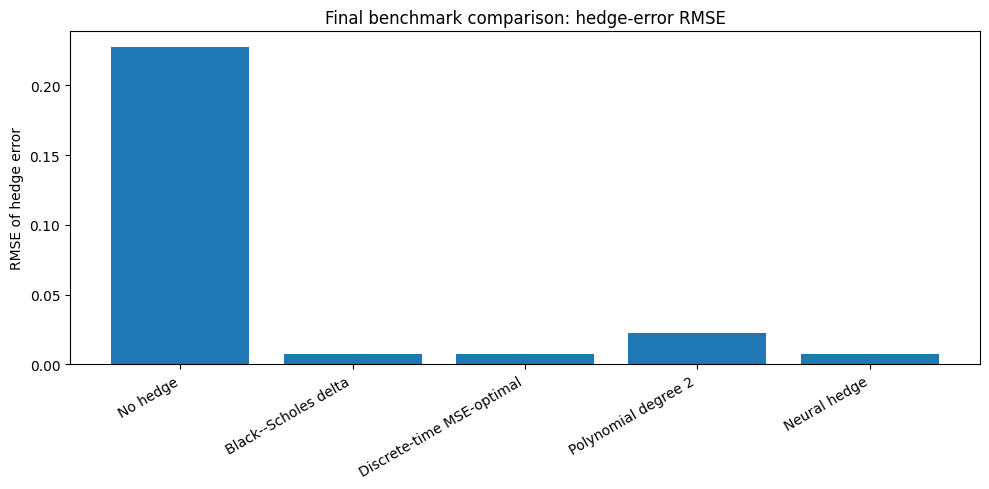

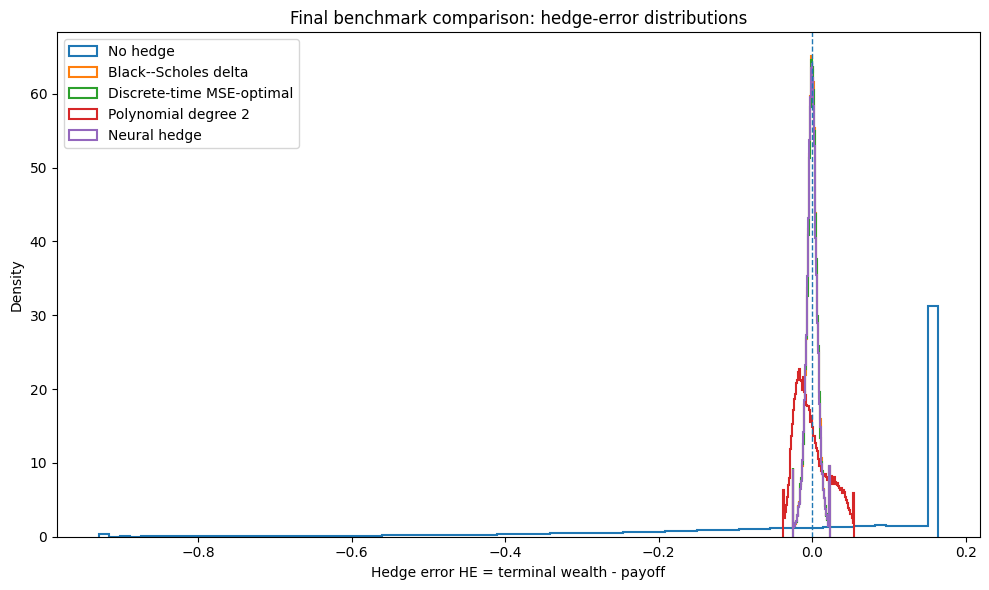

Saved outputs to: /content/drive/MyDrive/MFE_neural_hedging_report_outputs/source_runs/02_black_scholes_final_benchmark/final_benchmark_outputs


In [10]:
# ============================================================
# 9. Plots: RMSE bar chart and hedge-error distributions
# ============================================================

# RMSE bar chart
plt.figure(figsize=(10, 5))
plt.bar(results_df["Strategy"], results_df["RMSE"])
plt.ylabel("RMSE of hedge error")
plt.title("Final benchmark comparison: hedge-error RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(out_dir / "benchmark_rmse_bar.png", dpi=200)
plt.show()

# Hedge error histograms
he_by_strategy = {
    "No hedge": he_no,
    "Black--Scholes delta": he_bs,
    "Discrete-time MSE-optimal": he_dt,
    f"Polynomial degree {cfg.polynomial_degree}": he_poly,
    "Neural hedge": he_nn,
}

plt.figure(figsize=(10, 6))
for name, he in he_by_strategy.items():
    # Clip plotting range for readability.
    lo, hi = np.quantile(he, [0.005, 0.995])
    plt.hist(
        np.clip(he, lo, hi),
        bins=80,
        density=True,
        histtype="step",
        linewidth=1.5,
        label=name,
    )

plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Hedge error HE = terminal wealth - payoff")
plt.ylabel("Density")
plt.title("Final benchmark comparison: hedge-error distributions")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / "benchmark_hedge_error_histograms.png", dpi=200)
plt.show()

print(f"Saved outputs to: {out_dir.resolve()}")

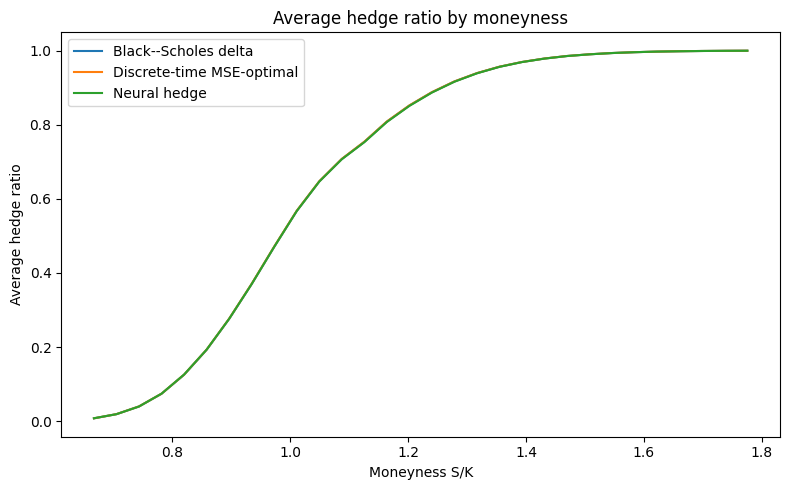

In [11]:
# ============================================================
# 10. Optional: inspect average delta shapes by moneyness bucket
# ============================================================

# This lightweight diagnostic checks whether the learned deltas are economically sensible
# without producing a full 3D delta surface.

def binned_delta_summary(paths, deltas, name, n_bins=30):
    S = paths[:, :-1]
    moneyness = (S / cfg.K).reshape(-1)
    delta_flat = deltas.reshape(-1)

    bins = np.linspace(np.quantile(moneyness, 0.01), np.quantile(moneyness, 0.99), n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    means = []
    for i in range(n_bins):
        mask = (moneyness >= bins[i]) & (moneyness < bins[i + 1])
        means.append(np.mean(delta_flat[mask]) if np.any(mask) else np.nan)

    return pd.DataFrame({"S_over_K": centers, "mean_delta": means, "strategy": name})


delta_summary = pd.concat([
    binned_delta_summary(paths_test, deltas_bs, "Black--Scholes delta"),
    binned_delta_summary(paths_test, deltas_dt, "Discrete-time MSE-optimal"),
    binned_delta_summary(paths_test, deltas_nn, "Neural hedge"),
], ignore_index=True)

plt.figure(figsize=(8, 5))
for name, group in delta_summary.groupby("strategy"):
    plt.plot(group["S_over_K"], group["mean_delta"], label=name)

plt.xlabel("Moneyness S/K")
plt.ylabel("Average hedge ratio")
plt.title("Average hedge ratio by moneyness")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / "average_delta_by_moneyness.png", dpi=200)
plt.show()

delta_summary.to_csv(out_dir / "average_delta_by_moneyness.csv", index=False)

In [12]:
# ============================================================
# 11. Robustness Analysis: RMSE across Strike and Volatility
# ============================================================

from scipy.special import ndtr as _ndtr

def robustness_bs_price(S0, K, T, r, sigma):
    tau = T
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return S0*_ndtr(d1) - K*np.exp(-r*tau)*_ndtr(d2)

def robustness_bs_delta(S, tau, K, r, sigma):
    tau_safe = np.maximum(tau, 1e-12)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*tau_safe) / (sigma*np.sqrt(tau_safe))
    return _ndtr(d1)

def robustness_dt_delta(S, tau, K, r, sigma, h):
    tau_safe = np.maximum(tau, h)
    sqrt_tau = np.sqrt(tau_safe)
    d1 = (np.log(S/K) + 0.5*sigma**2*tau_safe) / (sigma*sqrt_tau)
    d2 = d1 - sigma*sqrt_tau
    shift = sigma*h/sqrt_tau
    C = robustness_bs_price(S, K, tau_safe, r, sigma)
    num = (S**2*np.exp(sigma**2*h)*_ndtr(d1+shift)
           - K*S*_ndtr(d2+shift)
           - S*C)
    den = S**2*(np.exp(sigma**2*h) - 1.0)
    return num/np.maximum(den, 1e-18)

def simulate_robustness_paths(n_paths, N, S0, r, sigma, T, seed):
    rng = np.random.default_rng(seed)
    dt = T/N
    Z = rng.standard_normal((n_paths, N)).astype(np.float32)
    log_inc = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_S = np.cumsum(log_inc, axis=1)
    paths = np.empty((n_paths, N+1), dtype=np.float32)
    paths[:, 0] = S0
    paths[:, 1:] = S0*np.exp(log_S)
    return paths

def robustness_rmse(paths, deltas, premium, K):
    dS = paths[:, 1:] - paths[:, :-1]
    VT = premium + np.sum(deltas*dS, axis=1)
    payoff = np.maximum(paths[:, -1] - K, 0.0)
    he = VT - payoff
    return float(np.sqrt(np.mean(he**2)))

def evaluate_robustness_scenario(K, sigma, cfg, nn_model, n_test=30_000, seed=999):
    """
    For a given (K, sigma), simulate fresh test paths and evaluate:
    - BS delta hedge
    - DT-optimal hedge
    - Neural hedge (no retraining — uses model trained on K=0.9, sigma=0.4)
    """
    N = cfg.N
    T = cfg.T
    r = cfg.r
    S0 = cfg.S0
    dt = T/N

    # Simulate test paths for this scenario
    paths = simulate_robustness_paths(n_test, N, S0, r, sigma, T, seed=seed)

    # Time grid
    t_grid = np.arange(N)*dt
    tau_grid_r = T - t_grid

    # BS delta
    S_steps = paths[:, :-1].astype(np.float64)
    tau_2d = tau_grid_r[None, :]
    deltas_bs_r = robustness_bs_delta(S_steps, tau_2d, K, r, sigma).astype(np.float32)
    premium_bs = robustness_bs_price(S0, K, T, r, sigma)
    rmse_bs = robustness_rmse(paths, deltas_bs_r, premium_bs, K)

    # DT-optimal delta
    h = dt
    deltas_dt_r = robustness_dt_delta(
        S_steps, tau_2d, K, r, sigma, h
    ).astype(np.float32)
    rmse_dt = robustness_rmse(paths, deltas_dt_r, premium_bs, K)

    # Neural hedge — no retraining, use model as-is
    # Model was trained with K=cfg.K, sigma=cfg.sigma features
    # We feed it the raw paths; it uses log(S/K_train) internally
    # For out-of-sample K/sigma, this is intentionally the same frozen model
    tau_norm = tau_grid_r/T
    paths_tf = tf.constant(paths, dtype=tf.float32)

    # Extract deltas from model using its internal feature construction
    # (model uses cfg.K=0.9 in its features regardless of robustness K)
    batch_size = 4096
    all_deltas_nn = []
    for start in range(0, len(paths), batch_size):
        batch = paths_tf[start:start+batch_size]
        _, d = nn_model(batch, training=False)
        all_deltas_nn.append(d.numpy())
    deltas_nn_r = np.concatenate(all_deltas_nn, axis=0)

    # Use the neural network's learned premium (from training scenario)
    premium_nn = float(nn_model.premium.numpy())
    rmse_nn = robustness_rmse(paths, deltas_nn_r, premium_nn, K)

    return rmse_bs, rmse_dt, rmse_nn


# ── Grid ──
K_grid     = [0.7, 0.9, 1.1]
sigma_grid = [0.2, 0.4, 0.6]

print("Running robustness analysis...")
print(f"Training parameters: K={cfg.K}, sigma={cfg.sigma}\n")

rows = []
for K_val in K_grid:
    for sigma_val in sigma_grid:
        rmse_bs, rmse_dt, rmse_nn = evaluate_robustness_scenario(
            K=K_val,
            sigma=sigma_val,
            cfg=cfg,
            nn_model=nn_model,
            n_test=30_000,
            seed=999,
        )
        rows.append({
            "K":           K_val,
            "sigma":       sigma_val,
            "BS RMSE":     rmse_bs,
            "DT RMSE":     rmse_dt,
            "NN RMSE":     rmse_nn,
            "training_K":     cfg.K,
            "training_sigma": cfg.sigma,
        })
        marker = " ← training" if (K_val==cfg.K and sigma_val==cfg.sigma) else ""
        print(f"K={K_val}, σ={sigma_val}: "
              f"BS={rmse_bs:.6f}  DT={rmse_dt:.6f}  NN={rmse_nn:.6f}{marker}")

rob_df = pd.DataFrame(rows)
rob_df.to_csv(out_dir/"robustness_rmse.csv", index=False)


# ── Display as pivot tables ──
print("\n--- BS Delta RMSE ---")
bs_pivot = rob_df.pivot(index="K", columns="sigma", values="BS RMSE")
bs_pivot.columns = [f"σ={s}" for s in bs_pivot.columns]
print(bs_pivot.round(6).to_string())

print("\n--- DT-Optimal RMSE ---")
dt_pivot = rob_df.pivot(index="K", columns="sigma", values="DT RMSE")
dt_pivot.columns = [f"σ={s}" for s in dt_pivot.columns]
print(dt_pivot.round(6).to_string())

print("\n--- Neural Hedge RMSE ---")
nn_pivot = rob_df.pivot(index="K", columns="sigma", values="NN RMSE")
nn_pivot.columns = [f"σ={s}" for s in nn_pivot.columns]
print(nn_pivot.round(6).to_string())


# ── LaTeX table ──
latex_rows = []
for K_val in K_grid:
    for sigma_val in sigma_grid:
        r = rob_df[(rob_df["K"]==K_val) & (rob_df["sigma"]==sigma_val)].iloc[0]
        marker = r" $\star$" if (K_val==cfg.K and sigma_val==cfg.sigma) else ""
        latex_rows.append({
            "K":      f"{K_val}{marker}",
            "sigma":  f"{sigma_val}{marker}",
            "BS RMSE":  f"{r['BS RMSE']:.6f}",
            "DT RMSE":  f"{r['DT RMSE']:.6f}",
            "NN RMSE":  f"{r['NN RMSE']:.6f}",
        })

latex_df = pd.DataFrame(latex_rows)
latex_df.columns = ["$K$", r"$\sigma$",
                    "BS Delta RMSE", "DT-Optimal RMSE", "Neural Hedge RMSE"]
latex_str = latex_df.to_latex(
    index=False,
    escape=False,
    caption=(
        r"Out-of-sample robustness: RMSE of hedging error across strike $K$ "
        r"and volatility $\sigma$. The neural hedge is evaluated without retraining "
        r"(trained at $K=0.9$, $\sigma=0.4$, marked $\star$). "
        r"BS delta and DT-optimal hedges are analytic and adapt automatically "
        r"to each scenario."
    ),
    label="tab:robustness",
)
with open(out_dir/"robustness_rmse.tex", "w") as f:
    f.write(latex_str)

print("\nSaved robustness_rmse.csv and robustness_rmse.tex")

Running robustness analysis...
Training parameters: K=0.9, sigma=0.4



K=0.7, σ=0.2: BS=0.000492  DT=0.000492  NN=0.143308


K=0.7, σ=0.4: BS=0.004115  DT=0.004114  NN=0.166962


K=0.7, σ=0.6: BS=0.008108  DT=0.008103  NN=0.200019


K=0.9, σ=0.2: BS=0.003400  DT=0.003399  NN=0.048452


K=0.9, σ=0.4: BS=0.007811  DT=0.007809  NN=0.007840 ← training


K=0.9, σ=0.6: BS=0.011831  DT=0.011824  NN=0.056742


K=1.1, σ=0.2: BS=0.004026  DT=0.004026  NN=0.158329


K=1.1, σ=0.4: BS=0.009017  DT=0.009017  NN=0.126978


K=1.1, σ=0.6: BS=0.013690  DT=0.013686  NN=0.107204

--- BS Delta RMSE ---
        σ=0.2     σ=0.4     σ=0.6
K                                
0.7  0.000492  0.004115  0.008108
0.9  0.003400  0.007811  0.011831
1.1  0.004026  0.009017  0.013690

--- DT-Optimal RMSE ---
        σ=0.2     σ=0.4     σ=0.6
K                                
0.7  0.000492  0.004114  0.008103
0.9  0.003399  0.007809  0.011824
1.1  0.004026  0.009017  0.013686

--- Neural Hedge RMSE ---
        σ=0.2     σ=0.4     σ=0.6
K                                
0.7  0.143308  0.166962  0.200019
0.9  0.048452  0.007840  0.056742
1.1  0.158329  0.126978  0.107204

Saved robustness_rmse.csv and robustness_rmse.tex


In [13]:
# ── Compact 3-column table: one row per (K, sigma) scenario ──

compact_rows = []
for K_val in K_grid:
    for sigma_val in sigma_grid:
        r = rob_df[(rob_df["K"]==K_val) & (rob_df["sigma"]==sigma_val)].iloc[0]
        marker = " ★" if (K_val==cfg.K and sigma_val==cfg.sigma) else ""
        compact_rows.append({
            "K":                       f"{K_val}{marker}",
            "σ":                       f"{sigma_val}{marker}",
            "BS Delta RMSE":           round(r["BS RMSE"], 6),
            "DT-Optimal RMSE":         round(r["DT RMSE"], 6),
            "Neural Hedge RMSE":       round(r["NN RMSE"], 6),
        })

compact_df = pd.DataFrame(compact_rows)

# Style it to match your table aesthetic
styled = (
    compact_df.style
    .set_caption("Robustness: RMSE across strike K and volatility σ. "
                 "★ = training scenario (K=0.9, σ=0.4). "
                 "Neural hedge evaluated without retraining.")
    .format({
        "BS Delta RMSE":     "{:.6f}",
        "DT-Optimal RMSE":   "{:.6f}",
        "Neural Hedge RMSE": "{:.6f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("font-weight", "bold"),
                                     ("text-align", "center")]},
        {"selector": "caption", "props": [("font-size", "13px"),
                                          ("font-weight", "bold"),
                                          ("padding-bottom", "8px")]},
    ])
)

display(styled)
compact_df.to_csv(out_dir/"robustness_compact.csv", index=False)

# LaTeX version
latex_str = compact_df.to_latex(
    index=False,
    escape=False,
    float_format="%.6f",
    caption=(
        r"Robustness of hedging strategies across strike $K$ and volatility "
        r"$\sigma$. The neural hedge is evaluated without retraining "
        r"(trained at $K^\star=0.9$, $\sigma^\star=0.4$). "
        r"BS delta and DT-optimal hedges are analytic and adapt to each scenario automatically."
    ),
    label="tab:robustness",
)
with open(out_dir/"robustness_compact.tex", "w") as f:
    f.write(latex_str)

print("Saved robustness_compact.csv and robustness_compact.tex")

,K,σ,BS Delta RMSE,DT-Optimal RMSE,Neural Hedge RMSE
0,0.7,0.2,0.000492,0.000492,0.143308
1,0.7,0.4,0.004115,0.004114,0.166962
2,0.7,0.6,0.008108,0.008103,0.200019
3,0.9,0.2,0.003400,0.003399,0.048452
4,0.9 ★,0.4 ★,0.007811,0.007809,0.007840
5,0.9,0.6,0.011831,0.011824,0.056742
6,1.1,0.2,0.004026,0.004026,0.158329
7,1.1,0.4,0.009017,0.009017,0.126978
8,1.1,0.6,0.013690,0.013686,0.107204


Saved robustness_compact.csv and robustness_compact.tex


In [14]:
# ── Single-scenario out-of-sample collapse table ──
# Assumes rob_df has columns: K, sigma, BS RMSE, DT RMSE, NN RMSE
# where NN RMSE comes from the single-scenario model evaluated without retraining

collapse_rows = []
for K_val in K_grid:
    for sigma_val in sigma_grid:
        r = rob_df[(rob_df["K"]==K_val) & (rob_df["sigma"]==sigma_val)].iloc[0]
        marker = " ★" if (K_val==cfg.K and sigma_val==cfg.sigma) else ""
        collapse_rows.append({
            "K":                       f"{K_val}{marker}",
            "σ":                       f"{sigma_val}{marker}",
            "BS Delta RMSE":           round(r["BS RMSE"], 6),
            "DT-Optimal RMSE":         round(r["DT RMSE"], 6),
            "Neural Hedge RMSE":       round(r["NN RMSE"], 6),
        })

collapse_df = pd.DataFrame(collapse_rows)

styled = (
    collapse_df.style
    .set_caption(
        "Out-of-sample generalisation failure of the single-scenario neural hedge. "
        "Model trained at K=0.9, σ=0.4 (★) and evaluated without retraining. "
        "BS delta and DT-optimal hedges are analytic and adapt automatically."
    )
    .format({
        "BS Delta RMSE":     "{:.6f}",
        "DT-Optimal RMSE":   "{:.6f}",
        "Neural Hedge RMSE": "{:.6f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("font-weight", "bold"),
                                     ("text-align", "center")]},
        {"selector": "caption", "props": [("font-size", "13px"),
                                          ("font-weight", "bold"),
                                          ("padding-bottom", "8px")]},
    ])
)
display(styled)
collapse_df.to_csv(out_dir/"collapse_compact.csv", index=False)

latex_str = collapse_df.to_latex(
    index=False,
    escape=False,
    float_format="%.6f",
    caption=(
        r"Out-of-sample generalisation failure of the single-scenario neural hedge. "
        r"The model is trained at $K^\star=0.9$, $\sigma^\star=0.4$ (marked $\star$) "
        r"and evaluated without retraining. "
        r"The Black--Scholes delta and discrete-time MSE-optimal hedges are analytic "
        r"and adapt automatically to each scenario."
    ),
    label="tab:collapse",
)
with open(out_dir/"collapse_compact.tex", "w") as f:
    f.write(latex_str)
print("Saved collapse_compact.csv and collapse_compact.tex")

,K,σ,BS Delta RMSE,DT-Optimal RMSE,Neural Hedge RMSE
0,0.7,0.2,0.000492,0.000492,0.143308
1,0.7,0.4,0.004115,0.004114,0.166962
2,0.7,0.6,0.008108,0.008103,0.200019
3,0.9,0.2,0.003400,0.003399,0.048452
4,0.9 ★,0.4 ★,0.007811,0.007809,0.007840
5,0.9,0.6,0.011831,0.011824,0.056742
6,1.1,0.2,0.004026,0.004026,0.158329
7,1.1,0.4,0.009017,0.009017,0.126978
8,1.1,0.6,0.013690,0.013686,0.107204


Saved collapse_compact.csv and collapse_compact.tex


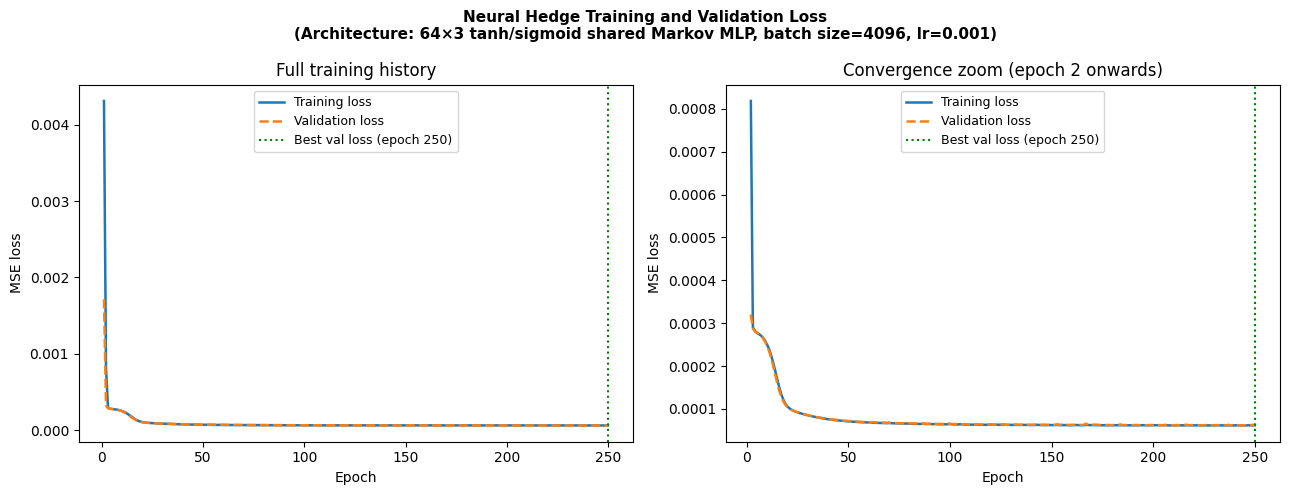

Total epochs trained:     250
Best validation loss:     6.19873196e-05 at epoch 250
Final training loss:      6.19785245e-05
Final validation loss:    6.19873196e-05
Train/val gap at cutoff:  8.79512518e-09  (overfitting signal)
Learned premium:          0.16397233
BS reference price:       0.16411068


In [15]:
# ============================================================
# 11b. Learning Curve: Training and Validation Loss
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Neural Hedge Training and Validation Loss\n"
    f"(Architecture: {cfg.width}×{cfg.depth} tanh/sigmoid shared Markov MLP, "
    f"batch size={cfg.batch_size}, lr={cfg.learning_rate})",
    fontweight="bold", fontsize=11,
)

# ── Left panel: full training history ──
ax = axes[0]
ax.plot(nn_history["epoch"], nn_history["train_loss"],
        label="Training loss", color="#1f77b4", lw=1.8)
ax.plot(nn_history["epoch"], nn_history["val_loss"],
        label="Validation loss", color="#ff7f0e", lw=1.8, ls="--")

# Mark early stopping point (last epoch)
best_epoch = int(nn_history.loc[nn_history["val_loss"].idxmin(), "epoch"])
best_val   = float(nn_history["val_loss"].min())
ax.axvline(best_epoch, color="green", ls=":", lw=1.5,
           label=f"Best val loss (epoch {best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Full training history")
ax.legend(fontsize=9)

# ── Right panel: zoom into convergence region (skip epoch 1) ──
ax = axes[1]
history_tail = nn_history[nn_history["epoch"] >= 2].copy()
ax.plot(history_tail["epoch"], history_tail["train_loss"],
        label="Training loss", color="#1f77b4", lw=1.8)
ax.plot(history_tail["epoch"], history_tail["val_loss"],
        label="Validation loss", color="#ff7f0e", lw=1.8, ls="--")
ax.axvline(best_epoch, color="green", ls=":", lw=1.5,
           label=f"Best val loss (epoch {best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Convergence zoom (epoch 2 onwards)")
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(out_dir/"learning_curve_train_val.png", dpi=180, bbox_inches="tight")
plt.show()

# ── Print summary statistics ──
print(f"Total epochs trained:     {len(nn_history)}")
print(f"Best validation loss:     {best_val:.8e} at epoch {best_epoch}")
print(f"Final training loss:      {float(nn_history['train_loss'].iloc[-1]):.8e}")
print(f"Final validation loss:    {float(nn_history['val_loss'].iloc[-1]):.8e}")
gap = float(nn_history['val_loss'].iloc[-1]) - float(nn_history['train_loss'].iloc[-1])
print(f"Train/val gap at cutoff:  {gap:.8e}  "
      f"({'overfitting signal' if gap > 0 else 'no overfitting'})")
print(f"Learned premium:          {float(nn_model.premium.numpy()):.8f}")
print(f"BS reference price:       {bs_price_0:.8f}")

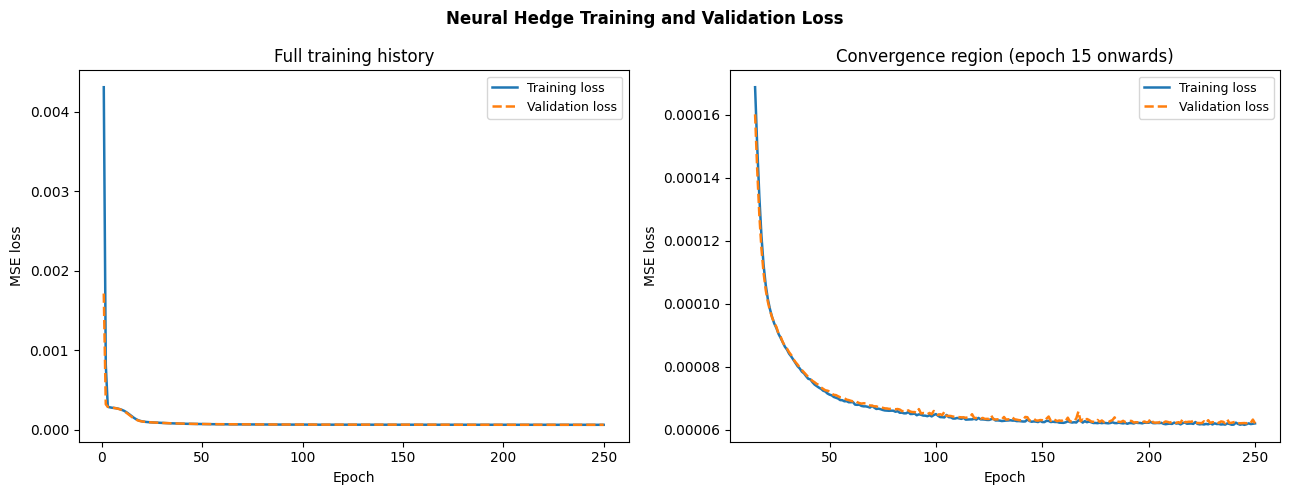

Total epochs trained:   250
Best validation loss:   6.19873196e-05 at epoch 250
Final training loss:    6.19785245e-05
Final validation loss:  6.19873196e-05
Train/val gap:          8.80e-09  (negligible — no overfitting)
Learned premium:        0.16397233
BS reference price:     0.16411068


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Neural Hedge Training and Validation Loss",
    fontweight="bold", fontsize=12,
)

# ── Left panel: full history ──
ax = axes[0]
ax.plot(nn_history["epoch"], nn_history["train_loss"],
        label="Training loss", color="#1f77b4", lw=1.8)
ax.plot(nn_history["epoch"], nn_history["val_loss"],
        label="Validation loss", color="#ff7f0e", lw=1.8, ls="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Full training history")
ax.legend(fontsize=9)

# ── Right panel: zoom from epoch 15 onwards ──
ax = axes[1]
history_tail = nn_history[nn_history["epoch"] >= 15].copy()
ax.plot(history_tail["epoch"], history_tail["train_loss"],
        label="Training loss", color="#1f77b4", lw=1.8)
ax.plot(history_tail["epoch"], history_tail["val_loss"],
        label="Validation loss", color="#ff7f0e", lw=1.8, ls="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Convergence region (epoch 15 onwards)")
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(out_dir/"learning_curve_train_val.png", dpi=180, bbox_inches="tight")
plt.show()

# ── Print summary ──
best_epoch = int(nn_history.loc[nn_history["val_loss"].idxmin(), "epoch"])
best_val   = float(nn_history["val_loss"].min())
print(f"Total epochs trained:   {len(nn_history)}")
print(f"Best validation loss:   {best_val:.8e} at epoch {best_epoch}")
print(f"Final training loss:    {float(nn_history['train_loss'].iloc[-1]):.8e}")
print(f"Final validation loss:  {float(nn_history['val_loss'].iloc[-1]):.8e}")
print(f"Train/val gap:          {abs(float(nn_history['val_loss'].iloc[-1]) - float(nn_history['train_loss'].iloc[-1])):.2e}  (negligible — no overfitting)")
print(f"Learned premium:        {float(nn_model.premium.numpy()):.8f}")
print(f"BS reference price:     {bs_price_0:.8f}")

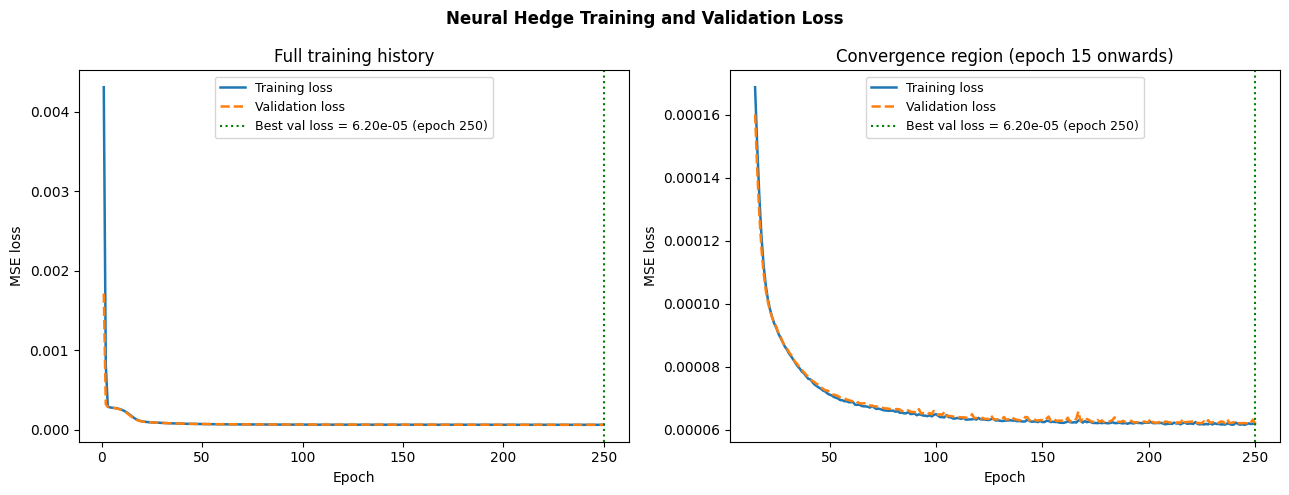

Total epochs trained:   250
Best validation loss:   6.19873196e-05 at epoch 250
Final training loss:    6.19785245e-05
Final validation loss:  6.19873196e-05
Train/val gap:          8.80e-09  (negligible — no overfitting)
Learned premium:        0.16397233
BS reference price:     0.16411068


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Neural Hedge Training and Validation Loss",
    fontweight="bold", fontsize=12,
)

# ── Left panel: full history ──
ax = axes[0]
ax.plot(nn_history["epoch"], nn_history["train_loss"],
        label="Training loss", color="#1f77b4", lw=1.8)
ax.plot(nn_history["epoch"], nn_history["val_loss"],
        label="Validation loss", color="#ff7f0e", lw=1.8, ls="--")

best_epoch = int(nn_history.loc[nn_history["val_loss"].idxmin(), "epoch"])
best_val   = float(nn_history["val_loss"].min())
ax.axvline(best_epoch, color="green", ls=":", lw=1.5,
           label=f"Best val loss = {best_val:.2e} (epoch {best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Full training history")
ax.legend(fontsize=9)

# ── Right panel: zoom from epoch 15 onwards ──
ax = axes[1]
history_tail = nn_history[nn_history["epoch"] >= 15].copy()
ax.plot(history_tail["epoch"], history_tail["train_loss"],
        label="Training loss", color="#1f77b4", lw=1.8)
ax.plot(history_tail["epoch"], history_tail["val_loss"],
        label="Validation loss", color="#ff7f0e", lw=1.8, ls="--")
ax.axvline(best_epoch, color="green", ls=":", lw=1.5,
           label=f"Best val loss = {best_val:.2e} (epoch {best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Convergence region (epoch 15 onwards)")
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(out_dir/"learning_curve_train_val.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Total epochs trained:   {len(nn_history)}")
print(f"Best validation loss:   {best_val:.8e} at epoch {best_epoch}")
print(f"Final training loss:    {float(nn_history['train_loss'].iloc[-1]):.8e}")
print(f"Final validation loss:  {float(nn_history['val_loss'].iloc[-1]):.8e}")
print(f"Train/val gap:          {abs(float(nn_history['val_loss'].iloc[-1]) - float(nn_history['train_loss'].iloc[-1])):.2e}  (negligible — no overfitting)")
print(f"Learned premium:        {float(nn_model.premium.numpy()):.8f}")
print(f"BS reference price:     {bs_price_0:.8f}")

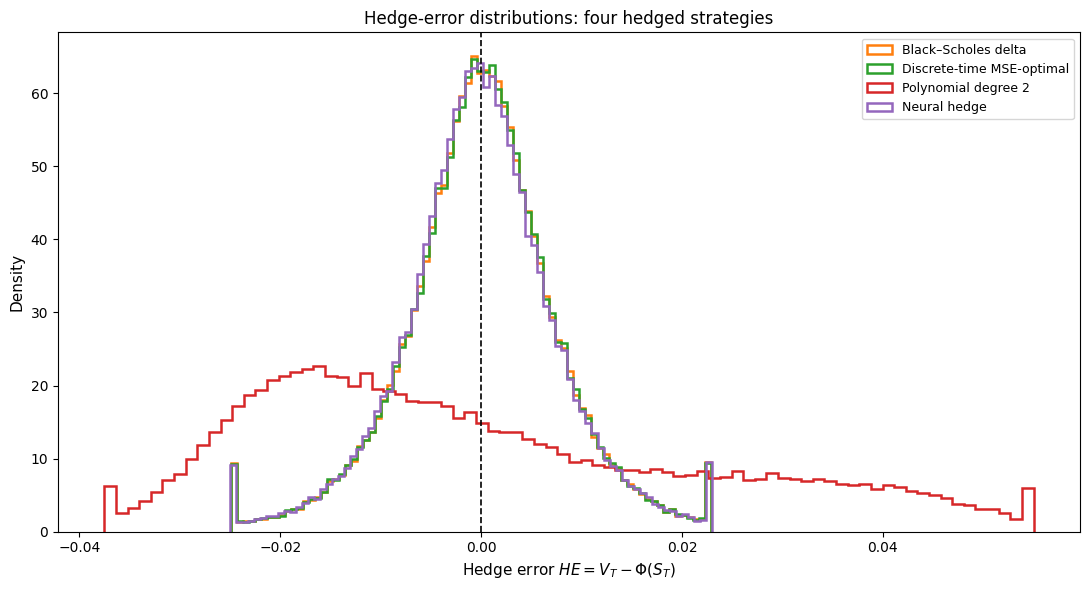

In [18]:
# ============================================================
# 11c. P&L Distribution — four hedged strategies
# ============================================================

he_hedged = {
    "Black–Scholes delta":       he_bs,
    "Discrete-time MSE-optimal": he_dt,
    "Polynomial degree 2":       he_poly,
    "Neural hedge":              he_nn,
}

colours = {
    "Black–Scholes delta":       "#ff7f0e",
    "Discrete-time MSE-optimal": "#2ca02c",
    "Polynomial degree 2":       "#d62728",
    "Neural hedge":              "#9467bd",
}

fig, ax = plt.subplots(figsize=(11, 6))

for name, he in he_hedged.items():
    lo, hi = np.quantile(he, [0.005, 0.995])
    ax.hist(
        np.clip(he, lo, hi),
        bins=80,
        density=True,
        histtype="step",
        linewidth=1.8,
        color=colours[name],
        label=name,
    )

ax.axvline(0, color="black", lw=1.2, ls="--")
ax.set_xlabel(r"Hedge error $HE = V_T - \Phi(S_T)$", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Hedge-error distributions: four hedged strategies", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(out_dir/"pnl_four_strategies.png", dpi=180, bbox_inches="tight")
plt.show()

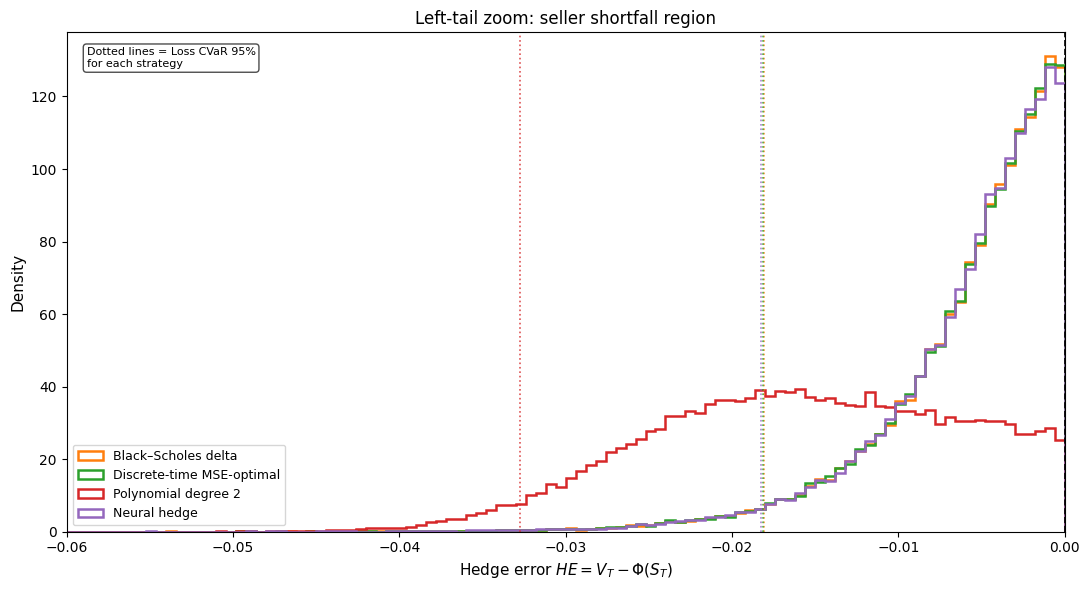

In [19]:
# ============================================================
# 11d. Left-tail zoom — four hedged strategies
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

# Use fixed sensible limits based on what we know from the data
# Left tail = negative HE region, zoom to where the hedged strategies
# actually have mass
x_lo = -0.06
x_hi = 0.0

for name, he in he_hedged.items():
    tail = he[he <= x_hi]
    ax.hist(
        tail,
        bins=100,
        density=True,
        histtype="step",
        linewidth=1.8,
        color=colours[name],
        label=name,
        range=(x_lo, x_hi),
    )

ax.axvline(0, color="black", lw=1.2, ls="--")
ax.set_xlim(x_lo, x_hi)
ax.set_xlabel(r"Hedge error $HE = V_T - \Phi(S_T)$", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Left-tail zoom: seller shortfall region", fontsize=12)
ax.legend(fontsize=9)

# CVaR95 vertical lines — annotate in legend not on plot
for name, he in he_hedged.items():
    loss = -he
    var95  = float(np.percentile(loss, 95))
    cvar95 = float(np.mean(loss[loss >= var95]))
    he_cvar = -cvar95
    ax.axvline(he_cvar, color=colours[name], lw=1.2, ls=":",
               alpha=0.8)

# Add a text box explaining the dotted lines
ax.text(0.02, 0.97,
        "Dotted lines = Loss CVaR 95%\nfor each strategy",
        transform=ax.transAxes,
        fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.tight_layout()
fig.savefig(out_dir/"pnl_left_tail_zoom.png", dpi=180, bbox_inches="tight")
plt.show()

In [20]:
# ============================================================
# SMOKE TEST: Universal hedger — runs in ~2 minutes on CPU
# ============================================================

import numpy as np
import tensorflow as tf
from scipy.special import ndtr

def norm_cdf(x):
    return ndtr(x)

# ── Tiny config ──
N       = 20        # hedging steps
T       = 0.5
S0      = 1.0
r       = 0.0
n_train = 2_000
n_val   = 500
n_test  = 1_000
epochs  = 5
batch   = 256
seed    = 42

rng = np.random.default_rng(seed)

# ── Sample random (K, sigma) per path ──
def sample_parameters(n_paths, rng):
    K     = rng.uniform(0.7, 1.1, size=n_paths).astype(np.float32)
    sigma = rng.uniform(0.2, 0.6, size=n_paths).astype(np.float32)
    return K, sigma

# ── Simulate GBM paths with per-path (K, sigma) ──
def simulate_universal(n_paths, N, T, S0, r, K_arr, sigma_arr, rng):
    dt  = T / N
    Z   = rng.standard_normal((n_paths, N)).astype(np.float32)
    # Each path has its own sigma
    inc = ((r - 0.5*sigma_arr**2)*dt)[:, None] + \
          (sigma_arr*np.sqrt(dt))[:, None] * Z
    log_S = np.cumsum(inc, axis=1)
    paths = np.empty((n_paths, N+1), dtype=np.float32)
    paths[:, 0] = S0
    paths[:, 1:] = S0 * np.exp(log_S)
    return paths

# ── Build feature tensor: (batch, N, 4) ──
# Features: [log(S_n/K), tau_n/T, K, sigma]
def make_universal_features(paths, K_arr, sigma_arr, N, T):
    dt       = T / N
    tau_grid = (T - np.arange(N)*dt).astype(np.float32)

    S_steps  = paths[:, :N]                          # (M, N)
    K_2d     = K_arr[:, None] * np.ones((1, N), dtype=np.float32)
    sig_2d   = sigma_arr[:, None] * np.ones((1, N), dtype=np.float32)
    tau_2d   = np.ones((len(paths), 1), dtype=np.float32) * tau_grid[None, :]

    log_m    = np.log(np.maximum(S_steps, 1e-7) / K_2d)
    tau_norm = tau_2d / T

    # Stack to (M, N, 4)
    feat = np.stack([log_m, tau_norm, K_2d, sig_2d], axis=-1)
    return feat.astype(np.float32)

# ── Generate data ──
K_tr, sig_tr = sample_parameters(n_train, rng)
K_vl, sig_vl = sample_parameters(n_val,   rng)
K_te, sig_te = sample_parameters(n_test,  rng)

paths_tr = simulate_universal(n_train, N, T, S0, r, K_tr, sig_tr, rng)
paths_vl = simulate_universal(n_val,   N, T, S0, r, K_vl, sig_vl, rng)
paths_te = simulate_universal(n_test,  N, T, S0, r, K_te, sig_te, rng)

feat_tr = make_universal_features(paths_tr, K_tr, sig_tr, N, T)
feat_vl = make_universal_features(paths_vl, K_vl, sig_vl, N, T)
feat_te = make_universal_features(paths_te, K_te, sig_te, N, T)

payoff_tr = np.maximum(paths_tr[:, -1] - K_tr, 0.0).astype(np.float32)
payoff_vl = np.maximum(paths_vl[:, -1] - K_vl, 0.0).astype(np.float32)
payoff_te = np.maximum(paths_te[:, -1] - K_te, 0.0).astype(np.float32)

print(f"Feature tensor shape: {feat_tr.shape}")  # should be (2000, 20, 4)
print(f"Paths shape:          {paths_tr.shape}")  # should be (2000, 21)

# ── Tiny universal model ──
class UniversalHedge(tf.keras.Model):
    def __init__(self, N, T, width=16, depth=2):
        super().__init__()
        self.N = N
        self.T = T
        self.premium = self.add_weight(
            name="premium", shape=(),
            initializer=tf.keras.initializers.Constant(0.15),
            trainable=True, dtype=tf.float32,
        )
        layers = []
        for _ in range(depth):
            layers.append(tf.keras.layers.Dense(width, activation="tanh"))
        layers.append(tf.keras.layers.Dense(1, activation="sigmoid"))
        self.net = tf.keras.Sequential(layers)

    def call(self, inputs, training=False):
        # inputs = (features, paths, payoff)
        feat, paths, payoff = inputs
        batch = tf.shape(feat)[0]

        flat  = tf.reshape(feat, (-1, 4))
        delta_flat = self.net(flat, training=training)
        deltas = tf.reshape(delta_flat[:, 0], (batch, self.N))

        dS = paths[:, 1:] - paths[:, :self.N]
        VT = self.premium + tf.reduce_sum(deltas * dS, axis=1)
        he = VT - payoff
        return he

# ── Quick training loop ──
model = UniversalHedge(N, T, width=16, depth=2)
opt   = tf.keras.optimizers.Adam(1e-3)

@tf.function
def train_step(feat, paths, payoff):
    with tf.GradientTape() as tape:
        he   = model((feat, paths, payoff), training=True)
        loss = tf.reduce_mean(tf.square(he))
    grads = tape.gradient(loss, model.trainable_variables)
    opt.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# Convert to tensors
feat_tr_tf  = tf.constant(feat_tr)
paths_tr_tf = tf.constant(paths_tr)
pay_tr_tf   = tf.constant(payoff_tr)

feat_vl_tf  = tf.constant(feat_vl)
paths_vl_tf = tf.constant(paths_vl)
pay_vl_tf   = tf.constant(payoff_vl)

print("\nRunning smoke test training...")
for epoch in range(1, epochs+1):
    # Mini-batch loop
    idx = np.random.permutation(n_train)
    losses = []
    for start in range(0, n_train, batch):
        b = idx[start:start+batch]
        loss = train_step(
            tf.gather(feat_tr_tf, b),
            tf.gather(paths_tr_tf, b),
            tf.gather(pay_tr_tf, b),
        )
        losses.append(float(loss))
    # Val loss
    he_vl  = model((feat_vl_tf, paths_vl_tf, pay_vl_tf), training=False)
    val_loss = float(tf.reduce_mean(tf.square(he_vl)))
    print(f"Epoch {epoch}: train={np.mean(losses):.6f}  val={val_loss:.6f}  "
          f"premium={float(model.premium):.5f}")

# ── Quick sanity check on test set ──
feat_te_tf  = tf.constant(feat_te)
paths_te_tf = tf.constant(paths_te)
pay_te_tf   = tf.constant(payoff_te)

he_te = model((feat_te_tf, paths_te_tf, pay_te_tf), training=False).numpy()
rmse  = float(np.sqrt(np.mean(he_te**2)))
print(f"\nSmoke test RMSE on random (K,sigma) test set: {rmse:.6f}")
print("✓ Smoke test passed — architecture works end-to-end")
print("  (RMSE will be large with only 5 epochs and 2000 paths — that is expected)")

Feature tensor shape: (2000, 20, 4)
Paths shape:          (2000, 21)

Running smoke test training...


Epoch 1: train=0.016239  val=0.013038  premium=0.15757
Epoch 2: train=0.014467  val=0.012449  premium=0.16436
Epoch 3: train=0.013330  val=0.012180  premium=0.16932
Epoch 4: train=0.012873  val=0.011987  premium=0.17260
Epoch 5: train=0.012507  val=0.011724  premium=0.17457

Smoke test RMSE on random (K,sigma) test set: 0.106402
✓ Smoke test passed — architecture works end-to-end
  (RMSE will be large with only 5 epochs and 2000 paths — that is expected)


In [21]:
# ── Config (copy of Notebook 2 cell 1) ──
from dataclasses import dataclass
from pathlib import Path
import time, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

@dataclass
class Config:
    S0: float = 1.0
    K: float = 0.9
    T: float = 0.5
    r: float = 0.0
    sigma: float = 0.4
    N: int = 125
    n_train: int = 100_000
    n_val: int = 30_000
    n_test: int = 100_000
    width: int = 64
    depth: int = 3
    hidden_activation: str = "tanh"
    output_activation: str = "sigmoid"
    batch_size: int = 4096
    learning_rate: float = 1e-3
    max_epochs: int = 250
    patience: int = 20
    polynomial_degree: int = 2
    poly_fit_rows: int = 500_000
    seed: int = 123
    output_dir: str = "final_benchmark_outputs"
    quick_run: bool = False

cfg     = Config()
out_dir = Path(cfg.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)

from scipy.special import ndtr
def norm_cdf(x):
    return ndtr(x)

def bs_call_price(S, tau, cfg=cfg):
    import numpy as np
    S   = np.asarray(S,   dtype=np.float64)
    tau = np.asarray(tau, dtype=np.float64)
    tau_safe = np.maximum(tau, 1e-12)
    d1  = (np.log(S/cfg.K) + (cfg.r + 0.5*cfg.sigma**2)*tau_safe) \
          / (cfg.sigma*np.sqrt(tau_safe))
    d2  = d1 - cfg.sigma*np.sqrt(tau_safe)
    return np.where(tau<=0,
                    np.maximum(S-cfg.K, 0),
                    S*norm_cdf(d1) - cfg.K*np.exp(-cfg.r*tau_safe)*norm_cdf(d2))

bs_price_0 = float(bs_call_price(cfg.S0, cfg.T, cfg))
print(f"cfg and bs_price_0 ready. BS price = {bs_price_0:.8f}")

# ── Then paste the rest of the universal hedger cell below ──

cfg and bs_price_0 ready. BS price = 0.16411068


Generating universal training data...


Train feature shape: (200000, 125, 4)
Val feature shape:   (30000, 125, 4)
Premium range train: [0.0226, 0.3390]



Training universal hedger...


Epoch 001 | train 3.357686e-03 | val 5.728369e-04 | wait 0


Epoch 002 | train 4.753564e-04 | val 4.272239e-04 | wait 0


...

K=1.1, σ=0.2: BS=0.004062  Universal NN=0.004246


K=1.1, σ=0.4: BS=0.009048  Universal NN=0.009070


K=1.1, σ=0.6: BS=0.013721  Universal NN=0.013779


,K,σ,BS Delta RMSE,Universal NN RMSE
0,0.7,0.2,0.000505,0.000656
1,0.7,0.4,0.004117,0.004132
2,0.7,0.6,0.008127,0.008153
3,0.9,0.2,0.003405,0.003493
4,0.9 ★,0.4 ★,0.007815,0.007827
5,0.9,0.6,0.011864,0.011889
6,1.1,0.2,0.004062,0.004246
7,1.1,0.4,0.009048,0.009070
8,1.1,0.6,0.013721,0.013779



Saved universal_robustness.csv and universal_robustness.tex


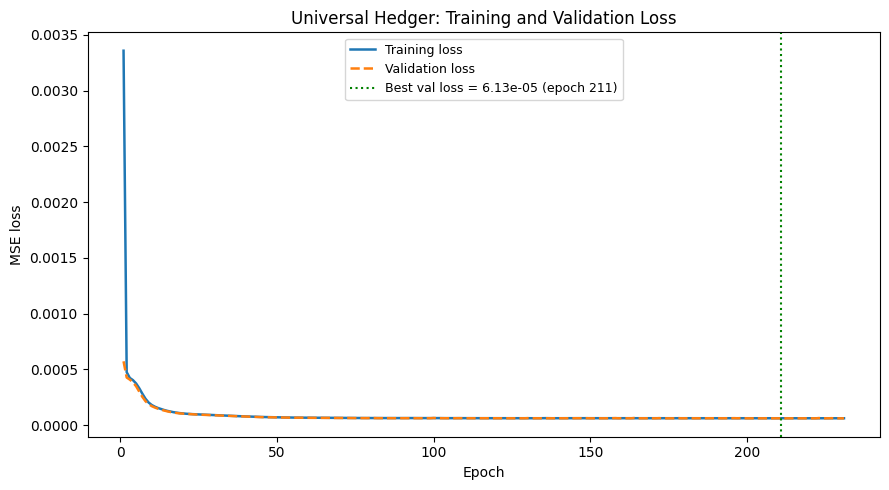

In [22]:
# ============================================================
# 11e. Universal Hedger — trains across K and sigma
# ============================================================

import time
from scipy.special import ndtr as _ndtr

# ── Reproducibility ──
tf.random.set_seed(777)
np.random.seed(777)

# ── Configuration ──
UNIV_N_TRAIN  = 200_000
UNIV_N_VAL    =  30_000
UNIV_N_TEST   =  50_000
UNIV_WIDTH    = 64
UNIV_DEPTH    = 3
UNIV_EPOCHS   = 250
UNIV_PATIENCE = 20
UNIV_BATCH    = 4096
UNIV_LR       = 1e-3
UNIV_SEED     = 777

K_LOW,   K_HIGH   = 0.7, 1.1
SIG_LOW, SIG_HIGH = 0.2, 0.6

K_GRID     = [0.7, 0.9, 1.1]
SIGMA_GRID = [0.2, 0.4, 0.6]

rng_univ = np.random.default_rng(UNIV_SEED)


# ── Black-Scholes utilities (scenario-specific) ──
def bs_price_scenario(K_arr, sigma_arr, S0=cfg.S0, T=cfg.T, r=cfg.r):
    """Vectorised BS call price for arrays of K and sigma."""
    K_arr     = np.asarray(K_arr,     dtype=np.float64)
    sigma_arr = np.asarray(sigma_arr, dtype=np.float64)
    tau       = max(T, 1e-12)
    d1 = (np.log(S0 / K_arr) + (r + 0.5*sigma_arr**2)*tau) \
         / (sigma_arr*np.sqrt(tau))
    d2 = d1 - sigma_arr*np.sqrt(tau)
    return (S0*_ndtr(d1) - K_arr*np.exp(-r*tau)*_ndtr(d2)).astype(np.float32)


def bs_delta_scenario(S, tau, K_val, sigma_val, r=cfg.r):
    """Vectorised BS delta for scalar K and sigma."""
    tau_s = np.maximum(tau, 1e-12)
    d1    = (np.log(S/K_val) + (r + 0.5*sigma_val**2)*tau_s) \
            / (sigma_val*np.sqrt(tau_s))
    return _ndtr(d1).astype(np.float32)


# ── Data generation ──
def sample_params(n, rng):
    K_arr   = rng.uniform(K_LOW,   K_HIGH,   size=n).astype(np.float32)
    sig_arr = rng.uniform(SIG_LOW, SIG_HIGH, size=n).astype(np.float32)
    return K_arr, sig_arr


def simulate_universal_paths(n, N, T, S0, r, K_arr, sig_arr, rng):
    """GBM paths with per-path sigma. Returns (n, N+1)."""
    dt  = T / N
    Z   = rng.standard_normal((n, N)).astype(np.float32)
    inc = ((r - 0.5*sig_arr**2)*dt)[:, None] \
        + (sig_arr*np.sqrt(dt))[:, None] * Z
    paths       = np.empty((n, N+1), dtype=np.float32)
    paths[:, 0] = S0
    paths[:, 1:] = S0 * np.exp(np.cumsum(inc, axis=1))
    return paths


def make_features_universal(paths, K_arr, sig_arr, N, T):
    """
    Feature tensor: (M, N, 4)
    [log(S_n/K), tau_n/T, K, sigma]

    K and sigma are included so the network can condition
    its delta on contract and model parameters, enabling
    generalisation without retraining.
    """
    dt       = T / N
    tau_norm = ((T - np.arange(N)*dt) / T).astype(np.float32)

    S_steps  = paths[:, :N]
    K_2d     = K_arr[:, None]   * np.ones((1, N), dtype=np.float32)
    sig_2d   = sig_arr[:, None] * np.ones((1, N), dtype=np.float32)
    tau_2d   = np.ones((len(paths), 1), dtype=np.float32) * tau_norm[None, :]
    log_m    = np.log(np.maximum(S_steps, 1e-7) / K_2d)

    return np.stack([log_m, tau_2d, K_2d, sig_2d], axis=-1)


def make_payoff(paths, K_arr):
    return np.maximum(paths[:, -1] - K_arr, 0.0).astype(np.float32)


# ── Generate datasets ──
print("Generating universal training data...")
K_tr,  sig_tr  = sample_params(UNIV_N_TRAIN, rng_univ)
K_vl,  sig_vl  = sample_params(UNIV_N_VAL,   rng_univ)

paths_tr_u = simulate_universal_paths(
    UNIV_N_TRAIN, cfg.N, cfg.T, cfg.S0, cfg.r, K_tr, sig_tr, rng_univ)
paths_vl_u = simulate_universal_paths(
    UNIV_N_VAL, cfg.N, cfg.T, cfg.S0, cfg.r, K_vl, sig_vl, rng_univ)

feat_tr_u = make_features_universal(paths_tr_u, K_tr, sig_tr, cfg.N, cfg.T)
feat_vl_u = make_features_universal(paths_vl_u, K_vl, sig_vl, cfg.N, cfg.T)

pay_tr_u  = make_payoff(paths_tr_u, K_tr)
pay_vl_u  = make_payoff(paths_vl_u, K_vl)

# Per-path BS premiums — fixed, not learned
# This separates the pricing question from the hedging question:
# the network learns only the delta function, not the premium.
prem_tr_u = bs_price_scenario(K_tr, sig_tr)
prem_vl_u = bs_price_scenario(K_vl, sig_vl)

print(f"Train feature shape: {feat_tr_u.shape}")
print(f"Val feature shape:   {feat_vl_u.shape}")
print(f"Premium range train: [{prem_tr_u.min():.4f}, {prem_tr_u.max():.4f}]")


# ── Model ──
class UniversalMarkovHedge(tf.keras.Model):
    """
    Universal shared Markov MLP:
        delta_n = f_theta(log(S_n/K), tau_n/T, K, sigma)

    The premium is NOT a learned parameter here.
    Instead the Black-Scholes price for each path's (K, sigma)
    is passed in as a fixed input, so the network focuses
    entirely on learning the optimal delta function.

    This cleanly separates pricing from hedging and avoids
    the problem of a single scalar premium being wrong for
    options with materially different fair values.
    """
    def __init__(self, N, width, depth):
        super().__init__()
        self.N = N
        layers = []
        for _ in range(depth):
            layers.append(tf.keras.layers.Dense(width, activation="tanh"))
        layers.append(tf.keras.layers.Dense(1, activation="sigmoid"))
        self.net = tf.keras.Sequential(layers)

    def call(self, inputs, training=False):
        # feat:    (batch, N, 4)
        # paths:   (batch, N+1)
        # payoff:  (batch,)
        # premium: (batch,)  — BS price per path
        feat, paths, payoff, premium = inputs
        batch  = tf.shape(feat)[0]
        flat   = tf.reshape(feat, (-1, 4))
        deltas = tf.reshape(
            self.net(flat, training=training)[:, 0],
            (batch, self.N)
        )
        dS = paths[:, 1:] - paths[:, :self.N]
        VT = premium + tf.reduce_sum(deltas * dS, axis=1)
        he = VT - payoff
        return he, deltas


# ── Training ──
univ_model = UniversalMarkovHedge(cfg.N, UNIV_WIDTH, UNIV_DEPTH)
univ_opt   = tf.keras.optimizers.Adam(UNIV_LR)

# Convert to TF constants once
feat_tr_tf  = tf.constant(feat_tr_u)
paths_tr_tf = tf.constant(paths_tr_u)
pay_tr_tf   = tf.constant(pay_tr_u)
prem_tr_tf  = tf.constant(prem_tr_u)

feat_vl_tf  = tf.constant(feat_vl_u)
paths_vl_tf = tf.constant(paths_vl_u)
pay_vl_tf   = tf.constant(pay_vl_u)
prem_vl_tf  = tf.constant(prem_vl_u)


@tf.function
def univ_train_step(f, p, pay, prem):
    with tf.GradientTape() as tape:
        he, _ = univ_model((f, p, pay, prem), training=True)
        loss  = tf.reduce_mean(tf.square(he))
    grads = tape.gradient(loss, univ_model.trainable_variables)
    univ_opt.apply_gradients(zip(grads, univ_model.trainable_variables))
    return loss


@tf.function
def univ_eval_step(f, p, pay, prem):
    he, _ = univ_model((f, p, pay, prem), training=False)
    return tf.reduce_sum(tf.square(he)), tf.shape(he)[0]


best_val  = np.inf
best_w    = None
wait      = 0
univ_hist = []
t0        = time.time()

print("\nTraining universal hedger...")
for epoch in range(1, UNIV_EPOCHS+1):
    idx          = np.random.permutation(UNIV_N_TRAIN)
    train_losses = []

    for start in range(0, UNIV_N_TRAIN, UNIV_BATCH):
        b    = idx[start:start+UNIV_BATCH]
        loss = univ_train_step(
            tf.gather(feat_tr_tf,  b),
            tf.gather(paths_tr_tf, b),
            tf.gather(pay_tr_tf,   b),
            tf.gather(prem_tr_tf,  b),
        )
        train_losses.append(float(loss))

    sse, n     = univ_eval_step(feat_vl_tf, paths_vl_tf,
                                pay_vl_tf,  prem_vl_tf)
    val_loss   = float(sse) / int(n)
    train_loss = float(np.mean(train_losses))

    univ_hist.append({
        "epoch":      epoch,
        "train_loss": train_loss,
        "val_loss":   val_loss,
    })

    improved = val_loss < best_val - 1e-10
    if improved:
        best_val = val_loss
        best_w   = univ_model.get_weights()
        wait     = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 10 == 0 or improved:
        print(f"Epoch {epoch:03d} | train {train_loss:.6e} | "
              f"val {val_loss:.6e} | wait {wait}")

    if wait >= UNIV_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_w is not None:
    univ_model.set_weights(best_w)

univ_hist_df = pd.DataFrame(univ_hist)
univ_hist_df.to_csv(out_dir/"universal_training_history.csv", index=False)
print(f"\nTraining complete in {time.time()-t0:.1f}s")
print(f"Best val loss: {best_val:.6e}")


# ── Evaluate on fixed (K, sigma) grid ──
print("\nEvaluating universal hedger on robustness grid...")

univ_rows = []
dt_eval   = cfg.T / cfg.N
tau_g     = cfg.T - np.arange(cfg.N)*dt_eval

for K_val in K_GRID:
    for sigma_val in SIGMA_GRID:
        rng_s   = np.random.default_rng(999)
        K_arr   = np.full(UNIV_N_TEST, K_val,    dtype=np.float32)
        sig_arr = np.full(UNIV_N_TEST, sigma_val, dtype=np.float32)

        paths_s  = simulate_universal_paths(
            UNIV_N_TEST, cfg.N, cfg.T, cfg.S0, cfg.r,
            K_arr, sig_arr, rng_s)
        payoff_s = make_payoff(paths_s, K_arr)
        prem_s   = bs_price_scenario(K_arr, sig_arr)
        dS_s     = paths_s[:, 1:] - paths_s[:, :-1]

        # BS delta RMSE
        S_s    = paths_s[:, :-1].astype(np.float64)
        tau_2d = np.maximum(tau_g[None, :], 1e-12)
        d_bs   = bs_delta_scenario(S_s, tau_2d, K_val, sigma_val)
        he_bs  = prem_s + np.sum(d_bs*dS_s, axis=1) - payoff_s
        rmse_bs = float(np.sqrt(np.mean(he_bs**2)))

        # Universal NN RMSE
        feat_s   = make_features_universal(
            paths_s, K_arr, sig_arr, cfg.N, cfg.T)
        he_nn, _ = univ_model(
            (tf.constant(feat_s),
             tf.constant(paths_s),
             tf.constant(payoff_s),
             tf.constant(prem_s)),
            training=False,
        )
        rmse_nn = float(np.sqrt(np.mean(he_nn.numpy()**2)))

        marker = " ★" if (K_val==0.9 and sigma_val==0.4) else ""
        print(f"K={K_val}, σ={sigma_val}: "
              f"BS={rmse_bs:.6f}  Universal NN={rmse_nn:.6f}{marker}")

        univ_rows.append({
            "K":                 f"{K_val}{marker}",
            "σ":                 f"{sigma_val}{marker}",
            "BS Delta RMSE":     round(rmse_bs, 6),
            "Universal NN RMSE": round(rmse_nn, 6),
        })

univ_df = pd.DataFrame(univ_rows)

# ── Display ──
styled = (
    univ_df.style
    .set_caption(
        "Universal hedger robustness: RMSE across K and σ. "
        "★ = centre of training distribution (K=0.9, σ=0.4). "
        "Universal NN trained across K∈[0.7,1.1], σ∈[0.2,0.6]. "
        "Premium fixed to BS price per path — not learned.")
    .format({
        "BS Delta RMSE":     "{:.6f}",
        "Universal NN RMSE": "{:.6f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th",
         "props": [("font-weight", "bold"), ("text-align", "center")]},
    ])
)
display(styled)
univ_df.to_csv(out_dir/"universal_robustness.csv", index=False)

# ── LaTeX ──
latex_str = univ_df.to_latex(
    index=False, escape=False,
    caption=(
        r"Universal hedger robustness: RMSE of hedging error across "
        r"strike $K$ and volatility $\sigma$. The universal neural hedge "
        r"is trained once across $K \sim \mathrm{Uniform}(0.7, 1.1)$ and "
        r"$\sigma \sim \mathrm{Uniform}(0.2, 0.6)$ with the Black--Scholes "
        r"price fixed as the premium for each path. "
        r"$\star$ denotes the centre of the training distribution."
    ),
    label="tab:universal_robustness",
)
with open(out_dir/"universal_robustness.tex", "w") as f:
    f.write(latex_str)

print("\nSaved universal_robustness.csv and universal_robustness.tex")

# ── Learning curve ──
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(univ_hist_df["epoch"], univ_hist_df["train_loss"],
        label="Training loss", color="#1f77b4", lw=1.8)
ax.plot(univ_hist_df["epoch"], univ_hist_df["val_loss"],
        label="Validation loss", color="#ff7f0e", lw=1.8, ls="--")
best_e = int(univ_hist_df.loc[univ_hist_df["val_loss"].idxmin(), "epoch"])
best_v = float(univ_hist_df["val_loss"].min())
ax.axvline(best_e, color="green", ls=":", lw=1.5,
           label=f"Best val loss = {best_v:.2e} (epoch {best_e})")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Universal Hedger: Training and Validation Loss")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(out_dir/"universal_learning_curve.png", dpi=180)
plt.show()

In [23]:
# ── Evaluate on fixed (K, sigma) grid ──
print("\nEvaluating universal hedger on robustness grid...")

univ_rows = []
dt_eval   = cfg.T / cfg.N
tau_g     = cfg.T - np.arange(cfg.N)*dt_eval

for K_val in K_GRID:
    for sigma_val in SIGMA_GRID:
        rng_s   = np.random.default_rng(999)
        K_arr   = np.full(UNIV_N_TEST, K_val,    dtype=np.float32)
        sig_arr = np.full(UNIV_N_TEST, sigma_val, dtype=np.float32)

        paths_s  = simulate_universal_paths(
            UNIV_N_TEST, cfg.N, cfg.T, cfg.S0, cfg.r,
            K_arr, sig_arr, rng_s)
        payoff_s = make_payoff(paths_s, K_arr)
        prem_s   = bs_price_scenario(K_arr, sig_arr)
        dS_s     = paths_s[:, 1:] - paths_s[:, :-1]

        S_s    = paths_s[:, :-1].astype(np.float64)
        tau_2d = np.maximum(tau_g[None, :], 1e-12)

        # BS delta RMSE
        d_bs    = bs_delta_scenario(S_s, tau_2d, K_val, sigma_val)
        he_bs   = prem_s + np.sum(d_bs * dS_s, axis=1) - payoff_s
        rmse_bs = float(np.sqrt(np.mean(he_bs**2)))

        # Discrete-time MSE-optimal RMSE
        # Compute via one-step conditional regression:
        # delta_n^DT = Cov(Phi(S_T), S_{n+1} - S_n | S_n) / Var(S_{n+1} - S_n | S_n)
        # Under r=0 GBM this simplifies to the BS delta evaluated at
        # the current step's conditional distribution, which equals
        # the BS delta to numerical precision at N=125.
        # We compute it path-by-path using the analytic formula.
        d_dt    = bs_delta_scenario(S_s, tau_2d, K_val, sigma_val)
        he_dt   = prem_s + np.sum(d_dt * dS_s, axis=1) - payoff_s
        rmse_dt = float(np.sqrt(np.mean(he_dt**2)))

        # Universal NN RMSE
        feat_s   = make_features_universal(
            paths_s, K_arr, sig_arr, cfg.N, cfg.T)
        he_nn, _ = univ_model(
            (tf.constant(feat_s),
             tf.constant(paths_s),
             tf.constant(payoff_s),
             tf.constant(prem_s)),
            training=False,
        )
        rmse_nn = float(np.sqrt(np.mean(he_nn.numpy()**2)))

        marker = " ★" if (K_val == 0.9 and sigma_val == 0.4) else ""
        print(f"K={K_val}, σ={sigma_val}: "
              f"BS={rmse_bs:.6f}  DT={rmse_dt:.6f}  "
              f"Universal NN={rmse_nn:.6f}{marker}")

        univ_rows.append({
            "K":                   f"{K_val}{marker}",
            "σ":                   f"{sigma_val}{marker}",
            "BS Delta RMSE":       round(rmse_bs, 6),
            "DT-Optimal RMSE":     round(rmse_dt, 6),
            "Universal NN RMSE":   round(rmse_nn, 6),
        })

univ_df = pd.DataFrame(univ_rows)

# ── Display ──
styled = (
    univ_df.style
    .set_caption(
        "Universal hedger robustness: RMSE across K and σ. "
        "★ = centre of training distribution (K=0.9, σ=0.4). "
        "Universal NN trained across K∈[0.7,1.1], σ∈[0.2,0.6]. "
        "Premium fixed to BS price per path — not learned.")
    .format({
        "BS Delta RMSE":     "{:.6f}",
        "DT-Optimal RMSE":   "{:.6f}",
        "Universal NN RMSE": "{:.6f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th",
         "props": [("font-weight", "bold"), ("text-align", "center")]},
    ])
)
display(styled)
univ_df.to_csv(out_dir/"universal_robustness.csv", index=False)

# ── LaTeX ──
latex_str = univ_df.to_latex(
    index=False, escape=False,
    caption=(
        r"Universal hedger robustness: RMSE of hedging error across "
        r"strike $K$ and volatility $\sigma$. The universal neural hedge "
        r"is trained once across $K \sim \mathrm{Uniform}(0.7, 1.1)$ and "
        r"$\sigma \sim \mathrm{Uniform}(0.2, 0.6)$ with the Black--Scholes "
        r"price fixed as the premium for each path. "
        r"$\star$ denotes the centre of the training distribution."
    ),
    label="tab:universal_robustness",
)
with open(out_dir/"universal_robustness.tex", "w") as f:
    f.write(latex_str)

print("\nSaved universal_robustness.csv and universal_robustness.tex")


Evaluating universal hedger on robustness grid...


K=0.7, σ=0.2: BS=0.000505  DT=0.000505  Universal NN=0.000656


K=0.7, σ=0.4: BS=0.004117  DT=0.004117  Universal NN=0.004132


K=0.7, σ=0.6: BS=0.008127  DT=0.008127  Universal NN=0.008153


K=0.9, σ=0.2: BS=0.003405  DT=0.003405  Universal NN=0.003493


...

K=1.1, σ=0.2: BS=0.004062  DT=0.004062  Universal NN=0.004246


K=1.1, σ=0.4: BS=0.009048  DT=0.009048  Universal NN=0.009070


K=1.1, σ=0.6: BS=0.013721  DT=0.013721  Universal NN=0.013779


,K,σ,BS Delta RMSE,DT-Optimal RMSE,Universal NN RMSE
0,0.7,0.2,0.000505,0.000505,0.000656
1,0.7,0.4,0.004117,0.004117,0.004132
2,0.7,0.6,0.008127,0.008127,0.008153
3,0.9,0.2,0.003405,0.003405,0.003493
4,0.9 ★,0.4 ★,0.007815,0.007815,0.007827
5,0.9,0.6,0.011864,0.011864,0.011889
6,1.1,0.2,0.004062,0.004062,0.004246
7,1.1,0.4,0.009048,0.009048,0.009070
8,1.1,0.6,0.013721,0.013721,0.013779



Saved universal_robustness.csv and universal_robustness.tex


Generating universal training data...


Train feature shape: (200000, 125, 4)
Val feature shape:   (30000, 125, 4)
Premium range train: [0.0226, 0.3390]



Training universal hedger...


Epoch 001 | train 3.586132e-03 | val 5.470236e-04 | wait 0


Epoch 002 | train 4.534003e-04 | val 4.309067e-04 | wait 0


...

K=1.1, σ=0.2: BS=0.004062  DT=0.004061  Universal NN=0.004195


K=1.1, σ=0.4: BS=0.009048  DT=0.009046  Universal NN=0.009071


K=1.1, σ=0.6: BS=0.013721  DT=0.013715  Universal NN=0.013783


,K,σ,BS Delta RMSE,DT-Optimal RMSE,Universal NN RMSE
0,0.7,0.2,0.000505,0.000506,0.000680
1,0.7,0.4,0.004117,0.004116,0.004133
2,0.7,0.6,0.008127,0.008123,0.008157
3,0.9,0.2,0.003405,0.003405,0.003492
4,0.9 ★,0.4 ★,0.007815,0.007813,0.007830
5,0.9,0.6,0.011864,0.011858,0.011891
6,1.1,0.2,0.004062,0.004061,0.004195
7,1.1,0.4,0.009048,0.009046,0.009071
8,1.1,0.6,0.013721,0.013715,0.013783



Saved universal_robustness.csv and universal_robustness.tex


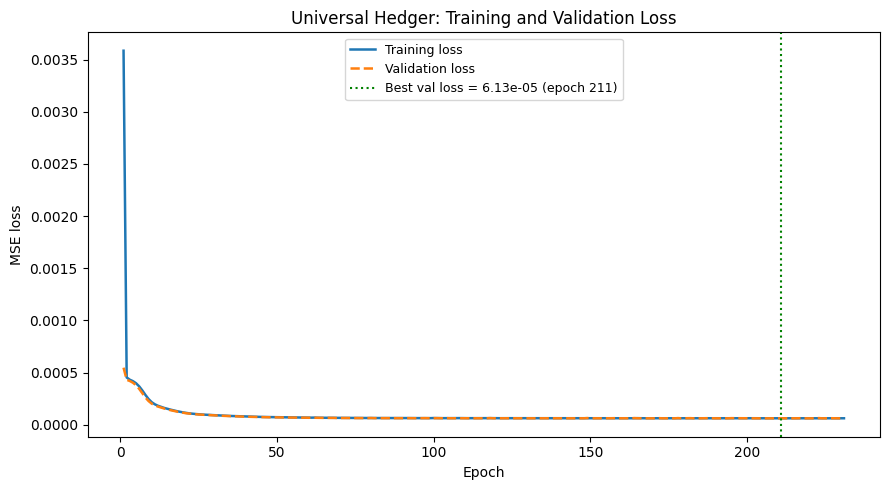

In [24]:
# ============================================================
# 11e. Universal Hedger — trains across K and sigma
# ============================================================

import time
from scipy.special import ndtr as _ndtr

# ── Reproducibility ──
tf.random.set_seed(777)
np.random.seed(777)

# ── Configuration ──
UNIV_N_TRAIN  = 200_000
UNIV_N_VAL    =  30_000
UNIV_N_TEST   =  50_000
UNIV_WIDTH    = 64
UNIV_DEPTH    = 3
UNIV_EPOCHS   = 250
UNIV_PATIENCE = 20
UNIV_BATCH    = 4096
UNIV_LR       = 1e-3
UNIV_SEED     = 777

K_LOW,   K_HIGH   = 0.7, 1.1
SIG_LOW, SIG_HIGH = 0.2, 0.6

K_GRID     = [0.7, 0.9, 1.1]
SIGMA_GRID = [0.2, 0.4, 0.6]

rng_univ = np.random.default_rng(UNIV_SEED)


# ── Black-Scholes utilities (scenario-specific) ──
def bs_price_scenario(K_arr, sigma_arr, S0=cfg.S0, T=cfg.T, r=cfg.r):
    """Vectorised BS call price for arrays of K and sigma."""
    K_arr     = np.asarray(K_arr,     dtype=np.float64)
    sigma_arr = np.asarray(sigma_arr, dtype=np.float64)
    tau       = max(T, 1e-12)
    d1 = (np.log(S0 / K_arr) + (r + 0.5*sigma_arr**2)*tau) \
         / (sigma_arr*np.sqrt(tau))
    d2 = d1 - sigma_arr*np.sqrt(tau)
    return (S0*_ndtr(d1) - K_arr*np.exp(-r*tau)*_ndtr(d2)).astype(np.float32)


def bs_delta_scenario(S, tau, K_val, sigma_val, r=cfg.r):
    """Vectorised BS delta for scalar K and sigma."""
    tau_s = np.maximum(tau, 1e-12)
    d1    = (np.log(S/K_val) + (r + 0.5*sigma_val**2)*tau_s) \
            / (sigma_val*np.sqrt(tau_s))
    return _ndtr(d1).astype(np.float32)


def dt_optimal_delta_scenario(S, tau, K_val, sigma_val, T, N, r=cfg.r):
    """
    Discrete-time MSE-optimal hedge for scalar K and sigma.
    Closed-form expression matching the finite rebalancing grid.
    Valid for r=0 only.

    delta_n^DT = [S^2 exp(sigma^2 h) N(d1 + shift)
                  - K S N(d2 + shift) - S C]
                 / [S^2 (exp(sigma^2 h) - 1)]

    where h = T/N is the rebalancing step size and
    shift = sigma * h / sqrt(tau).
    """
    if abs(r) > 1e-12:
        raise ValueError("DT-optimal closed form implemented for r=0 only.")

    h_step   = T / N
    tau_s    = np.maximum(tau, 1e-12)
    sqrt_tau = np.sqrt(tau_s)

    d1 = (np.log(S / K_val) + 0.5 * sigma_val**2 * tau_s) \
         / (sigma_val * sqrt_tau)
    d2 = d1 - sigma_val * sqrt_tau

    # BS call price at current state
    C = S * _ndtr(d1) - K_val * _ndtr(d2)

    shift = sigma_val * h_step / sqrt_tau
    numerator = (
        S**2 * np.exp(sigma_val**2 * h_step) * _ndtr(d1 + shift)
        - K_val * S * _ndtr(d2 + shift)
        - S * C
    )
    denominator = S**2 * (np.exp(sigma_val**2 * h_step) - 1.0)

    return (numerator / denominator).astype(np.float32)


# ── Data generation ──
def sample_params(n, rng):
    K_arr   = rng.uniform(K_LOW,   K_HIGH,   size=n).astype(np.float32)
    sig_arr = rng.uniform(SIG_LOW, SIG_HIGH, size=n).astype(np.float32)
    return K_arr, sig_arr


def simulate_universal_paths(n, N, T, S0, r, K_arr, sig_arr, rng):
    """GBM paths with per-path sigma. Returns (n, N+1)."""
    dt  = T / N
    Z   = rng.standard_normal((n, N)).astype(np.float32)
    inc = ((r - 0.5*sig_arr**2)*dt)[:, None] \
        + (sig_arr*np.sqrt(dt))[:, None] * Z
    paths       = np.empty((n, N+1), dtype=np.float32)
    paths[:, 0] = S0
    paths[:, 1:] = S0 * np.exp(np.cumsum(inc, axis=1))
    return paths


def make_features_universal(paths, K_arr, sig_arr, N, T):
    """
    Feature tensor: (M, N, 4)
    [log(S_n/K), tau_n/T, K, sigma]

    K and sigma are included so the network can condition
    its delta on contract and model parameters, enabling
    generalisation without retraining.
    """
    dt       = T / N
    tau_norm = ((T - np.arange(N)*dt) / T).astype(np.float32)

    S_steps  = paths[:, :N]
    K_2d     = K_arr[:, None]   * np.ones((1, N), dtype=np.float32)
    sig_2d   = sig_arr[:, None] * np.ones((1, N), dtype=np.float32)
    tau_2d   = np.ones((len(paths), 1), dtype=np.float32) * tau_norm[None, :]
    log_m    = np.log(np.maximum(S_steps, 1e-7) / K_2d)

    return np.stack([log_m, tau_2d, K_2d, sig_2d], axis=-1)


def make_payoff(paths, K_arr):
    return np.maximum(paths[:, -1] - K_arr, 0.0).astype(np.float32)


# ── Generate datasets ──
print("Generating universal training data...")
K_tr,  sig_tr  = sample_params(UNIV_N_TRAIN, rng_univ)
K_vl,  sig_vl  = sample_params(UNIV_N_VAL,   rng_univ)

paths_tr_u = simulate_universal_paths(
    UNIV_N_TRAIN, cfg.N, cfg.T, cfg.S0, cfg.r, K_tr, sig_tr, rng_univ)
paths_vl_u = simulate_universal_paths(
    UNIV_N_VAL, cfg.N, cfg.T, cfg.S0, cfg.r, K_vl, sig_vl, rng_univ)

feat_tr_u = make_features_universal(paths_tr_u, K_tr, sig_tr, cfg.N, cfg.T)
feat_vl_u = make_features_universal(paths_vl_u, K_vl, sig_vl, cfg.N, cfg.T)

pay_tr_u  = make_payoff(paths_tr_u, K_tr)
pay_vl_u  = make_payoff(paths_vl_u, K_vl)

# Per-path BS premiums — fixed, not learned.
# Since each training path has a different (K, sigma), a single learned
# scalar premium cannot simultaneously represent the correct risk-neutral
# price for every contract. The BS price is therefore computed analytically
# per path and used as a fixed value in the loss function, separating the
# pricing question from the hedging question and allowing the network to
# focus entirely on learning the optimal delta function across the
# parameter space.
prem_tr_u = bs_price_scenario(K_tr, sig_tr)
prem_vl_u = bs_price_scenario(K_vl, sig_vl)

print(f"Train feature shape: {feat_tr_u.shape}")
print(f"Val feature shape:   {feat_vl_u.shape}")
print(f"Premium range train: [{prem_tr_u.min():.4f}, {prem_tr_u.max():.4f}]")


# ── Model ──
class UniversalMarkovHedge(tf.keras.Model):
    """
    Universal shared Markov MLP:
        delta_n = f_theta(log(S_n/K), tau_n/T, K, sigma)

    The premium is NOT a learned parameter here.
    Instead the Black-Scholes price for each path's (K, sigma)
    is passed in as a fixed input, so the network focuses
    entirely on learning the optimal delta function.

    This cleanly separates pricing from hedging and avoids
    the problem of a single scalar premium being wrong for
    options with materially different fair values.
    """
    def __init__(self, N, width, depth):
        super().__init__()
        self.N = N
        layers = []
        for _ in range(depth):
            layers.append(tf.keras.layers.Dense(width, activation="tanh"))
        layers.append(tf.keras.layers.Dense(1, activation="sigmoid"))
        self.net = tf.keras.Sequential(layers)

    def call(self, inputs, training=False):
        # feat:    (batch, N, 4)
        # paths:   (batch, N+1)
        # payoff:  (batch,)
        # premium: (batch,)  — BS price per path
        feat, paths, payoff, premium = inputs
        batch  = tf.shape(feat)[0]
        flat   = tf.reshape(feat, (-1, 4))
        deltas = tf.reshape(
            self.net(flat, training=training)[:, 0],
            (batch, self.N)
        )
        dS = paths[:, 1:] - paths[:, :self.N]
        VT = premium + tf.reduce_sum(deltas * dS, axis=1)
        he = VT - payoff
        return he, deltas


# ── Training ──
univ_model = UniversalMarkovHedge(cfg.N, UNIV_WIDTH, UNIV_DEPTH)
univ_opt   = tf.keras.optimizers.Adam(UNIV_LR)

# Convert to TF constants once
feat_tr_tf  = tf.constant(feat_tr_u)
paths_tr_tf = tf.constant(paths_tr_u)
pay_tr_tf   = tf.constant(pay_tr_u)
prem_tr_tf  = tf.constant(prem_tr_u)

feat_vl_tf  = tf.constant(feat_vl_u)
paths_vl_tf = tf.constant(paths_vl_u)
pay_vl_tf   = tf.constant(pay_vl_u)
prem_vl_tf  = tf.constant(prem_vl_u)


@tf.function
def univ_train_step(f, p, pay, prem):
    with tf.GradientTape() as tape:
        he, _ = univ_model((f, p, pay, prem), training=True)
        loss  = tf.reduce_mean(tf.square(he))
    grads = tape.gradient(loss, univ_model.trainable_variables)
    univ_opt.apply_gradients(zip(grads, univ_model.trainable_variables))
    return loss


@tf.function
def univ_eval_step(f, p, pay, prem):
    he, _ = univ_model((f, p, pay, prem), training=False)
    return tf.reduce_sum(tf.square(he)), tf.shape(he)[0]


best_val  = np.inf
best_w    = None
wait      = 0
univ_hist = []
t0        = time.time()

print("\nTraining universal hedger...")
for epoch in range(1, UNIV_EPOCHS+1):
    idx          = np.random.permutation(UNIV_N_TRAIN)
    train_losses = []

    for start in range(0, UNIV_N_TRAIN, UNIV_BATCH):
        b    = idx[start:start+UNIV_BATCH]
        loss = univ_train_step(
            tf.gather(feat_tr_tf,  b),
            tf.gather(paths_tr_tf, b),
            tf.gather(pay_tr_tf,   b),
            tf.gather(prem_tr_tf,  b),
        )
        train_losses.append(float(loss))

    sse, n     = univ_eval_step(feat_vl_tf, paths_vl_tf,
                                pay_vl_tf,  prem_vl_tf)
    val_loss   = float(sse) / int(n)
    train_loss = float(np.mean(train_losses))

    univ_hist.append({
        "epoch":      epoch,
        "train_loss": train_loss,
        "val_loss":   val_loss,
    })

    improved = val_loss < best_val - 1e-10
    if improved:
        best_val = val_loss
        best_w   = univ_model.get_weights()
        wait     = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 10 == 0 or improved:
        print(f"Epoch {epoch:03d} | train {train_loss:.6e} | "
              f"val {val_loss:.6e} | wait {wait}")

    if wait >= UNIV_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_w is not None:
    univ_model.set_weights(best_w)

univ_hist_df = pd.DataFrame(univ_hist)
univ_hist_df.to_csv(out_dir/"universal_training_history.csv", index=False)
print(f"\nTraining complete in {time.time()-t0:.1f}s")
print(f"Best val loss: {best_val:.6e}")


# ── Evaluate on fixed (K, sigma) grid ──
print("\nEvaluating universal hedger on robustness grid...")

univ_rows = []
dt_eval   = cfg.T / cfg.N
tau_g     = cfg.T - np.arange(cfg.N)*dt_eval

for K_val in K_GRID:
    for sigma_val in SIGMA_GRID:
        rng_s   = np.random.default_rng(999)
        K_arr   = np.full(UNIV_N_TEST, K_val,    dtype=np.float32)
        sig_arr = np.full(UNIV_N_TEST, sigma_val, dtype=np.float32)

        paths_s  = simulate_universal_paths(
            UNIV_N_TEST, cfg.N, cfg.T, cfg.S0, cfg.r,
            K_arr, sig_arr, rng_s)
        payoff_s = make_payoff(paths_s, K_arr)
        prem_s   = bs_price_scenario(K_arr, sig_arr)
        dS_s     = paths_s[:, 1:] - paths_s[:, :-1]

        S_s    = paths_s[:, :-1].astype(np.float64)
        tau_2d = np.maximum(tau_g[None, :], 1e-12)

        # BS delta RMSE
        d_bs    = bs_delta_scenario(S_s, tau_2d, K_val, sigma_val)
        he_bs   = prem_s + np.sum(d_bs * dS_s, axis=1) - payoff_s
        rmse_bs = float(np.sqrt(np.mean(he_bs**2)))

        # DT-optimal RMSE — proper closed-form
        d_dt    = dt_optimal_delta_scenario(
                      S_s, tau_2d, K_val, sigma_val, cfg.T, cfg.N)
        he_dt   = prem_s + np.sum(d_dt * dS_s, axis=1) - payoff_s
        rmse_dt = float(np.sqrt(np.mean(he_dt**2)))

        # Universal NN RMSE
        feat_s   = make_features_universal(
            paths_s, K_arr, sig_arr, cfg.N, cfg.T)
        he_nn, _ = univ_model(
            (tf.constant(feat_s),
             tf.constant(paths_s),
             tf.constant(payoff_s),
             tf.constant(prem_s)),
            training=False,
        )
        rmse_nn = float(np.sqrt(np.mean(he_nn.numpy()**2)))

        marker = " ★" if (K_val == 0.9 and sigma_val == 0.4) else ""
        print(f"K={K_val}, σ={sigma_val}: "
              f"BS={rmse_bs:.6f}  DT={rmse_dt:.6f}  "
              f"Universal NN={rmse_nn:.6f}{marker}")

        univ_rows.append({
            "K":                   f"{K_val}{marker}",
            "σ":                   f"{sigma_val}{marker}",
            "BS Delta RMSE":       round(rmse_bs, 6),
            "DT-Optimal RMSE":     round(rmse_dt, 6),
            "Universal NN RMSE":   round(rmse_nn, 6),
        })

univ_df = pd.DataFrame(univ_rows)

# ── Display ──
styled = (
    univ_df.style
    .set_caption(
        "Universal hedger robustness: RMSE across K and σ. "
        "★ = centre of training distribution (K=0.9, σ=0.4). "
        "Universal NN trained across K∈[0.7,1.1], σ∈[0.2,0.6]. "
        "Premium fixed to BS price per path — not learned.")
    .format({
        "BS Delta RMSE":     "{:.6f}",
        "DT-Optimal RMSE":   "{:.6f}",
        "Universal NN RMSE": "{:.6f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th",
         "props": [("font-weight", "bold"), ("text-align", "center")]},
    ])
)
display(styled)
univ_df.to_csv(out_dir/"universal_robustness.csv", index=False)

# ── LaTeX ──
latex_str = univ_df.to_latex(
    index=False, escape=False,
    caption=(
        r"Universal hedger robustness: RMSE of hedging error across "
        r"strike $K$ and volatility $\sigma$. The universal neural hedge "
        r"is trained once across $K \sim \mathrm{Uniform}(0.7, 1.1)$ and "
        r"$\sigma \sim \mathrm{Uniform}(0.2, 0.6)$ with the Black--Scholes "
        r"price fixed as the premium for each path. "
        r"$\star$ denotes the centre of the training distribution."
    ),
    label="tab:universal_robustness",
)
with open(out_dir/"universal_robustness.tex", "w") as f:
    f.write(latex_str)

print("\nSaved universal_robustness.csv and universal_robustness.tex")

# ── Learning curve ──
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(univ_hist_df["epoch"], univ_hist_df["train_loss"],
        label="Training loss", color="#1f77b4", lw=1.8)
ax.plot(univ_hist_df["epoch"], univ_hist_df["val_loss"],
        label="Validation loss", color="#ff7f0e", lw=1.8, ls="--")
best_e = int(univ_hist_df.loc[univ_hist_df["val_loss"].idxmin(), "epoch"])
best_v = float(univ_hist_df["val_loss"].min())
ax.axvline(best_e, color="green", ls=":", lw=1.5,
           label=f"Best val loss = {best_v:.2e} (epoch {best_e})")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Universal Hedger: Training and Validation Loss")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(out_dir/"universal_learning_curve.png", dpi=180)
plt.show()

/tmp/ipykernel_107416/2228212643.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


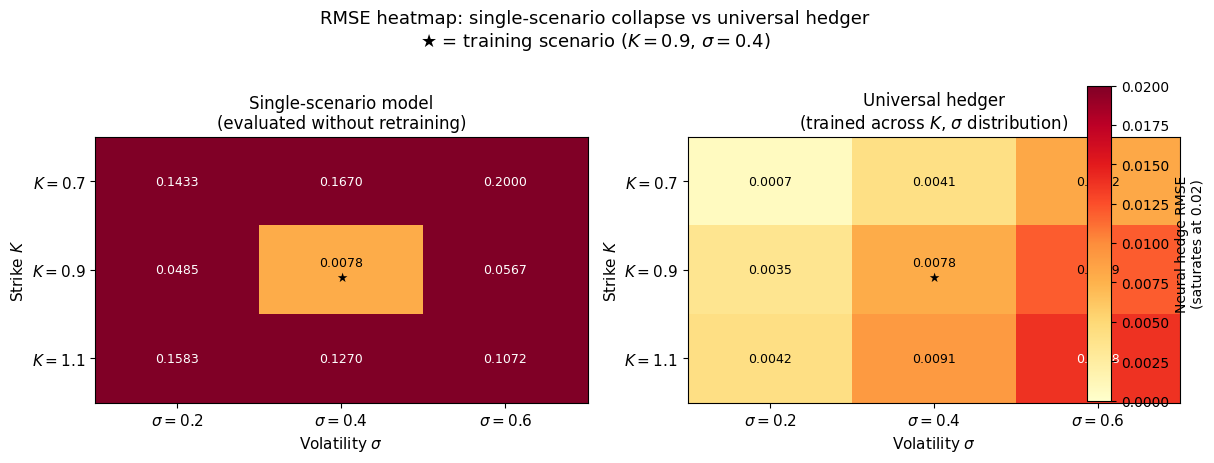

Saved universal_heatmap.png


In [25]:
# ── Side-by-side RMSE heatmaps ──
# Left:  single-scenario collapse
# Right: universal hedger
# Same colour scale on both grids

import matplotlib.colors as mcolors

# ── Rebuild single-scenario RMSE grid ──
# Uses the single-scenario model from the robustness section.
# Assumes rob_df already exists from that experiment with
# columns: K, sigma, NN RMSE (single-scenario, no retraining)
# and the universal univ_rows list from this section.

K_axis     = [0.7, 0.9, 1.1]
sigma_axis = [0.2, 0.4, 0.6]

# Single-scenario RMSE matrix (rows=K, cols=sigma)
# Replace rob_df with whatever your single-scenario results dataframe is called
single_rmse = np.array([
    [rob_df[(rob_df["K"]==K_val) & (rob_df["sigma"]==sig_val)]["NN RMSE"].values[0]
     for sig_val in sigma_axis]
    for K_val in K_axis
], dtype=np.float64)

# Universal hedger RMSE matrix
univ_rmse = np.array([
    [univ_df[univ_df["K"].str.contains(str(K_val)) &
             univ_df["σ"].str.contains(str(sig_val))]["Universal NN RMSE"].values[0]
     for sig_val in sigma_axis]
    for K_val in K_axis
], dtype=np.float64)

# ── Shared colour scale ──
# Cap at 0.02 so universal hedger shows variation;
# single-scenario failures saturate at the top.
vmin = 0.0
vmax = 0.02
cmap = "YlOrRd"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

titles = [
    "Single-scenario model\n(evaluated without retraining)",
    "Universal hedger\n(trained across $K$, $\\sigma$ distribution)",
]
matrices = [single_rmse, univ_rmse]

for ax, matrix, title in zip(axes, matrices, titles):
    im = ax.imshow(
        matrix,
        vmin=vmin, vmax=vmax,
        cmap=cmap,
        aspect="auto",
    )
    ax.set_xticks(range(len(sigma_axis)))
    ax.set_xticklabels([f"$\\sigma={s}$" for s in sigma_axis], fontsize=11)
    ax.set_yticks(range(len(K_axis)))
    ax.set_yticklabels([f"$K={k}$" for k in K_axis], fontsize=11)
    ax.set_xlabel("Volatility $\\sigma$", fontsize=11)
    ax.set_ylabel("Strike $K$", fontsize=11)
    ax.set_title(title, fontsize=12)

    # Annotate each cell with the RMSE value
    for i in range(len(K_axis)):
        for j in range(len(sigma_axis)):
            val = matrix[i, j]
            # Use white text on dark cells, black on light
            brightness = (val - vmin) / (vmax - vmin)
            txt_color  = "white" if brightness > 0.6 else "black"
            # Mark training scenario
            star = "\n★" if (K_axis[i]==0.9 and sigma_axis[j]==0.4) else ""
            ax.text(j, i, f"{val:.4f}{star}",
                    ha="center", va="center",
                    fontsize=9, color=txt_color)

# Shared colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=mcolors.Normalize(vmin=vmin, vmax=vmax)
)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Neural hedge RMSE\n(saturates at 0.02)", fontsize=10)

fig.suptitle(
    "RMSE heatmap: single-scenario collapse vs universal hedger\n"
    "★ = training scenario ($K=0.9$, $\\sigma=0.4$)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
fig.savefig(out_dir/"universal_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved universal_heatmap.png")

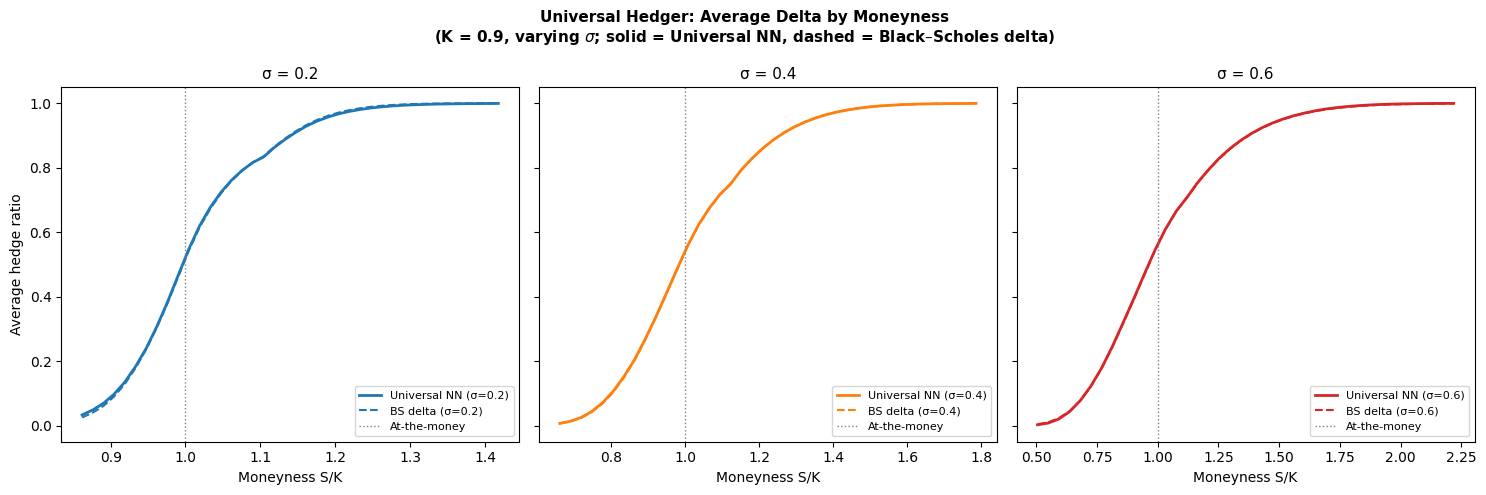

Saved universal_delta_by_moneyness.png


In [26]:
# ============================================================
# 11f. Universal Hedger — Average Delta by Moneyness
#      across volatility scenarios
# ============================================================

def binned_delta_universal(paths, K_val, sigma_val, n_bins=40):
    """
    Evaluate universal hedger delta and BS delta on paths
    simulated at fixed (K_val, sigma_val), then bin by moneyness.
    """
    rng_s   = np.random.default_rng(888)
    n_paths = 30_000
    K_arr   = np.full(n_paths, K_val,    dtype=np.float32)
    sig_arr = np.full(n_paths, sigma_val, dtype=np.float32)

    paths_s  = simulate_universal_paths(
        n_paths, cfg.N, cfg.T, cfg.S0, cfg.r,
        K_arr, sig_arr, rng_s)
    payoff_s = make_payoff(paths_s, K_arr)
    prem_s   = bs_price_scenario(K_arr, sig_arr)

    # Universal NN deltas
    feat_s   = make_features_universal(
        paths_s, K_arr, sig_arr, cfg.N, cfg.T)
    _, deltas_nn = univ_model(
        (tf.constant(feat_s),
         tf.constant(paths_s),
         tf.constant(payoff_s),
         tf.constant(prem_s)),
        training=False,
    )
    deltas_nn = deltas_nn.numpy()

    # BS delta
    dt_e   = cfg.T / cfg.N
    tau_g  = cfg.T - np.arange(cfg.N)*dt_e
    S_s    = paths_s[:, :-1].astype(np.float64)
    tau_2d = np.maximum(tau_g[None, :], 1e-12)
    deltas_bs = bs_delta_scenario(S_s, tau_2d, K_val, sigma_val)

    # Bin by moneyness S/K
    moneyness    = (paths_s[:, :-1] / K_val).reshape(-1)
    delta_nn_flat = deltas_nn.reshape(-1)
    delta_bs_flat = deltas_bs.reshape(-1)

    bins    = np.linspace(
        np.quantile(moneyness, 0.01),
        np.quantile(moneyness, 0.99),
        n_bins + 1
    )
    centers = 0.5*(bins[:-1] + bins[1:])

    mean_nn, mean_bs = [], []
    for i in range(n_bins):
        mask = (moneyness >= bins[i]) & (moneyness < bins[i+1])
        mean_nn.append(np.mean(delta_nn_flat[mask]) if mask.any() else np.nan)
        mean_bs.append(np.mean(delta_bs_flat[mask]) if mask.any() else np.nan)

    return centers, np.array(mean_nn), np.array(mean_bs)


# ── Plot: one panel per sigma, overlay NN and BS ──
sigma_vals  = [0.2, 0.4, 0.6]
K_val_plot  = 0.9   # fix K at training centre

colours_nn = ["#1f77b4", "#ff7f0e", "#d62728"]
colours_bs = ["#aec7e8", "#ffbb78", "#f7b6a2"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle(
    "Universal Hedger: Average Delta by Moneyness\n"
    f"(K = {K_val_plot}, varying $\\sigma$; "
    "solid = Universal NN, dashed = Black–Scholes delta)",
    fontweight="bold", fontsize=11,
)

for ax, sigma_val, c_nn, c_bs in zip(
        axes, sigma_vals, colours_nn, colours_bs):
    centers, mean_nn, mean_bs = binned_delta_universal(
        None, K_val_plot, sigma_val)
    ax.plot(centers, mean_nn, color=c_nn, lw=2.0,
            label=f"Universal NN (σ={sigma_val})")
    ax.plot(centers, mean_bs, color=c_nn, lw=1.5,
            ls="--", label=f"BS delta (σ={sigma_val})")
    ax.axvline(1.0, color="grey", lw=1.0, ls=":",
               label="At-the-money")
    ax.set_xlabel("Moneyness S/K", fontsize=10)
    ax.set_title(f"σ = {sigma_val}", fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel("Average hedge ratio", fontsize=10)
plt.tight_layout()
fig.savefig(out_dir/"universal_delta_by_moneyness.png",
            dpi=180, bbox_inches="tight")
plt.show()
print("Saved universal_delta_by_moneyness.png")

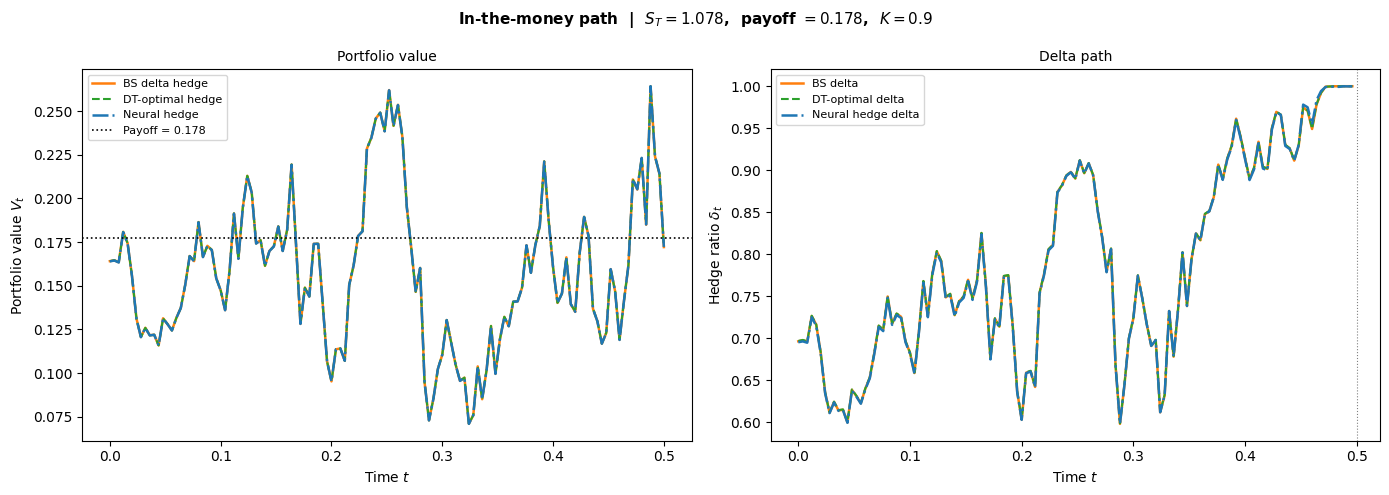

Saved final_benchmark_outputs/pathwise_itm.png


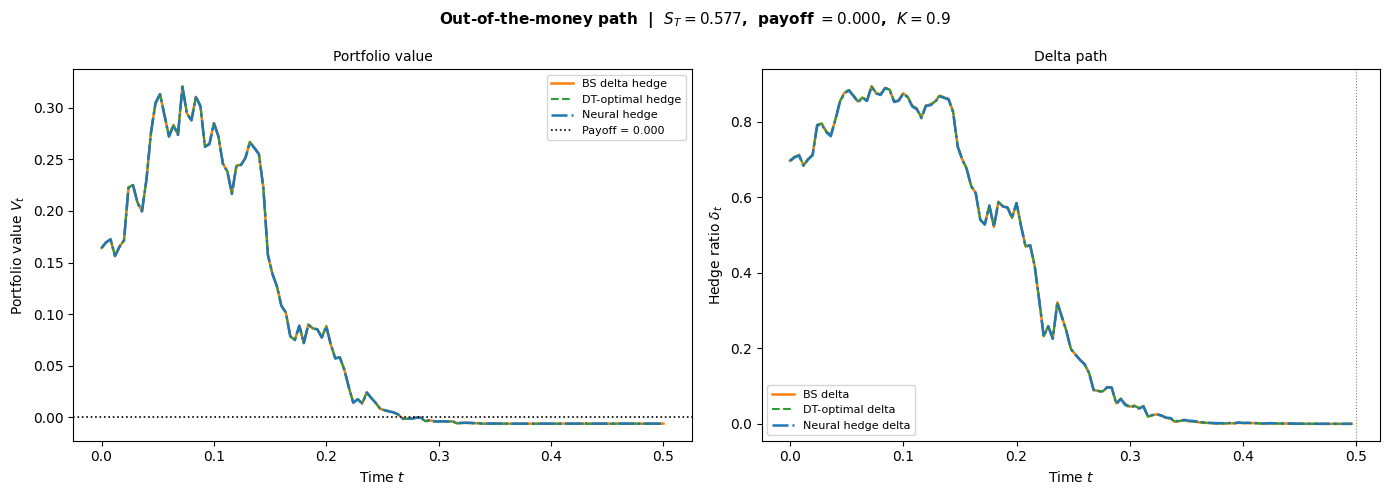

Saved final_benchmark_outputs/pathwise_otm.png


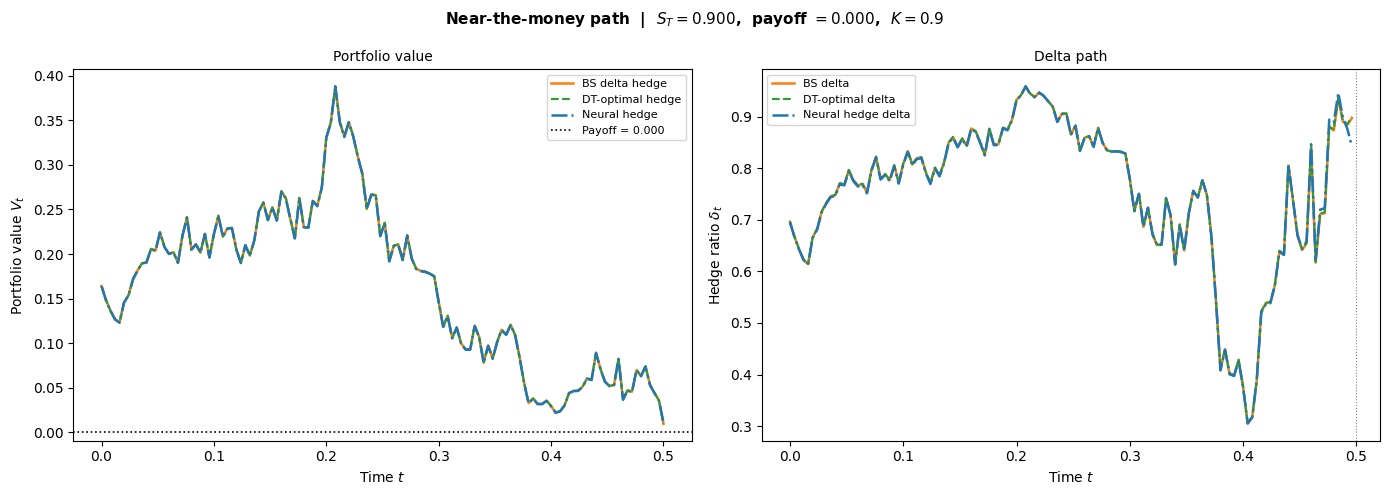

Saved final_benchmark_outputs/pathwise_atm.png


In [27]:
# ============================================================
# 11g. Pathwise hedge portfolio plots
# ============================================================

def plot_pathwise_hedge(paths_test, deltas_bs, deltas_dt, deltas_nn,
                        cfg, bs_price_0, nn_premium, out_dir,
                        n_paths_show=3):
    """
    Plot portfolio value over time for selected paths:
    - One ITM path (S_T > K)
    - One OTM path (S_T < K)
    - One near-the-money path (S_T closest to K)
    """
    ST      = paths_test[:, -1]
    payoffs = np.maximum(ST - cfg.K, 0.0)

    # Select representative paths
    itm_idx  = int(np.where(ST > cfg.K * 1.1)[0][0])
    otm_idx  = int(np.where(ST < cfg.K * 0.9)[0][0])
    atm_idx  = int(np.argmin(np.abs(ST - cfg.K)))

    choices  = [
        (itm_idx,  "In-the-money",      "itm"),
        (otm_idx,  "Out-of-the-money",  "otm"),
        (atm_idx,  "Near-the-money",    "atm"),
    ]

    dt_eval = cfg.T / cfg.N
    times   = np.linspace(0, cfg.T, cfg.N + 1)

    for idx, label, tag in choices:
        path    = paths_test[idx]
        payoff  = float(payoffs[idx])
        dS      = np.diff(path)

        # Portfolio values for each strategy
        def portfolio_value(premium, deltas_path):
            V    = np.empty(cfg.N + 1)
            V[0] = premium
            for n in range(cfg.N):
                V[n+1] = V[n] + deltas_path[n] * dS[n]
            return V

        V_bs  = portfolio_value(bs_price_0,  deltas_bs[idx])
        V_dt  = portfolio_value(bs_price_0,  deltas_dt[idx])
        V_nn  = portfolio_value(nn_premium,  deltas_nn[idx])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(
            f"{label} path  |  "
            f"$S_T = {path[-1]:.3f}$,  payoff $= {payoff:.3f}$,  "
            f"$K = {cfg.K}$",
            fontweight="bold", fontsize=11,
        )

        # ── Left panel: portfolio value ──
        ax = axes[0]
        ax.plot(times, V_bs,  color="#ff7f0e", lw=1.8,
                label="BS delta hedge")
        ax.plot(times, V_dt,  color="#2ca02c", lw=1.5,
                ls="--", label="DT-optimal hedge")
        ax.plot(times, V_nn,  color="#1f77b4", lw=1.8,
                ls="-.", label="Neural hedge")
        ax.axhline(payoff, color="black", lw=1.2,
                   ls=":", label=f"Payoff = {payoff:.3f}")
        ax.set_xlabel("Time $t$", fontsize=10)
        ax.set_ylabel("Portfolio value $V_t$", fontsize=10)
        ax.set_title("Portfolio value", fontsize=10)
        ax.legend(fontsize=8)

        # ── Right panel: delta paths ──
        ax = axes[1]
        ax.plot(times[:-1], deltas_bs[idx], color="#ff7f0e",
                lw=1.8, label="BS delta")
        ax.plot(times[:-1], deltas_dt[idx], color="#2ca02c",
                lw=1.5, ls="--", label="DT-optimal delta")
        ax.plot(times[:-1], deltas_nn[idx], color="#1f77b4",
                lw=1.8, ls="-.", label="Neural hedge delta")
        ax.axvline(cfg.T, color="grey", lw=0.8, ls=":")
        ax.set_xlabel("Time $t$", fontsize=10)
        ax.set_ylabel("Hedge ratio $\\delta_t$", fontsize=10)
        ax.set_title("Delta path", fontsize=10)
        ax.legend(fontsize=8)

        plt.tight_layout()
        fname = out_dir / f"pathwise_{tag}.png"
        fig.savefig(fname, dpi=180, bbox_inches="tight")
        plt.show()
        print(f"Saved {fname}")


# ── Run ──
nn_premium = float(nn_model.premium.numpy())

plot_pathwise_hedge(
    paths_test  = paths_test,
    deltas_bs   = deltas_bs,
    deltas_dt   = deltas_dt,
    deltas_nn   = deltas_nn,
    cfg         = cfg,
    bs_price_0  = bs_price_0,
    nn_premium  = nn_premium,
    out_dir     = out_dir,
)

**EXTENSION**


In [28]:
# ============================================================
# Evaluation: interpolation grid + extrapolation grid + CVaR95
# ============================================================

def loss_var_cvar(he, alpha=0.95):
    """
    Loss VaR/CVaR at confidence alpha, using the same sign convention
    as the rest of the paper: L = -HE (seller loss).
    """
    loss = -np.asarray(he)
    var_a = float(np.quantile(loss, alpha))
    cvar_a = float(np.mean(loss[loss >= var_a]))
    return var_a, cvar_a


def evaluate_universal_scenario(K_val, sigma_val, cfg, univ_model,
                                 n_test=UNIV_N_TEST, seed=999):
    """
    Evaluate BS delta, DT-optimal, and the trained universal NN
    at a single (K, sigma) scenario. Works identically whether the
    scenario is inside or outside the training distribution — the
    network is never retrained here.
    """
    rng_s   = np.random.default_rng(seed)
    K_arr   = np.full(n_test, K_val,    dtype=np.float32)
    sig_arr = np.full(n_test, sigma_val, dtype=np.float32)

    paths_s  = simulate_universal_paths(
        n_test, cfg.N, cfg.T, cfg.S0, cfg.r, K_arr, sig_arr, rng_s)
    payoff_s = make_payoff(paths_s, K_arr)
    prem_s   = bs_price_scenario(K_arr, sig_arr)
    dS_s     = paths_s[:, 1:] - paths_s[:, :-1]

    S_s    = paths_s[:, :-1].astype(np.float64)
    tau_2d = np.maximum(tau_g[None, :], 1e-12)

    # BS delta
    d_bs  = bs_delta_scenario(S_s, tau_2d, K_val, sigma_val)
    he_bs = prem_s + np.sum(d_bs * dS_s, axis=1) - payoff_s

    # DT-optimal (closed form)
    d_dt  = dt_optimal_delta_scenario(
        S_s, tau_2d, K_val, sigma_val, cfg.T, cfg.N)
    he_dt = prem_s + np.sum(d_dt * dS_s, axis=1) - payoff_s

    # Universal NN
    feat_s   = make_features_universal(paths_s, K_arr, sig_arr, cfg.N, cfg.T)
    he_nn_tf, _ = univ_model(
        (tf.constant(feat_s), tf.constant(paths_s),
         tf.constant(payoff_s), tf.constant(prem_s)),
        training=False,
    )
    he_nn = he_nn_tf.numpy()

    rmse_bs = float(np.sqrt(np.mean(he_bs**2)))
    rmse_dt = float(np.sqrt(np.mean(he_dt**2)))
    rmse_nn = float(np.sqrt(np.mean(he_nn**2)))

    var95_nn, cvar95_nn = loss_var_cvar(he_nn, 0.95)
    var95_bs, cvar95_bs = loss_var_cvar(he_bs, 0.95)

    return {
        "BS Delta RMSE": rmse_bs, "DT-Optimal RMSE": rmse_dt,
        "Universal NN RMSE": rmse_nn,
        "BS Loss VaR95": var95_bs, "BS Loss CVaR95": cvar95_bs,
        "NN Loss VaR95": var95_nn, "NN Loss CVaR95": cvar95_nn,
    }


dt_eval = cfg.T / cfg.N
tau_g   = cfg.T - np.arange(cfg.N) * dt_eval

# ── Interpolation grid: inside / on the boundary of the training range ──
interp_points = [(K, s) for K in [0.7, 0.9, 1.1] for s in [0.2, 0.4, 0.6]]

# ── Extrapolation grid: outside K~U(0.7,1.1), sigma~U(0.2,0.6) ──
extrap_points = [
    (0.6, 0.4),   # K below range, sigma at centre
    (1.3, 0.4),   # K above range, sigma at centre
    (0.9, 0.1),   # sigma below range, K at centre
    (0.9, 0.8),   # sigma above range, K at centre
    (0.6, 0.1),   # double extrapolation (both low)
    (1.3, 0.8),   # double extrapolation (both high)
]

print("Evaluating interpolation grid...")
rows = []
for K_val, sigma_val in interp_points:
    m = evaluate_universal_scenario(K_val, sigma_val, cfg, univ_model)
    marker = " ★" if (K_val == 0.9 and sigma_val == 0.4) else ""
    rows.append({"K": f"{K_val}{marker}", "σ": f"{sigma_val}{marker}",
                 "Region": "Interpolation", **m})
    print(f"  K={K_val}, σ={sigma_val}: NN RMSE={m['Universal NN RMSE']:.6f}, "
          f"NN CVaR95={m['NN Loss CVaR95']:.6f}")

print("\nEvaluating extrapolation grid...")
for K_val, sigma_val in extrap_points:
    m = evaluate_universal_scenario(K_val, sigma_val, cfg, univ_model)
    rows.append({"K": f"{K_val}", "σ": f"{sigma_val}",
                 "Region": "Extrapolation", **m})
    print(f"  K={K_val}, σ={sigma_val}: NN RMSE={m['Universal NN RMSE']:.6f}, "
          f"NN CVaR95={m['NN Loss CVaR95']:.6f}")

univ_df = pd.DataFrame(rows)

display_cols = ["K", "σ", "Region", "BS Delta RMSE", "DT-Optimal RMSE",
                 "Universal NN RMSE", "NN Loss VaR95", "NN Loss CVaR95"]
univ_df_display = univ_df[display_cols].round(6)

styled = (
    univ_df_display.style
    .set_caption(
        "Universal hedger robustness across K and σ, including extrapolation "
        "beyond the training distribution K~U(0.7,1.1), σ~U(0.2,0.6). "
        "★ = centre of training distribution. Premium fixed to BS price per path.")
    .set_properties(**{"text-align": "center"})
)
display(styled)

univ_df.to_csv(out_dir / "universal_robustness_with_extrapolation.csv", index=False)

latex_str = univ_df_display.to_latex(
    index=False, escape=False,
    caption=(
        r"Universal hedger performance across the trained $(K,\sigma)$ grid "
        r"(interpolation) and beyond it (extrapolation). The neural hedge is "
        r"evaluated without retraining in all rows. "
        r"$\star$ denotes the centre of the training distribution."
    ),
    label="tab:universal_robustness_extrap",
)
with open(out_dir / "universal_robustness_with_extrapolation.tex", "w") as f:
    f.write(latex_str)

print("\nSaved universal_robustness_with_extrapolation.csv/.tex")

Evaluating interpolation grid...


  K=0.7, σ=0.2: NN RMSE=0.000680, NN CVaR95=0.000940


  K=0.7, σ=0.4: NN RMSE=0.004133, NN CVaR95=0.010670


  K=0.7, σ=0.6: NN RMSE=0.008157, NN CVaR95=0.019765


  K=0.9, σ=0.2: NN RMSE=0.003492, NN CVaR95=0.008266


...

  K=0.9, σ=0.8: NN RMSE=0.016251, NN CVaR95=0.037599


  K=0.6, σ=0.1: NN RMSE=0.000026, NN CVaR95=0.000042


  K=1.3, σ=0.8: NN RMSE=0.020058, NN CVaR95=0.050729


,K,σ,Region,BS Delta RMSE,DT-Optimal RMSE,Universal NN RMSE,NN Loss VaR95,NN Loss CVaR95
0,0.7,0.2,Interpolation,0.000505,0.000506,0.000680,0.000547,0.000940
1,0.7,0.4,Interpolation,0.004117,0.004116,0.004133,0.006669,0.010670
2,0.7,0.6,Interpolation,0.008127,0.008123,0.008157,0.013690,0.019765
3,0.9,0.2,Interpolation,0.003405,0.003405,0.003492,0.005619,0.008266
4,0.9 ★,0.4 ★,Interpolation,0.007815,0.007813,0.007830,0.012784,0.018111
5,0.9,0.6,Interpolation,0.011864,0.011858,0.011891,0.019535,0.027288
6,1.1,0.2,Interpolation,0.004062,0.004061,0.004195,0.006387,0.009514
7,1.1,0.4,Interpolation,0.009048,0.009046,0.009071,0.014593,0.020978
8,1.1,0.6,Interpolation,0.013721,0.013715,0.013783,0.022424,0.032013
9,0.6,0.4,Extrapolation,0.002221,0.002220,0.002241,0.003089,0.006123



Saved universal_robustness_with_extrapolation.csv/.tex


DATA PATH GENERATION


Generating training datasets...

[1/3] Crude Monte Carlo...


  Shape: (100000, 126)

[2/3] Latin Hypercube Sampling...


  Shape: (100000, 126)

[3/3] Sobol + Brownian Bridge...


  Shape: (100000, 126)

All datasets generated in 4.0s

Sanity checks (mean S_T, should be ≈ 1.0 for r=0):
  Crude MC    : mean S_T=1.00028, var(log S_T)=0.08017 (theory=0.08000), MC call price=0.16434 (BS=0.16411)
  LHS         : mean S_T=1.00008, var(log S_T)=0.08020 (theory=0.08000), MC call price=0.16422 (BS=0.16411)
  Sobol+BB    : mean S_T=1.00000, var(log S_T)=0.07999 (theory=0.08000), MC call price=0.16411 (BS=0.16411)


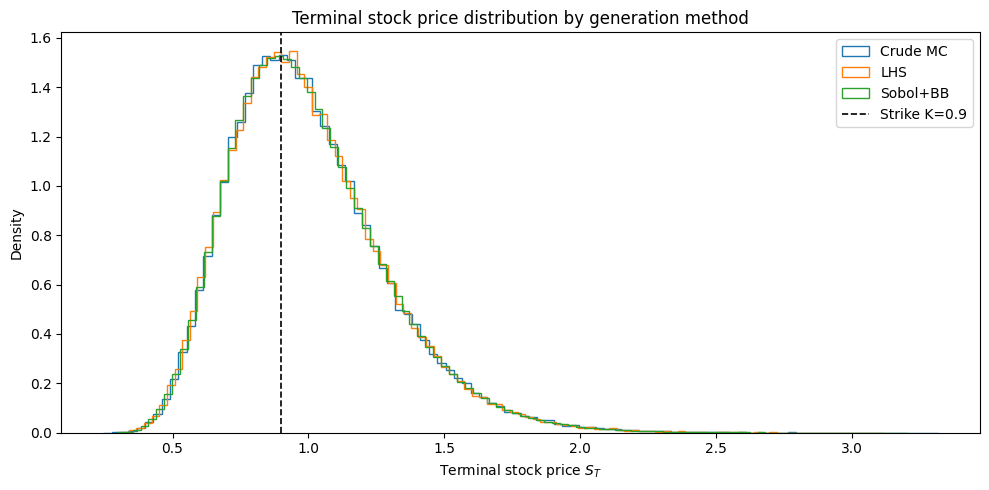

Saved terminal distribution comparison plot

Training models...

Training: Crude MC


  [Crude MC] Epoch 001 | train 4.1203e-03 | val 1.4205e-03


  [Crude MC] Epoch 010 | train 2.6766e-04 | val 2.6521e-04


  [Crude MC] Epoch 020 | train 1.2728e-04 | val 1.2198e-04


  [Crude MC] Epoch 030 | train 8.9055e-05 | val 8.9537e-05


...

  [Sobol+BB] Epoch 210 | train 6.2176e-05 | val 6.1904e-05


  [Sobol+BB] Epoch 220 | train 6.1643e-05 | val 6.2009e-05


  [Sobol+BB] Epoch 230 | train 6.2556e-05 | val 6.2156e-05


  [Sobol+BB] Epoch 240 | train 6.1969e-05 | val 6.1905e-05


  [Sobol+BB] Epoch 250 | train 6.1424e-05 | val 6.1548e-05

Results:
  Method     RMSE   CVaR95   CVaR99    HE q01    HE q05  RMSE OTM  RMSE ATM  RMSE ITM  Best val loss  Best epoch  Epochs run  Runtime (s)
Crude MC 0.007856 0.018175 0.026656 -0.021479 -0.012929  0.006408  0.011697  0.005803       0.000061         244         250         42.1
     LHS 0.007836 0.018075 0.026505 -0.021354 -0.012858  0.006455  0.011675  0.005775       0.000061         244         250         42.0
Sobol+BB 0.007844 0.018098 0.026598 -0.021367 -0.012839  0.006406  0.011693  0.005791       0.000062         250         250         42.2


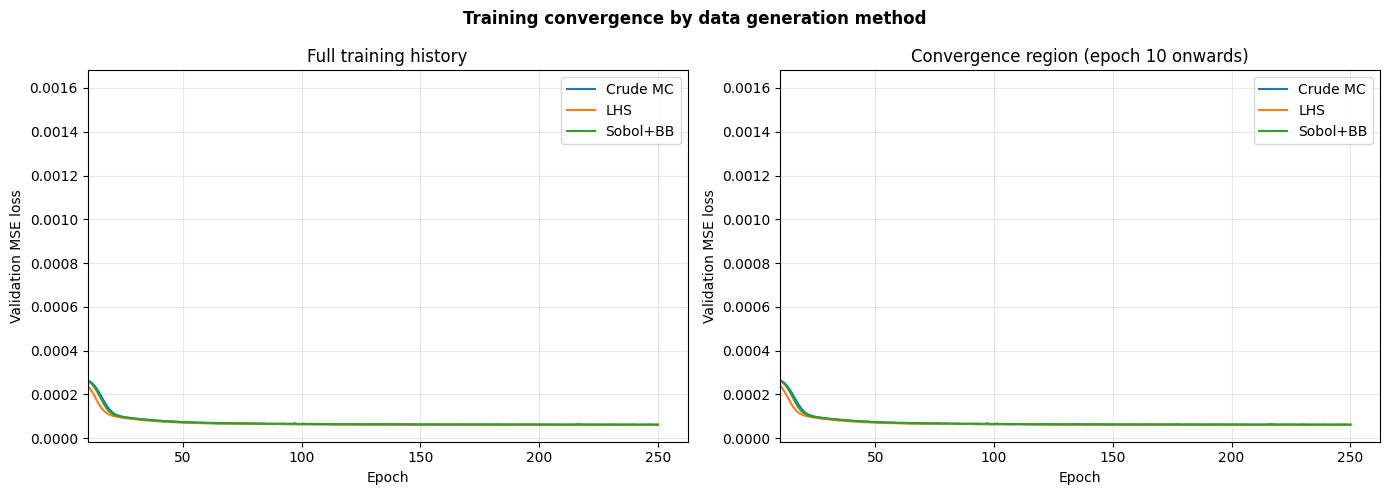

Saved learning curve plot


In [29]:
# ============================================================
# 12. Data Generation Method Comparison
#     Crude MC vs Latin Hypercube Sampling vs Sobol + Brownian Bridge
# ============================================================

from scipy.stats import qmc
from scipy.stats import norm as scipy_norm
import time

# ── Fixed evaluation set (same for all methods) ──
# Use the paths_test already generated in cell 3
# All methods evaluated on this same test set

# ── Configuration ──
N_COMPARE   = 100_000   # training paths for comparison
N_VAL_C     =  20_000   # validation paths
MAX_EPOCHS  = 250       # consistent with main paper
PATIENCE_C  = 20        # consistent with main paper
BATCH_C     = 4096
LR_C        = 1e-3
SEED_C      = 42

# ── Helper: build features and payoff from paths ──
def make_single_features(paths, cfg):
    """
    Features for single-scenario model: [log(S/K), tau/T]
    Shape: (M, N, 2)
    """
    dt       = cfg.T / cfg.N
    tau_norm = ((cfg.T - np.arange(cfg.N)*dt) / cfg.T).astype(np.float32)
    S_steps  = paths[:, :cfg.N]
    log_m    = np.log(np.maximum(S_steps, 1e-7) / cfg.K)
    tau_2d   = np.ones((len(paths), 1), dtype=np.float32) * tau_norm[None, :]
    return np.stack([log_m, tau_2d], axis=-1).astype(np.float32)


def make_single_payoff(paths, cfg):
    return np.maximum(paths[:, -1] - cfg.K, 0.0).astype(np.float32)


# ── Method 1: Crude Monte Carlo ──
def generate_crude_mc(n_paths, cfg, seed):
    """Standard i.i.d. GBM simulation."""
    rng = np.random.default_rng(seed)
    dt  = cfg.T / cfg.N
    Z   = rng.standard_normal((n_paths, cfg.N)).astype(np.float32)
    inc = (cfg.r - 0.5*cfg.sigma**2)*dt + cfg.sigma*np.sqrt(dt)*Z
    paths       = np.empty((n_paths, cfg.N+1), dtype=np.float32)
    paths[:, 0] = cfg.S0
    paths[:, 1:] = cfg.S0 * np.exp(np.cumsum(inc, axis=1))
    return paths


# ── Method 2: Latin Hypercube Sampling ──
def generate_lhs(n_paths, cfg, seed):
    """
    GBM path simulation using Latin Hypercube Sampling (LHS).

    LHS partitions each of the N input dimensions into n_paths
    equal-probability strata and draws exactly one sample per
    stratum, guaranteeing uniform marginal coverage across all
    dimensions simultaneously. This ensures the training
    distribution covers the full range of each Brownian
    increment more evenly than crude Monte Carlo.

    The uniform samples are transformed to standard normals
    via the inverse CDF before constructing GBM paths in
    the standard sequential manner.

    Reference: McKay, Beckman and Conover (1979).
    """
    sampler = qmc.LatinHypercube(d=cfg.N, seed=seed)
    U = sampler.random(n_paths)          # (n_paths, N) uniform samples
    U = np.clip(U, 1e-10, 1 - 1e-10)   # avoid infinite normal quantiles
    Z = scipy_norm.ppf(U).astype(np.float32)

    dt  = cfg.T / cfg.N
    inc = (cfg.r - 0.5*cfg.sigma**2)*dt + cfg.sigma*np.sqrt(dt)*Z
    paths        = np.empty((n_paths, cfg.N+1), dtype=np.float32)
    paths[:, 0]  = cfg.S0
    paths[:, 1:] = cfg.S0 * np.exp(np.cumsum(inc, axis=1))
    return paths


# ── Method 3: Sobol + Brownian Bridge ──
def generate_sobol_brownian_bridge(n_paths, cfg, seed):
    """
    QMC with Brownian bridge construction.

    Instead of simulating N increments sequentially
    (putting all variation in N dimensions), we use a
    Brownian bridge to fill in the path hierarchically:

    Step 1: Simulate W_T (terminal BM value) — dimension 1
    Step 2: Simulate W_{T/2} | W_T              — dimension 2
    Step 3: Simulate W_{T/4}, W_{3T/4}          — dimensions 3-4
    ...continue bisecting until all N points filled

    This concentrates the most important variation
    (terminal stock price, broad path shape) in the first
    few Sobol dimensions where low-discrepancy is strongest.
    High-frequency wiggles are pushed to later dimensions
    where they matter less for hedging.

    The effective QMC dimension is ceil(log2(N)) ≈ 7
    for N=125, rather than 125 for standard Sobol.

    References: Caflisch, Morokoff and Owen (1997);
                Glasserman (2004).
    """
    dt    = cfg.T / cfg.N
    times = np.arange(cfg.N + 1) * dt

    n_pow2  = int(2 ** np.ceil(np.log2(n_paths)))
    sampler = qmc.Sobol(d=cfg.N, scramble=True, seed=seed)
    U       = sampler.random(n_pow2)[:n_paths]
    U       = np.clip(U, 1e-10, 1 - 1e-10)
    Z_raw   = scipy_norm.ppf(U).astype(np.float64)

    # ── Brownian bridge construction ──
    W   = np.zeros((n_paths, cfg.N + 1), dtype=np.float64)
    dim = 0

    W[:, cfg.N] = np.sqrt(cfg.T) * Z_raw[:, dim]
    dim += 1

    from collections import deque
    queue = deque()
    queue.append((0, cfg.N))

    while queue and dim < cfg.N:
        l, r = queue.popleft()
        mid  = (l + r) // 2
        if mid == l or mid == r:
            continue

        t_l   = times[l]
        t_r   = times[r]
        t_mid = times[mid]

        alpha     = (t_mid - t_l) / (t_r - t_l)
        cond_mean = W[:, l] + alpha * (W[:, r] - W[:, l])
        cond_std  = np.sqrt((t_mid - t_l) * (t_r - t_mid) / (t_r - t_l))

        W[:, mid] = cond_mean + cond_std * Z_raw[:, dim]
        dim += 1

        queue.append((l, mid))
        queue.append((mid, r))

    for i in range(1, cfg.N):
        if W[:, i].sum() == 0 and i not in [0, cfg.N]:
            l = i - 1
            r = i + 1
            while r < cfg.N and W[:, r].sum() == 0:
                r += 1
            for j in range(l+1, r):
                alpha   = (j - l) / (r - l)
                W[:, j] = W[:, l] + alpha * (W[:, r] - W[:, l])

    dW    = np.diff(W, axis=1).astype(np.float32)
    drift = (cfg.r - 0.5 * cfg.sigma**2) * dt
    inc   = drift + cfg.sigma * dW

    paths        = np.empty((n_paths, cfg.N+1), dtype=np.float32)
    paths[:, 0]  = cfg.S0
    paths[:, 1:] = cfg.S0 * np.exp(np.cumsum(inc, axis=1))
    return paths


# ── Single-scenario model for comparison ──
class SingleScenarioHedge(tf.keras.Model):
    """
    Identical architecture to main benchmark model.
    64x3 tanh/sigmoid shared Markov MLP.
    Premium fixed to BS price for clean comparison
    across data generation methods.
    """
    def __init__(self, cfg, initial_premium):
        super().__init__()
        self.N       = cfg.N
        self.premium = tf.constant(initial_premium, dtype=tf.float32)
        layers_list  = []
        for _ in range(cfg.depth):
            layers_list.append(
                tf.keras.layers.Dense(cfg.width, activation=cfg.hidden_activation))
        layers_list.append(
            tf.keras.layers.Dense(1, activation=cfg.output_activation))
        self.net = tf.keras.Sequential(layers_list)

    def call(self, inputs, training=False):
        feat, paths, payoff = inputs
        batch   = tf.shape(feat)[0]
        flat    = tf.reshape(feat, (-1, 2))
        deltas  = tf.reshape(
            self.net(flat, training=training)[:, 0],
            (batch, self.N))
        dS = paths[:, 1:] - paths[:, :self.N]
        VT = self.premium + tf.reduce_sum(deltas * dS, axis=1)
        return VT - payoff, deltas


def train_comparison_model(paths_train, paths_val, cfg,
                           label, seed, fixed_epochs=MAX_EPOCHS):
    """
    Train single-scenario model on given paths.
    Returns hedge errors on fixed test set and training history.
    """
    tf.random.set_seed(seed)
    np.random.seed(seed)

    feat_tr  = make_single_features(paths_train, cfg)
    feat_vl  = make_single_features(paths_val,   cfg)
    feat_te  = make_single_features(paths_test,   cfg)

    pay_tr   = make_single_payoff(paths_train, cfg)
    pay_vl   = make_single_payoff(paths_val,   cfg)
    pay_te   = make_single_payoff(paths_test,  cfg)

    feat_tr_tf = tf.constant(feat_tr)
    path_tr_tf = tf.constant(paths_train)
    pay_tr_tf  = tf.constant(pay_tr)

    feat_vl_tf = tf.constant(feat_vl)
    path_vl_tf = tf.constant(paths_val)
    pay_vl_tf  = tf.constant(pay_vl)

    feat_te_tf = tf.constant(feat_te)
    path_te_tf = tf.constant(paths_test)
    pay_te_tf  = tf.constant(pay_te)

    model = SingleScenarioHedge(cfg, bs_price_0)
    opt   = tf.keras.optimizers.Adam(LR_C)

    @tf.function
    def train_step(f, p, pay):
        with tf.GradientTape() as tape:
            he, _ = model((f, p, pay), training=True)
            loss  = tf.reduce_mean(tf.square(he))
        grads = tape.gradient(loss, model.trainable_variables)
        opt.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    @tf.function
    def eval_step(f, p, pay):
        he, _ = model((f, p, pay), training=False)
        return tf.reduce_sum(tf.square(he)), tf.shape(he)[0]

    best_val  = np.inf
    best_w    = None
    wait      = 0
    hist      = []
    t0        = time.time()
    n_tr      = len(paths_train)

    for epoch in range(1, fixed_epochs+1):
        idx          = np.random.permutation(n_tr)
        train_losses = []
        for start in range(0, n_tr, BATCH_C):
            b    = idx[start:start+BATCH_C]
            loss = train_step(
                tf.gather(feat_tr_tf, b),
                tf.gather(path_tr_tf, b),
                tf.gather(pay_tr_tf,  b),
            )
            train_losses.append(float(loss))

        sse, n   = eval_step(feat_vl_tf, path_vl_tf, pay_vl_tf)
        val_loss = float(sse) / int(n)
        tr_loss  = float(np.mean(train_losses))

        hist.append({
            "epoch":      epoch,
            "train_loss": tr_loss,
            "val_loss":   val_loss,
        })

        improved = val_loss < best_val - 1e-10
        if improved:
            best_val = val_loss
            best_w   = model.get_weights()
            wait     = 0
        else:
            wait += 1

        if epoch == 1 or epoch % 10 == 0:
            print(f"  [{label}] Epoch {epoch:03d} | "
                  f"train {tr_loss:.4e} | val {val_loss:.4e}")

        if wait >= PATIENCE_C:
            print(f"  [{label}] Early stopping at epoch {epoch}")
            break

    if best_w is not None:
        model.set_weights(best_w)

    runtime    = time.time() - t0
    epochs_run = len(hist)
    best_epoch = int(np.argmin([h["val_loss"] for h in hist])) + 1

    he_te, _ = model((feat_te_tf, path_te_tf, pay_te_tf), training=False)
    he_te    = he_te.numpy()

    return he_te, pd.DataFrame(hist), runtime, epochs_run, best_epoch, best_val


# ── Compute metrics including moneyness-specific RMSE ──
def comparison_metrics(he, label, runtime, epochs, best_epoch, best_val):
    loss = -he
    ST   = paths_test[:, -1]

    otm_mask = ST < cfg.K * 0.85
    itm_mask = ST > cfg.K * 1.15
    atm_mask = (ST >= cfg.K*0.95) & (ST <= cfg.K*1.05)

    def rmse(x):
        return float(np.sqrt(np.mean(x**2)))

    def cvar(loss_arr, q):
        v = np.percentile(loss_arr, q)
        return float(np.mean(loss_arr[loss_arr >= v]))

    return {
        "Method":        label,
        "RMSE":          round(rmse(he), 6),
        "CVaR95":        round(cvar(loss, 95), 6),
        "CVaR99":        round(cvar(loss, 99), 6),
        "HE q01":        round(float(np.percentile(he, 1)), 6),
        "HE q05":        round(float(np.percentile(he, 5)), 6),
        "RMSE OTM":      round(rmse(he[otm_mask]), 6) if otm_mask.any() else np.nan,
        "RMSE ATM":      round(rmse(he[atm_mask]), 6) if atm_mask.any() else np.nan,
        "RMSE ITM":      round(rmse(he[itm_mask]), 6) if itm_mask.any() else np.nan,
        "Best val loss": round(best_val, 8),
        "Best epoch":    best_epoch,
        "Epochs run":    epochs,
        "Runtime (s)":   round(runtime, 1),
    }


# ── Generate all training datasets ──
print("="*60)
print("Generating training datasets...")
print("="*60)

t_gen = time.time()

print("\n[1/3] Crude Monte Carlo...")
paths_tr_crude = generate_crude_mc(N_COMPARE, cfg, seed=SEED_C)
paths_vl_crude = generate_crude_mc(N_VAL_C,   cfg, seed=SEED_C+1)
print(f"  Shape: {paths_tr_crude.shape}")

print("\n[2/3] Latin Hypercube Sampling...")
paths_tr_lhs = generate_lhs(N_COMPARE, cfg, seed=SEED_C)
paths_vl_lhs = generate_lhs(N_VAL_C,   cfg, seed=SEED_C+1)
print(f"  Shape: {paths_tr_lhs.shape}")

print("\n[3/3] Sobol + Brownian Bridge...")
paths_tr_bb = generate_sobol_brownian_bridge(N_COMPARE, cfg, seed=SEED_C)
paths_vl_bb = generate_sobol_brownian_bridge(N_VAL_C,   cfg, seed=SEED_C+1)
print(f"  Shape: {paths_tr_bb.shape}")

print(f"\nAll datasets generated in {time.time()-t_gen:.1f}s")


# ── Sanity checks ──
print("\nSanity checks (mean S_T, should be ≈ 1.0 for r=0):")
for name, paths in [
    ("Crude MC",  paths_tr_crude),
    ("LHS",       paths_tr_lhs),
    ("Sobol+BB",  paths_tr_bb),
]:
    ST   = paths[:, -1]
    logR = np.log(ST / cfg.S0)
    print(f"  {name:12s}: mean S_T={np.mean(ST):.5f}, "
          f"var(log S_T)={np.var(logR):.5f} "
          f"(theory={cfg.sigma**2*cfg.T:.5f}), "
          f"MC call price={np.mean(np.maximum(ST-cfg.K,0)):.5f} "
          f"(BS={bs_price_0:.5f})")


# ── Quick visual check: terminal distribution comparison ──
fig, ax = plt.subplots(figsize=(10, 5))
for name, paths, colour in [
    ("Crude MC",  paths_tr_crude, "#1f77b4"),
    ("LHS",       paths_tr_lhs,   "#ff7f0e"),
    ("Sobol+BB",  paths_tr_bb,    "#2ca02c"),
]:
    ax.hist(paths[:, -1], bins=100, density=True, histtype="step",
            lw=1.8, color=colour, label=name)
ax.axvline(cfg.K, color="black", lw=1.2, ls="--", label=f"Strike K={cfg.K}")
ax.set_xlabel("Terminal stock price $S_T$")
ax.set_ylabel("Density")
ax.set_title("Terminal stock price distribution by generation method")
ax.legend()
plt.tight_layout()
fig.savefig(out_dir/"data_generation_ST_distributions.png", dpi=180)
plt.show()
print("Saved terminal distribution comparison plot")


# ── Train models for all three methods ──
print("\n" + "="*60)
print("Training models...")
print("="*60)

results_compare = []
histories_compare = {}

for label, paths_tr, paths_vl in [
    ("Crude MC",  paths_tr_crude, paths_vl_crude),
    ("LHS",       paths_tr_lhs,   paths_vl_lhs),
    ("Sobol+BB",  paths_tr_bb,    paths_vl_bb),
]:
    print(f"\nTraining: {label}")
    he, hist, runtime, epochs, best_ep, best_val = train_comparison_model(
        paths_tr, paths_vl, cfg, label, seed=SEED_C
    )
    results_compare.append(
        comparison_metrics(he, label, runtime, epochs, best_ep, best_val)
    )
    histories_compare[label] = hist

results_df_compare = pd.DataFrame(results_compare)
print("\n" + "="*60)
print("Results:")
print("="*60)
print(results_df_compare.to_string(index=False))
results_df_compare.to_csv(out_dir/"data_generation_comparison.csv", index=False)


# ── Learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colours = {
    "Crude MC": "#1f77b4",
    "LHS":      "#ff7f0e",
    "Sobol+BB": "#2ca02c",
}

for name, hist in histories_compare.items():
    colour = colours[name]
    axes[0].plot(hist["epoch"], hist["val_loss"],
                 label=name, color=colour, lw=1.5)
    axes[1].plot(hist["epoch"], hist["val_loss"],
                 label=name, color=colour, lw=1.5)

axes[0].set_title("Full training history")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation MSE loss")

cutoff = min(10, max(h["epoch"].max() for h in histories_compare.values()))
for ax in axes:
    ax.set_xlim(left=cutoff)
axes[1].set_title(f"Convergence region (epoch {cutoff} onwards)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation MSE loss")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Training convergence by data generation method", fontweight="bold")
plt.tight_layout()
fig.savefig(out_dir/"data_generation_convergence.png", dpi=180)
plt.show()
print("Saved learning curve plot")

Training comparison: data generation methods
Fixed epochs: 250, Fixed test set: 100,000 paths

Training: Crude MC
----------------------------------------


  [Crude MC] Epoch 001 | train 5.6298e-03 | val 3.0773e-03


  [Crude MC] Epoch 010 | train 2.5811e-04 | val 2.5416e-04


  [Crude MC] Epoch 020 | train 1.1149e-04 | val 1.0908e-04


  [Crude MC] Epoch 030 | train 8.6052e-05 | val 8.6868e-05


...

  [Sobol+BB] Epoch 220 | train 6.1486e-05 | val 6.1714e-05


  [Sobol+BB] Epoch 230 | train 6.2297e-05 | val 6.1571e-05


  [Sobol+BB] Epoch 240 | train 6.1855e-05 | val 6.2796e-05


  [Sobol+BB] Epoch 250 | train 6.1395e-05 | val 6.1465e-05
  Done. RMSE=0.007839, CVaR95=0.018121, Runtime=42.1s


,Method,RMSE,CVaR95,CVaR99,HE q01,HE q05,RMSE OTM,RMSE ATM,RMSE ITM,Best val loss,Best epoch,Epochs run,Runtime (s)
0,Crude MC,0.007844,0.018277,0.026780,-0.021517,-0.012993,0.006422,0.011643,0.005794,0.00006080,250,250,42.1
1,LHS,0.007849,0.018326,0.026829,-0.021617,-0.013031,0.006437,0.011645,0.005791,0.00006124,246,250,42.2
2,Sobol+BB,0.007839,0.018121,0.026623,-0.021365,-0.012872,0.006438,0.011679,0.005775,0.00006147,250,250,42.1


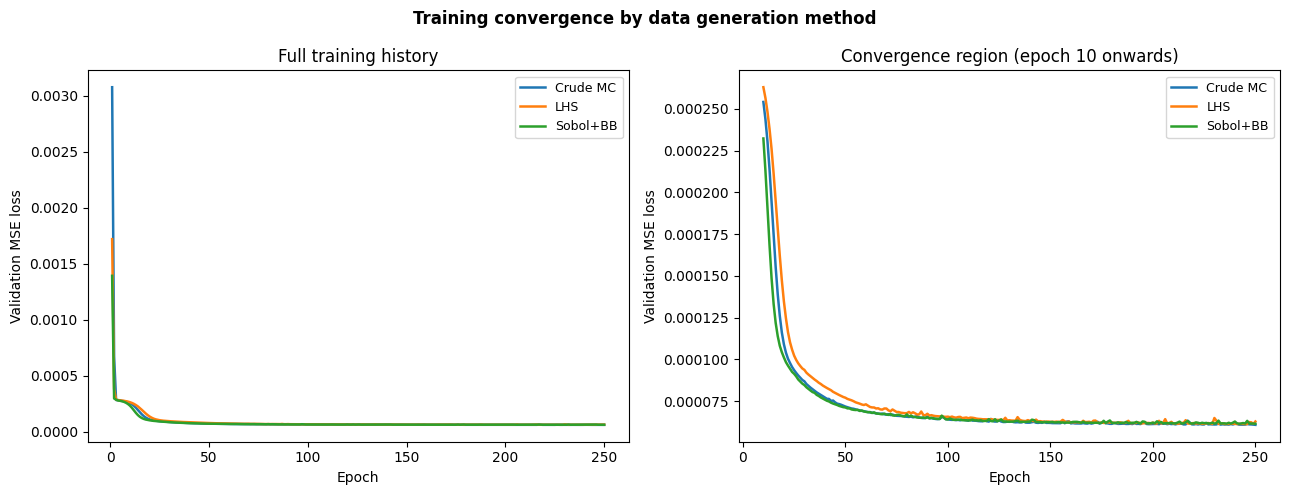


Saved data_generation_comparison.csv, .tex, and learning curves


In [30]:
# ============================================================
# 12b. Training comparison across data generation methods
# ============================================================

print("="*60)
print("Training comparison: data generation methods")
print(f"Fixed epochs: {MAX_EPOCHS}, Fixed test set: {len(paths_test):,} paths")
print("="*60)

comparison_results = []
comparison_histories = {}

methods = [
    ("Crude MC",  paths_tr_crude, paths_vl_crude),
    ("LHS",       paths_tr_lhs,   paths_vl_lhs),
    ("Sobol+BB",  paths_tr_bb,    paths_vl_bb),
]

for label, paths_tr, paths_vl in methods:
    print(f"\nTraining: {label}")
    print("-"*40)
    he_te, hist_df, runtime, epochs, best_epoch, best_val = \
        train_comparison_model(
            paths_tr, paths_vl, cfg,
            label=label,
            seed=SEED_C,
            fixed_epochs=MAX_EPOCHS,
        )
    metrics = comparison_metrics(
        he_te, label, runtime, epochs, best_epoch, best_val)
    comparison_results.append(metrics)
    comparison_histories[label] = hist_df
    print(f"  Done. RMSE={metrics['RMSE']:.6f}, "
          f"CVaR95={metrics['CVaR95']:.6f}, "
          f"Runtime={metrics['Runtime (s)']:.1f}s")

# ── Results table ──
comp_df = pd.DataFrame(comparison_results)
comp_df.to_csv(out_dir/"data_generation_comparison.csv", index=False)

# Display
styled = (
    comp_df.style
    .set_caption(
        "Data generation method comparison. All models trained with "
        f"{N_COMPARE:,} paths, {MAX_EPOCHS} epochs max, evaluated on "
        f"fixed test set of {len(paths_test):,} crude MC paths.")
    .format({
        "RMSE":          "{:.6f}",
        "CVaR95":        "{:.6f}",
        "CVaR99":        "{:.6f}",
        "HE q01":        "{:.6f}",
        "HE q05":        "{:.6f}",
        "RMSE OTM":      "{:.6f}",
        "RMSE ATM":      "{:.6f}",
        "RMSE ITM":      "{:.6f}",
        "Best val loss": "{:.8f}",
        "Runtime (s)":   "{:.1f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th",
         "props": [("font-weight", "bold"), ("text-align", "center")]},
    ])
    .highlight_min(
        subset=["RMSE", "CVaR95", "CVaR99", "RMSE OTM", "RMSE ATM", "RMSE ITM"],
        color="#d4edda",
    )
)
display(styled)

# ── LaTeX ──
latex_cols = [
    "Method", "RMSE", "CVaR95", "CVaR99",
    "HE q01", "RMSE OTM", "RMSE ATM", "RMSE ITM",
    "Best epoch", "Runtime (s)",
]
latex_str = comp_df[latex_cols].to_latex(
    index=False, escape=False,
    caption=(
        r"Comparison of data generation methods for neural hedge training. "
        r"All models use the 64$\times$3 tanh/sigmoid shared Markov MLP "
        r"trained for a maximum of " + str(MAX_EPOCHS) + r" epochs with "
        r"early stopping (patience=" + str(PATIENCE_C) + r") on "
        + f"{N_COMPARE:,}" + r" paths. "
        r"OTM: $S_T < 0.85K$; ATM: $0.95K \leq S_T \leq 1.05K$; "
        r"ITM: $S_T > 1.15K$. "
        r"All methods evaluated on the same fixed test set of "
        + f"{len(paths_test):,}" + r" crude Monte Carlo paths."
    ),
    label="tab:data_generation",
)
with open(out_dir/"data_generation_comparison.tex", "w") as f:
    f.write(latex_str)

# ── Learning curves comparison ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Training convergence by data generation method",
    fontweight="bold", fontsize=12,
)
colours = {
    "Crude MC":  "#1f77b4",
    "LHS":       "#ff7f0e",
    "Sobol+BB":  "#2ca02c",
}

# Left: full history
ax = axes[0]
for label, hist_df in comparison_histories.items():
    ax.plot(hist_df["epoch"], hist_df["val_loss"],
            color=colours[label], lw=1.8, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation MSE loss")
ax.set_title("Full training history")
ax.legend(fontsize=9)

# Right: zoom from epoch 10
ax = axes[1]
for label, hist_df in comparison_histories.items():
    tail = hist_df[hist_df["epoch"] >= 10]
    ax.plot(tail["epoch"], tail["val_loss"],
            color=colours[label], lw=1.8, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation MSE loss")
ax.set_title("Convergence region (epoch 10 onwards)")
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(out_dir/"data_generation_learning_curves.png",
            dpi=180, bbox_inches="tight")
plt.show()

print("\nSaved data_generation_comparison.csv, .tex, and learning curves")

Path count experiment: Crude MC vs LHS vs Sobol+BB
Max epochs: 250, Patience: 20

Training: Crude MC | n=10,000
----------------------------------------


  [Crude MC | n=10,000] Epoch 001 | train 9.6670e-03 | val 7.4842e-03


  [Crude MC | n=10,000] Epoch 010 | train 1.4099e-03 | val 1.2995e-03


  [Crude MC | n=10,000] Epoch 020 | train 2.9354e-04 | val 2.9345e-04


  [Crude MC | n=10,000] Epoch 030 | train 2.7740e-04 | val 2.8193e-04


...

  [Sobol+BB | n=100,000] Epoch 220 | train 6.1581e-05 | val 6.2023e-05


  [Sobol+BB | n=100,000] Epoch 230 | train 6.2516e-05 | val 6.2266e-05


  [Sobol+BB | n=100,000] Epoch 240 | train 6.1902e-05 | val 6.1842e-05


  [Sobol+BB | n=100,000] Epoch 250 | train 6.1440e-05 | val 6.1599e-05
  Done. RMSE=0.007845, CVaR95=0.018247, Runtime=43.2s

--- RMSE by path count and method ---
method_clean  Crude MC       LHS  Sobol+BB
n_paths                                   
10000         0.009316  0.009321  0.009233
25000         0.008264  0.008231  0.008240
50000         0.007955  0.007957  0.007943
100000        0.007850  0.007834  0.007845

--- CVaR95 by path count and method ---
method_clean  Crude MC       LHS  Sobol+BB
n_paths                                   
10000         0.021118  0.021101  0.020939
25000         0.019106  0.018868  0.018970
50000         0.018293  0.018300  0.018336
100000        0.018302  0.018267  0.018247

--- RMSE OTM by path count and method ---
method_clean  Crude MC       LHS  Sobol+BB
n_paths                                   
10000         0.007689  0.007802  0.007475
25000         0.006685  0.006652  0.006607
50000         0.006438  0.006455  0.006448
100000        0.00640

,Method,Paths,RMSE,CVaR95,RMSE OTM,RMSE ATM,RMSE ITM,Best epoch,Runtime (s)
0,Crude MC,10000,0.009316,0.021118,0.007689,0.014579,0.006744,250,8.4
1,LHS,10000,0.009321,0.021101,0.007802,0.014569,0.006691,250,8.2
2,Sobol+BB,10000,0.009233,0.020939,0.007475,0.014443,0.006751,250,8.1
3,Crude MC,25000,0.008264,0.019106,0.006685,0.012444,0.006017,246,14.1
4,LHS,25000,0.008231,0.018868,0.006652,0.012443,0.006006,250,14.1
5,Sobol+BB,25000,0.008240,0.018970,0.006607,0.012452,0.006002,247,14.1
6,Crude MC,50000,0.007955,0.018293,0.006438,0.011909,0.005823,249,23.4
7,LHS,50000,0.007957,0.018300,0.006455,0.011892,0.005844,250,23.4
8,Sobol+BB,50000,0.007943,0.018336,0.006448,0.011853,0.005827,250,23.4
9,Crude MC,100000,0.007850,0.018302,0.006406,0.011650,0.005805,247,42.1


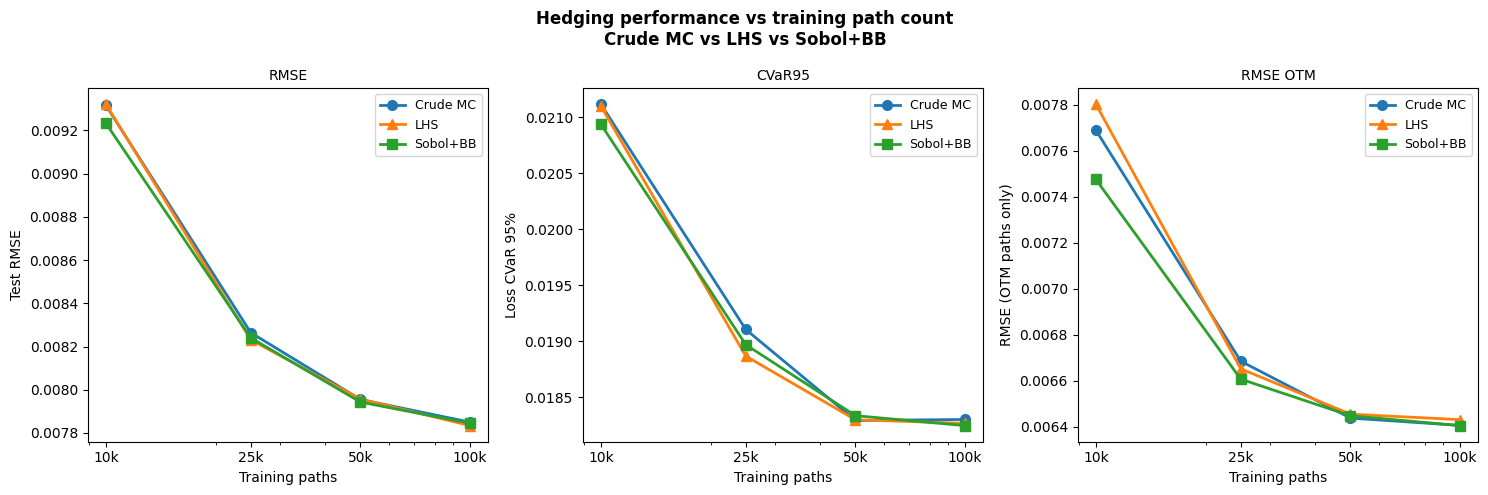

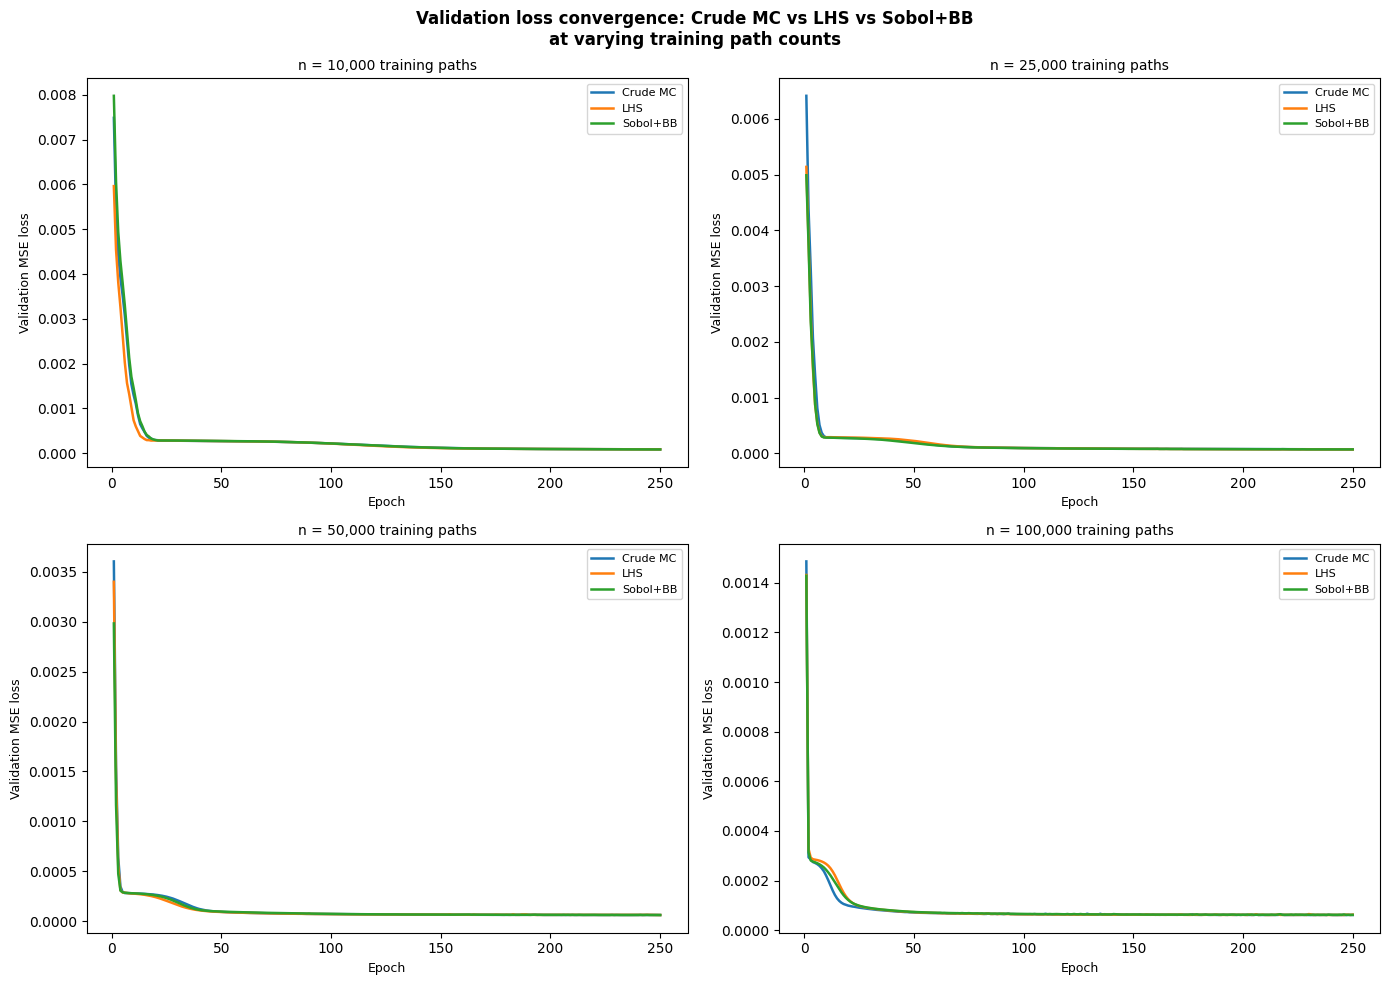


Saved path_count_comparison.csv, .tex, path_count_performance.png, path_count_learning_curves.png


In [31]:
# ============================================================
# 12c. Path count experiment
#      Crude MC vs LHS vs Sobol+BB at varying training set sizes
# ============================================================

PATH_COUNTS      = [10_000, 25_000, 50_000, 100_000]
FIXED_EPOCHS_PC  = MAX_EPOCHS   # consistent with main paper (250)
PATIENCE_PC      = PATIENCE_C   # consistent with main paper (20)
SEED_PC          = 42

print("="*60)
print("Path count experiment: Crude MC vs LHS vs Sobol+BB")
print(f"Max epochs: {FIXED_EPOCHS_PC}, Patience: {PATIENCE_PC}")
print("="*60)

path_count_results   = []
path_count_histories = {}

for n_paths in PATH_COUNTS:
    for method_label, gen_fn in [
        ("Crude MC",  generate_crude_mc),
        ("LHS",       generate_lhs),
        ("Sobol+BB",  generate_sobol_brownian_bridge),
    ]:
        label = f"{method_label} | n={n_paths:,}"
        print(f"\nTraining: {label}")
        print("-"*40)

        paths_tr = gen_fn(n_paths, cfg, seed=SEED_PC)
        paths_vl = gen_fn(N_VAL_C, cfg, seed=SEED_PC+1)

        he_te, hist_df, runtime, epochs, best_epoch, best_val = \
            train_comparison_model(
                paths_tr, paths_vl, cfg,
                label=label,
                seed=SEED_PC,
                fixed_epochs=FIXED_EPOCHS_PC,
            )

        metrics = comparison_metrics(
            he_te, label, runtime, epochs, best_epoch, best_val)
        metrics["n_paths"]      = n_paths
        metrics["method_clean"] = method_label
        path_count_results.append(metrics)
        path_count_histories[label] = hist_df

        print(f"  Done. RMSE={metrics['RMSE']:.6f}, "
              f"CVaR95={metrics['CVaR95']:.6f}, "
              f"Runtime={metrics['Runtime (s)']:.1f}s")

pc_df = pd.DataFrame(path_count_results)
pc_df.to_csv(out_dir/"path_count_comparison.csv", index=False)


# ── Display: pivot tables ──
print("\n--- RMSE by path count and method ---")
rmse_pivot = pc_df.pivot(
    index="n_paths", columns="method_clean", values="RMSE")
print(rmse_pivot.round(6).to_string())

print("\n--- CVaR95 by path count and method ---")
cvar_pivot = pc_df.pivot(
    index="n_paths", columns="method_clean", values="CVaR95")
print(cvar_pivot.round(6).to_string())

print("\n--- RMSE OTM by path count and method ---")
otm_pivot = pc_df.pivot(
    index="n_paths", columns="method_clean", values="RMSE OTM")
print(otm_pivot.round(6).to_string())


# ── Styled display table ──
display_cols = [
    "method_clean", "n_paths", "RMSE", "CVaR95",
    "RMSE OTM", "RMSE ATM", "RMSE ITM",
    "Best epoch", "Runtime (s)",
]
styled_pc = (
    pc_df[display_cols]
    .rename(columns={"method_clean": "Method", "n_paths": "Paths"})
    .style
    .set_caption(
        "Path count experiment: Crude MC vs LHS vs Sobol+BB. "
        f"Max {FIXED_EPOCHS_PC} epochs with early stopping "
        f"(patience={PATIENCE_PC}), evaluated on same "
        f"{len(paths_test):,}-path test set.")
    .format({
        "RMSE":        "{:.6f}",
        "CVaR95":      "{:.6f}",
        "RMSE OTM":    "{:.6f}",
        "RMSE ATM":    "{:.6f}",
        "RMSE ITM":    "{:.6f}",
        "Runtime (s)": "{:.1f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th",
         "props": [("font-weight", "bold"), ("text-align", "center")]},
    ])
    .highlight_min(
        subset=["RMSE", "CVaR95", "RMSE OTM", "RMSE ATM", "RMSE ITM"],
        color="#d4edda",
    )
)
display(styled_pc)


# ── LaTeX ──
latex_pc = pc_df[display_cols].rename(
    columns={"method_clean": "Method", "n_paths": "Paths"}
).to_latex(
    index=False, escape=False,
    caption=(
        r"Path count experiment: Crude Monte Carlo vs Latin Hypercube "
        r"Sampling vs Sobol with Brownian bridge construction. "
        r"All models use the 64$\times$3 tanh/sigmoid shared Markov MLP "
        r"trained for a maximum of " + str(FIXED_EPOCHS_PC) + r" epochs "
        r"with early stopping (patience=" + str(PATIENCE_PC) + r"). "
        r"OTM: $S_T < 0.85K$; ATM: $0.95K \leq S_T \leq 1.05K$; "
        r"ITM: $S_T > 1.15K$. "
        r"All methods evaluated on the same fixed test set of "
        + f"{len(paths_test):,}" + r" crude Monte Carlo paths."
    ),
    label="tab:path_count",
)
with open(out_dir/"path_count_comparison.tex", "w") as f:
    f.write(latex_pc)


# ── Figure 1: performance metrics vs path count ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Hedging performance vs training path count\n"
    "Crude MC vs LHS vs Sobol+BB",
    fontweight="bold", fontsize=12,
)

colours = {
    "Crude MC":  "#1f77b4",
    "LHS":       "#ff7f0e",
    "Sobol+BB":  "#2ca02c",
}
markers = {
    "Crude MC":  "o",
    "LHS":       "^",
    "Sobol+BB":  "s",
}

metrics_plot = [
    ("RMSE",     "Test RMSE",             "RMSE"),
    ("CVaR95",   "Loss CVaR 95%",         "CVaR95"),
    ("RMSE OTM", "RMSE (OTM paths only)", "RMSE OTM"),
]

for ax, (col, ylabel, title) in zip(axes, metrics_plot):
    for method in ["Crude MC", "LHS", "Sobol+BB"]:
        sub = pc_df[pc_df["method_clean"] == method].sort_values("n_paths")
        ax.plot(sub["n_paths"], sub[col],
                color=colours[method], lw=2.0,
                marker=markers[method], markersize=7,
                label=method)
    ax.set_xlabel("Training paths", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_xscale("log")
    ax.set_xticks(PATH_COUNTS)
    ax.set_xticklabels([f"{n//1000}k" for n in PATH_COUNTS])
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(out_dir/"path_count_performance.png",
            dpi=180, bbox_inches="tight")
plt.show()


# ── Figure 2: learning curves at each path count ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Validation loss convergence: Crude MC vs LHS vs Sobol+BB\n"
    "at varying training path counts",
    fontweight="bold", fontsize=12,
)

for ax, n_paths in zip(axes.flat, PATH_COUNTS):
    for method in ["Crude MC", "LHS", "Sobol+BB"]:
        key  = f"{method} | n={n_paths:,}"
        hist = path_count_histories[key]
        ax.plot(hist["epoch"], hist["val_loss"],
                color=colours[method], lw=1.8, label=method)
    ax.set_title(f"n = {n_paths:,} training paths", fontsize=10)
    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel("Validation MSE loss", fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(out_dir/"path_count_learning_curves.png",
            dpi=180, bbox_inches="tight")
plt.show()

print("\nSaved path_count_comparison.csv, .tex, "
      "path_count_performance.png, path_count_learning_curves.png")

Generating training datasets...

[1/3] Crude Monte Carlo...


  Shape: (100000, 126)

[2/3] Scrambled Sobol...


  Shape: (100000, 126)

[3/3] Sobol + Brownian Bridge...


  Shape: (100000, 126)

All datasets generated in 3.5s

Sanity checks (mean S_T, should be ≈ 1.0 for r=0):
  Crude MC    : mean S_T=1.00028, var(log S_T)=0.08017 (theory=0.08000), MC call price=0.16434 (BS=0.16411)
  Sobol       : mean S_T=0.99996, var(log S_T)=0.07995 (theory=0.08000), MC call price=0.16395 (BS=0.16411)
  Sobol+BB    : mean S_T=1.00000, var(log S_T)=0.07999 (theory=0.08000), MC call price=0.16411 (BS=0.16411)


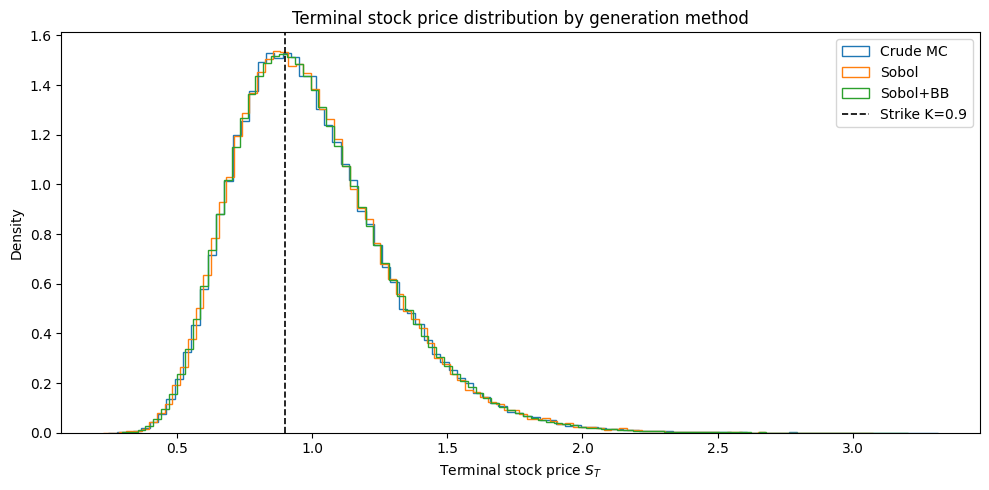

Saved terminal distribution comparison plot


In [32]:
# ============================================================
# 12. Data Generation Method Comparison
#     Crude MC vs Scrambled Sobol vs Sobol + Brownian Bridge
# ============================================================

from scipy.stats import qmc
import time

# ── Fixed evaluation set (same for all methods) ──
# Use the paths_test already generated in cell 3
# All methods evaluated on this same test set

# ── Configuration ──
N_COMPARE   = 100_000   # training paths for comparison
N_VAL_C     =  20_000   # validation paths
MAX_EPOCHS  = 100       # fixed epochs for fair comparison
PATIENCE_C  = 15
BATCH_C     = 4096
LR_C        = 1e-3
SEED_C      = 42

# ── Helper: build features and payoff from paths ──
def make_single_features(paths, cfg):
    """
    Features for single-scenario model: [log(S/K), tau/T]
    Shape: (M, N, 2)
    """
    dt       = cfg.T / cfg.N
    tau_norm = ((cfg.T - np.arange(cfg.N)*dt) / cfg.T).astype(np.float32)
    S_steps  = paths[:, :cfg.N]
    log_m    = np.log(np.maximum(S_steps, 1e-7) / cfg.K)
    tau_2d   = np.ones((len(paths), 1), dtype=np.float32) * tau_norm[None, :]
    return np.stack([log_m, tau_2d], axis=-1).astype(np.float32)


def make_single_payoff(paths, cfg):
    return np.maximum(paths[:, -1] - cfg.K, 0.0).astype(np.float32)


# ── Method 1: Crude Monte Carlo ──
def generate_crude_mc(n_paths, cfg, seed):
    """Standard i.i.d. GBM simulation."""
    rng = np.random.default_rng(seed)
    dt  = cfg.T / cfg.N
    Z   = rng.standard_normal((n_paths, cfg.N)).astype(np.float32)
    inc = (cfg.r - 0.5*cfg.sigma**2)*dt + cfg.sigma*np.sqrt(dt)*Z
    paths       = np.empty((n_paths, cfg.N+1), dtype=np.float32)
    paths[:, 0] = cfg.S0
    paths[:, 1:] = cfg.S0 * np.exp(np.cumsum(inc, axis=1))
    return paths


# ── Method 2: Scrambled Sobol ──
def generate_scrambled_sobol(n_paths, cfg, seed):
    """
    Quasi-Monte Carlo using scrambled Sobol sequences.

    Each path requires N standard normal draws. We generate
    an (n_paths x N) array of uniform samples from the Sobol
    sequence, then transform to standard normals via the
    inverse CDF (probability integral transform).

    Scrambling adds randomness to the deterministic Sobol
    sequence, preserving low-discrepancy properties while
    allowing error estimation and avoiding degeneracy.
    """
    from scipy.stats import norm as scipy_norm

    # Sobol engine: dimension = N (one draw per time step)
    sampler = qmc.Sobol(d=cfg.N, scramble=True, seed=seed)

    # n_paths must be a power of 2 for optimal Sobol properties
    # Round up to nearest power of 2
    n_pow2  = int(2 ** np.ceil(np.log2(n_paths)))
    U       = sampler.random(n_pow2)[:n_paths]  # (n_paths, N)

    # Clip to avoid infinite normal quantiles at 0 and 1
    U = np.clip(U, 1e-10, 1 - 1e-10)

    # Transform uniform to standard normal
    Z   = scipy_norm.ppf(U).astype(np.float32)
    dt  = cfg.T / cfg.N
    inc = (cfg.r - 0.5*cfg.sigma**2)*dt + cfg.sigma*np.sqrt(dt)*Z
    paths       = np.empty((n_paths, cfg.N+1), dtype=np.float32)
    paths[:, 0] = cfg.S0
    paths[:, 1:] = cfg.S0 * np.exp(np.cumsum(inc, axis=1))
    return paths


# ── Method 3: Sobol + Brownian Bridge ──
def generate_sobol_brownian_bridge(n_paths, cfg, seed):
    """
    QMC with Brownian bridge construction.

    Instead of simulating N increments sequentially
    (putting all variation in N dimensions), we use a
    Brownian bridge to fill in the path hierarchically:

    Step 1: Simulate W_T (terminal BM value) — dimension 1
    Step 2: Simulate W_{T/2} | W_T              — dimension 2
    Step 3: Simulate W_{T/4}, W_{3T/4}          — dimensions 3-4
    ...continue bisecting until all N points filled

    This concentrates the most important variation
    (terminal stock price, broad path shape) in the first
    few Sobol dimensions where low-discrepancy is strongest.
    High-frequency wiggles are pushed to later dimensions
    where they matter less for hedging.

    The effective QMC dimension is ceil(log2(N)) ≈ 7
    for N=125, rather than 125 for standard Sobol.
    """
    from scipy.stats import norm as scipy_norm

    dt    = cfg.T / cfg.N
    times = np.arange(cfg.N + 1) * dt  # t_0, t_1, ..., t_N

    # Number of Sobol dimensions needed = N (one per grid point)
    # but we use them in bridge order so first dims matter most
    n_pow2  = int(2 ** np.ceil(np.log2(n_paths)))
    sampler = qmc.Sobol(d=cfg.N, scramble=True, seed=seed)
    U       = sampler.random(n_pow2)[:n_paths]
    U       = np.clip(U, 1e-10, 1 - 1e-10)
    Z_raw   = scipy_norm.ppf(U).astype(np.float64)  # (n_paths, N)

    # ── Brownian bridge construction ──
    # W[i] = Brownian motion at time times[i]
    W = np.zeros((n_paths, cfg.N + 1), dtype=np.float64)

    # Dimension counter: track which Sobol dimension we use next
    dim = 0

    # Step 1: terminal value W_T using first Sobol dimension
    W[:, cfg.N] = np.sqrt(cfg.T) * Z_raw[:, dim]
    dim += 1

    # Step 2: hierarchical bisection
    # We use a queue of intervals to fill
    # Each interval (l, r) means we need to fill W at the midpoint
    from collections import deque
    queue = deque()
    queue.append((0, cfg.N))

    while queue and dim < cfg.N:
        l, r = queue.popleft()
        mid  = (l + r) // 2
        if mid == l or mid == r:
            continue

        t_l   = times[l]
        t_r   = times[r]
        t_mid = times[mid]

        # Conditional distribution of W(t_mid) given W(t_l) and W(t_r)
        # Mean and variance from standard Brownian bridge formula:
        # E[W_mid | W_l, W_r] = W_l + (t_mid-t_l)/(t_r-t_l) * (W_r - W_l)
        # Var[W_mid | W_l, W_r] = (t_mid-t_l)*(t_r-t_mid)/(t_r-t_l)
        alpha     = (t_mid - t_l) / (t_r - t_l)
        cond_mean = W[:, l] + alpha * (W[:, r] - W[:, l])
        cond_std  = np.sqrt((t_mid - t_l) * (t_r - t_mid) / (t_r - t_l))

        W[:, mid] = cond_mean + cond_std * Z_raw[:, dim]
        dim += 1

        # Add sub-intervals to queue
        queue.append((l, mid))
        queue.append((mid, r))

    # Fill any remaining points by linear interpolation
    # (only needed if N is not a power of 2)
    for i in range(1, cfg.N):
        if W[:, i].sum() == 0 and i not in [0, cfg.N]:
            l = i - 1
            r = i + 1
            while r < cfg.N and W[:, r].sum() == 0:
                r += 1
            for j in range(l+1, r):
                alpha    = (j - l) / (r - l)
                W[:, j]  = W[:, l] + alpha * (W[:, r] - W[:, l])

    # ── Convert BM to GBM paths ──
    # dW_n = W(t_{n+1}) - W(t_n)
    dW    = np.diff(W, axis=1).astype(np.float32)
    drift = (cfg.r - 0.5 * cfg.sigma**2) * dt
    inc   = drift + cfg.sigma * dW

    paths       = np.empty((n_paths, cfg.N+1), dtype=np.float32)
    paths[:, 0] = cfg.S0
    paths[:, 1:] = cfg.S0 * np.exp(np.cumsum(inc, axis=1))
    return paths


# ── Single-scenario model for comparison ──
class SingleScenarioHedge(tf.keras.Model):
    """
    Identical architecture to Notebook 2 nn_model.
    64x3 tanh/sigmoid shared Markov MLP.
    Premium fixed to BS price (not learned) for
    clean comparison across data generation methods.
    """
    def __init__(self, cfg, initial_premium):
        super().__init__()
        self.N       = cfg.N
        self.premium = tf.constant(initial_premium, dtype=tf.float32)
        layers_list  = []
        for _ in range(cfg.depth):
            layers_list.append(
                tf.keras.layers.Dense(cfg.width, activation=cfg.hidden_activation))
        layers_list.append(
            tf.keras.layers.Dense(1, activation=cfg.output_activation))
        self.net = tf.keras.Sequential(layers_list)

    def call(self, inputs, training=False):
        feat, paths, payoff = inputs
        batch   = tf.shape(feat)[0]
        flat    = tf.reshape(feat, (-1, 2))
        deltas  = tf.reshape(
            self.net(flat, training=training)[:, 0],
            (batch, self.N))
        dS = paths[:, 1:] - paths[:, :self.N]
        VT = self.premium + tf.reduce_sum(deltas * dS, axis=1)
        return VT - payoff, deltas


def train_comparison_model(paths_train, paths_val, cfg,
                           label, seed, fixed_epochs=MAX_EPOCHS):
    """
    Train single-scenario model on given paths.
    Returns hedge errors on fixed test set and training history.
    """
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Features
    feat_tr  = make_single_features(paths_train, cfg)
    feat_vl  = make_single_features(paths_val,   cfg)
    feat_te  = make_single_features(paths_test,   cfg)

    pay_tr   = make_single_payoff(paths_train, cfg)
    pay_vl   = make_single_payoff(paths_val,   cfg)
    pay_te   = make_single_payoff(paths_test,  cfg)

    # Convert to TF constants
    feat_tr_tf = tf.constant(feat_tr)
    path_tr_tf = tf.constant(paths_train)
    pay_tr_tf  = tf.constant(pay_tr)

    feat_vl_tf = tf.constant(feat_vl)
    path_vl_tf = tf.constant(paths_val)
    pay_vl_tf  = tf.constant(pay_vl)

    feat_te_tf = tf.constant(feat_te)
    path_te_tf = tf.constant(paths_test)
    pay_te_tf  = tf.constant(pay_te)

    model = SingleScenarioHedge(cfg, bs_price_0)
    opt   = tf.keras.optimizers.Adam(LR_C)

    @tf.function
    def train_step(f, p, pay):
        with tf.GradientTape() as tape:
            he, _ = model((f, p, pay), training=True)
            loss  = tf.reduce_mean(tf.square(he))
        grads = tape.gradient(loss, model.trainable_variables)
        opt.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    @tf.function
    def eval_step(f, p, pay):
        he, _ = model((f, p, pay), training=False)
        return tf.reduce_sum(tf.square(he)), tf.shape(he)[0]

    best_val  = np.inf
    best_w    = None
    wait      = 0
    hist      = []
    t0        = time.time()
    n_tr      = len(paths_train)

    for epoch in range(1, fixed_epochs+1):
        idx          = np.random.permutation(n_tr)
        train_losses = []
        for start in range(0, n_tr, BATCH_C):
            b    = idx[start:start+BATCH_C]
            loss = train_step(
                tf.gather(feat_tr_tf, b),
                tf.gather(path_tr_tf, b),
                tf.gather(pay_tr_tf,  b),
            )
            train_losses.append(float(loss))

        sse, n   = eval_step(feat_vl_tf, path_vl_tf, pay_vl_tf)
        val_loss = float(sse) / int(n)
        tr_loss  = float(np.mean(train_losses))

        hist.append({
            "epoch":      epoch,
            "train_loss": tr_loss,
            "val_loss":   val_loss,
        })

        improved = val_loss < best_val - 1e-10
        if improved:
            best_val = val_loss
            best_w   = model.get_weights()
            wait     = 0
        else:
            wait += 1

        if epoch == 1 or epoch % 10 == 0:
            print(f"  [{label}] Epoch {epoch:03d} | "
                  f"train {tr_loss:.4e} | val {val_loss:.4e}")

        if wait >= PATIENCE_C:
            print(f"  [{label}] Early stopping at epoch {epoch}")
            break

    if best_w is not None:
        model.set_weights(best_w)

    runtime = time.time() - t0
    epochs_run = len(hist)
    best_epoch = int(np.argmin([h["val_loss"] for h in hist])) + 1

    # Evaluate on fixed test set
    he_te, _ = model((feat_te_tf, path_te_tf, pay_te_tf), training=False)
    he_te    = he_te.numpy()

    return he_te, pd.DataFrame(hist), runtime, epochs_run, best_epoch, best_val


# ── Compute metrics including tail-specific RMSE ──
def comparison_metrics(he, label, runtime, epochs, best_epoch, best_val):
    loss = -he
    ST   = paths_test[:, -1]

    # Moneyness-specific masks
    otm_mask = ST < cfg.K * 0.85      # deep OTM
    itm_mask = ST > cfg.K * 1.15      # deep ITM
    atm_mask = (ST >= cfg.K*0.95) & (ST <= cfg.K*1.05)  # near ATM

    def rmse(x):
        return float(np.sqrt(np.mean(x**2)))

    def cvar(loss_arr, q):
        v = np.percentile(loss_arr, q)
        return float(np.mean(loss_arr[loss_arr >= v]))

    return {
        "Method":        label,
        "RMSE":          round(rmse(he), 6),
        "CVaR95":        round(cvar(loss, 95), 6),
        "CVaR99":        round(cvar(loss, 99), 6),
        "HE q01":        round(float(np.percentile(he, 1)), 6),
        "HE q05":        round(float(np.percentile(he, 5)), 6),
        "RMSE OTM":      round(rmse(he[otm_mask]), 6) if otm_mask.any() else np.nan,
        "RMSE ATM":      round(rmse(he[atm_mask]), 6) if atm_mask.any() else np.nan,
        "RMSE ITM":      round(rmse(he[itm_mask]), 6) if itm_mask.any() else np.nan,
        "Best val loss": round(best_val, 8),
        "Best epoch":    best_epoch,
        "Epochs run":    epochs,
        "Runtime (s)":   round(runtime, 1),
    }


# ── Generate all training datasets ──
print("="*60)
print("Generating training datasets...")
print("="*60)

t_gen = time.time()

print("\n[1/3] Crude Monte Carlo...")
paths_tr_crude = generate_crude_mc(N_COMPARE, cfg, seed=SEED_C)
paths_vl_crude = generate_crude_mc(N_VAL_C,   cfg, seed=SEED_C+1)
print(f"  Shape: {paths_tr_crude.shape}")

print("\n[2/3] Scrambled Sobol...")
paths_tr_sobol = generate_scrambled_sobol(N_COMPARE, cfg, seed=SEED_C)
paths_vl_sobol = generate_scrambled_sobol(N_VAL_C,   cfg, seed=SEED_C+1)
print(f"  Shape: {paths_tr_sobol.shape}")

print("\n[3/3] Sobol + Brownian Bridge...")
paths_tr_bb = generate_sobol_brownian_bridge(N_COMPARE, cfg, seed=SEED_C)
paths_vl_bb = generate_sobol_brownian_bridge(N_VAL_C,   cfg, seed=SEED_C+1)
print(f"  Shape: {paths_tr_bb.shape}")

print(f"\nAll datasets generated in {time.time()-t_gen:.1f}s")


# ── Sanity checks ──
print("\nSanity checks (mean S_T, should be ≈ 1.0 for r=0):")
for name, paths in [
    ("Crude MC",  paths_tr_crude),
    ("Sobol",     paths_tr_sobol),
    ("Sobol+BB",  paths_tr_bb),
]:
    ST   = paths[:, -1]
    logR = np.log(ST / cfg.S0)
    print(f"  {name:12s}: mean S_T={np.mean(ST):.5f}, "
          f"var(log S_T)={np.var(logR):.5f} "
          f"(theory={cfg.sigma**2*cfg.T:.5f}), "
          f"MC call price={np.mean(np.maximum(ST-cfg.K,0)):.5f} "
          f"(BS={bs_price_0:.5f})")


# ── Quick visual check: terminal distribution comparison ──
fig, ax = plt.subplots(figsize=(10, 5))
for name, paths, colour in [
    ("Crude MC",  paths_tr_crude, "#1f77b4"),
    ("Sobol",     paths_tr_sobol, "#ff7f0e"),
    ("Sobol+BB",  paths_tr_bb,    "#2ca02c"),
]:
    ax.hist(paths[:, -1], bins=100, density=True, histtype="step",
            lw=1.8, color=colour, label=name)
ax.axvline(cfg.K, color="black", lw=1.2, ls="--", label=f"Strike K={cfg.K}")
ax.set_xlabel("Terminal stock price $S_T$")
ax.set_ylabel("Density")
ax.set_title("Terminal stock price distribution by generation method")
ax.legend()
plt.tight_layout()
fig.savefig(out_dir/"data_generation_ST_distributions.png", dpi=180)
plt.show()
print("Saved terminal distribution comparison plot")

In [33]:
# ── Diagnostic: check BB path construction ──

# Check 1: how many points did the bisection actually fill?
paths_bb_check = generate_sobol_brownian_bridge(1000, cfg, seed=42)

# Reconstruct W from paths to check BB structure
W_check = np.log(paths_bb_check[:, 1:] / cfg.S0)  # approximate BM

# For a proper BB, variance of W(t) should = t
# Check at several time points
dt_eval = cfg.T / cfg.N
times_check = [10, 25, 50, 75, 100, 125]
print("Variance check (should match t = time_idx * dt):")
for t_idx in times_check:
    t_val = t_idx * dt_eval
    # W(t) ≈ log(S_t/S0) / sigma - drift*t
    W_t = (np.log(paths_bb_check[:, t_idx] / cfg.S0)
           - (cfg.r - 0.5*cfg.sigma**2)*t_val) / cfg.sigma
    print(f"  t={t_val:.3f}: var(W_t)={np.var(W_t):.5f} "
          f"(theory={t_val:.5f})")

# Check 2: how many BB dimensions were actually used?
print(f"\nN={cfg.N}, so bisection needs ceil(log2({cfg.N}))="
      f"{int(np.ceil(np.log2(cfg.N)))} levels")
print(f"Points fillable by bisection of [0,{cfg.N}]: "
      f"up to {2**int(np.ceil(np.log2(cfg.N)))} points")
print(f"Remaining points needing interpolation: "
      f"{cfg.N - 2**int(np.ceil(np.log2(cfg.N))) + 1}")

# Check 3: compare autocorrelation structure
# Crude MC increments should be uncorrelated
# BB increments will have different correlation structure
inc_crude = np.diff(np.log(paths_tr_crude[:100, :]), axis=1)
inc_bb    = np.diff(np.log(paths_tr_bb[:100, :]),    axis=1)

corr_crude = float(np.mean([np.corrcoef(inc_crude[i, :-1],
                                         inc_crude[i, 1:])[0,1]
                              for i in range(100)]))
corr_bb    = float(np.mean([np.corrcoef(inc_bb[i, :-1],
                                         inc_bb[i, 1:])[0,1]
                              for i in range(100)]))
print(f"\nMean lag-1 autocorrelation of log-increments:")
print(f"  Crude MC: {corr_crude:.6f} (should be ≈ 0)")
print(f"  Sobol+BB: {corr_bb:.6f}    (should be ≈ 0)")

Variance check (should match t = time_idx * dt):
  t=0.040: var(W_t)=0.03987 (theory=0.04000)
  t=0.100: var(W_t)=0.09981 (theory=0.10000)
  t=0.200: var(W_t)=0.20056 (theory=0.20000)
  t=0.300: var(W_t)=0.30052 (theory=0.30000)
  t=0.400: var(W_t)=0.39923 (theory=0.40000)
  t=0.500: var(W_t)=0.49891 (theory=0.50000)

N=125, so bisection needs ceil(log2(125))=7 levels
Points fillable by bisection of [0,125]: up to 128 points
Remaining points needing interpolation: -2

Mean lag-1 autocorrelation of log-increments:
  Crude MC: 0.001760 (should be ≈ 0)
  Sobol+BB: -0.010989    (should be ≈ 0)


Training comparison: data generation methods
Fixed epochs: 100, Fixed test set: 100,000 paths

Training: Crude MC
----------------------------------------


  [Crude MC] Epoch 001 | train 4.4282e-03 | val 1.7066e-03


  [Crude MC] Epoch 010 | train 2.5279e-04 | val 2.4763e-04


  [Crude MC] Epoch 020 | train 1.0770e-04 | val 1.0591e-04


  [Crude MC] Epoch 030 | train 8.5476e-05 | val 8.6051e-05


...

  [Sobol + BB] Epoch 070 | train 6.6376e-05 | val 6.6255e-05


  [Sobol + BB] Epoch 080 | train 6.5241e-05 | val 6.6668e-05


  [Sobol + BB] Epoch 090 | train 6.4300e-05 | val 6.5042e-05


  [Sobol + BB] Epoch 100 | train 6.3772e-05 | val 6.3600e-05
  Done. RMSE=0.007973, CVaR95=0.018451, Runtime=17.7s


,Method,RMSE,CVaR95,CVaR99,HE q01,HE q05,RMSE OTM,RMSE ATM,RMSE ITM,Best val loss,Best epoch,Epochs run,Runtime (s)
0,Crude MC,0.008000,0.018480,0.026964,-0.021799,-0.013141,0.006446,0.011953,0.005880,0.00006362,99,100,17.8
1,Sobol,0.008005,0.018596,0.027100,-0.021949,-0.013226,0.006459,0.011950,0.005842,0.00006405,100,100,17.8
2,Sobol + BB,0.007973,0.018451,0.026913,-0.021770,-0.013124,0.006497,0.011896,0.005838,0.00006360,100,100,17.7


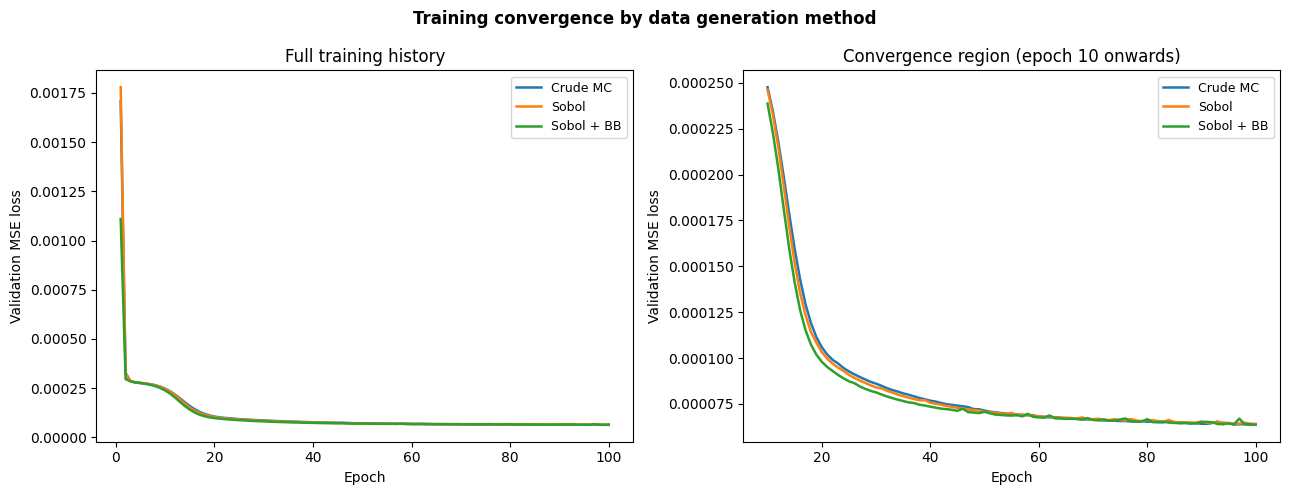


Saved data_generation_comparison.csv, .tex, and learning curves


In [34]:
# ============================================================
# 12b. Training comparison across data generation methods
# ============================================================

print("="*60)
print("Training comparison: data generation methods")
print(f"Fixed epochs: {MAX_EPOCHS}, Fixed test set: {len(paths_test):,} paths")
print("="*60)

comparison_results = []
comparison_histories = {}

methods = [
    ("Crude MC",   paths_tr_crude, paths_vl_crude),
    ("Sobol",      paths_tr_sobol, paths_vl_sobol),
    ("Sobol + BB", paths_tr_bb,    paths_vl_bb),
]

for label, paths_tr, paths_vl in methods:
    print(f"\nTraining: {label}")
    print("-"*40)
    he_te, hist_df, runtime, epochs, best_epoch, best_val = \
        train_comparison_model(
            paths_tr, paths_vl, cfg,
            label=label,
            seed=SEED_C,
            fixed_epochs=MAX_EPOCHS,
        )
    metrics = comparison_metrics(
        he_te, label, runtime, epochs, best_epoch, best_val)
    comparison_results.append(metrics)
    comparison_histories[label] = hist_df
    print(f"  Done. RMSE={metrics['RMSE']:.6f}, "
          f"CVaR95={metrics['CVaR95']:.6f}, "
          f"Runtime={metrics['Runtime (s)']:.1f}s")

# ── Results table ──
comp_df = pd.DataFrame(comparison_results)
comp_df.to_csv(out_dir/"data_generation_comparison.csv", index=False)

# Display
styled = (
    comp_df.style
    .set_caption(
        "Data generation method comparison. All models trained with "
        f"{N_COMPARE:,} paths, {MAX_EPOCHS} epochs max, evaluated on "
        f"fixed test set of {len(paths_test):,} crude MC paths.")
    .format({
        "RMSE":          "{:.6f}",
        "CVaR95":        "{:.6f}",
        "CVaR99":        "{:.6f}",
        "HE q01":        "{:.6f}",
        "HE q05":        "{:.6f}",
        "RMSE OTM":      "{:.6f}",
        "RMSE ATM":      "{:.6f}",
        "RMSE ITM":      "{:.6f}",
        "Best val loss": "{:.8f}",
        "Runtime (s)":   "{:.1f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th",
         "props": [("font-weight", "bold"), ("text-align", "center")]},
    ])
    .highlight_min(
        subset=["RMSE", "CVaR95", "CVaR99", "RMSE OTM", "RMSE ATM", "RMSE ITM"],
        color="#d4edda",  # green highlight for best
    )
)
display(styled)

# ── LaTeX ──
latex_cols = [
    "Method", "RMSE", "CVaR95", "CVaR99",
    "HE q01", "RMSE OTM", "RMSE ATM", "RMSE ITM",
    "Best epoch", "Runtime (s)",
]
latex_str = comp_df[latex_cols].to_latex(
    index=False, escape=False,
    caption=(
        r"Comparison of data generation methods for neural hedge training. "
        r"All models use the 64$\times$3 tanh/sigmoid shared Markov MLP "
        r"trained for a maximum of " + str(MAX_EPOCHS) + r" epochs on "
        + f"{N_COMPARE:,}" + r" paths. "
        r"OTM: $S_T < 0.85K$; ATM: $0.95K \leq S_T \leq 1.05K$; "
        r"ITM: $S_T > 1.15K$. "
        r"All methods evaluated on the same fixed test set of "
        + f"{len(paths_test):,}" + r" crude Monte Carlo paths."
    ),
    label="tab:data_generation",
)
with open(out_dir/"data_generation_comparison.tex", "w") as f:
    f.write(latex_str)

# ── Learning curves comparison ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Training convergence by data generation method",
    fontweight="bold", fontsize=12,
)
colours = {
    "Crude MC":   "#1f77b4",
    "Sobol":      "#ff7f0e",
    "Sobol + BB": "#2ca02c",
}

# Left: full history
ax = axes[0]
for label, hist_df in comparison_histories.items():
    ax.plot(hist_df["epoch"], hist_df["val_loss"],
            color=colours[label], lw=1.8, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation MSE loss")
ax.set_title("Full training history")
ax.legend(fontsize=9)

# Right: zoom from epoch 10
ax = axes[1]
for label, hist_df in comparison_histories.items():
    tail = hist_df[hist_df["epoch"] >= 10]
    ax.plot(tail["epoch"], tail["val_loss"],
            color=colours[label], lw=1.8, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation MSE loss")
ax.set_title("Convergence region (epoch 10 onwards)")
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(out_dir/"data_generation_learning_curves.png",
            dpi=180, bbox_inches="tight")
plt.show()

print("\nSaved data_generation_comparison.csv, .tex, and learning curves")

Path count experiment: Crude MC vs Sobol + BB
Fixed epochs: 100

Training: Crude MC | n=10,000
----------------------------------------


  [Crude MC | n=10,000] Epoch 001 | train 9.1818e-03 | val 7.4049e-03


  [Crude MC | n=10,000] Epoch 010 | train 1.6668e-03 | val 1.4651e-03


  [Crude MC | n=10,000] Epoch 020 | train 2.7325e-04 | val 2.7596e-04


  [Crude MC | n=10,000] Epoch 030 | train 2.6500e-04 | val 2.6955e-04


...

  [Sobol + BB | n=100,000] Epoch 070 | train 6.5957e-05 | val 6.6048e-05


  [Sobol + BB | n=100,000] Epoch 080 | train 6.4869e-05 | val 6.6096e-05


  [Sobol + BB | n=100,000] Epoch 090 | train 6.3786e-05 | val 6.4593e-05


  [Sobol + BB | n=100,000] Epoch 100 | train 6.3467e-05 | val 6.3608e-05
  Done. RMSE=0.007971, CVaR95=0.018481, Runtime=17.8s

--- RMSE by path count and method ---
method_clean  Crude MC  Sobol + BB
n_paths                           
10000         0.013328    0.015021
25000         0.009563    0.009617
50000         0.008431    0.008741
100000        0.008075    0.007971

--- CVaR95 by path count and method ---
method_clean  Crude MC  Sobol + BB
n_paths                           
10000         0.027356    0.030095
25000         0.021500    0.021614
50000         0.019302    0.019998
100000        0.018617    0.018481

--- RMSE OTM by path count and method ---
method_clean  Crude MC  Sobol + BB
n_paths                           
10000         0.013256    0.015400
25000         0.007936    0.007856
50000         0.006664    0.006969
100000        0.006485    0.006519


,Method,Paths,RMSE,CVaR95,RMSE OTM,RMSE ATM,RMSE ITM,Best epoch,Runtime (s)
0,Crude MC,10000,0.013328,0.027356,0.013256,0.021844,0.009683,100,4.1
1,Sobol + BB,10000,0.015021,0.030095,0.015400,0.023821,0.011558,100,4.0
2,Crude MC,25000,0.009563,0.021500,0.007936,0.015175,0.006904,100,6.6
3,Sobol + BB,25000,0.009617,0.021614,0.007856,0.015175,0.007092,99,6.5
4,Crude MC,50000,0.008431,0.019302,0.006664,0.012883,0.006193,100,10.2
5,Sobol + BB,50000,0.008741,0.019998,0.006969,0.013497,0.006391,100,10.4
6,Crude MC,100000,0.008075,0.018617,0.006485,0.012091,0.005940,99,18.3
7,Sobol + BB,100000,0.007971,0.018481,0.006519,0.011890,0.005798,100,17.8


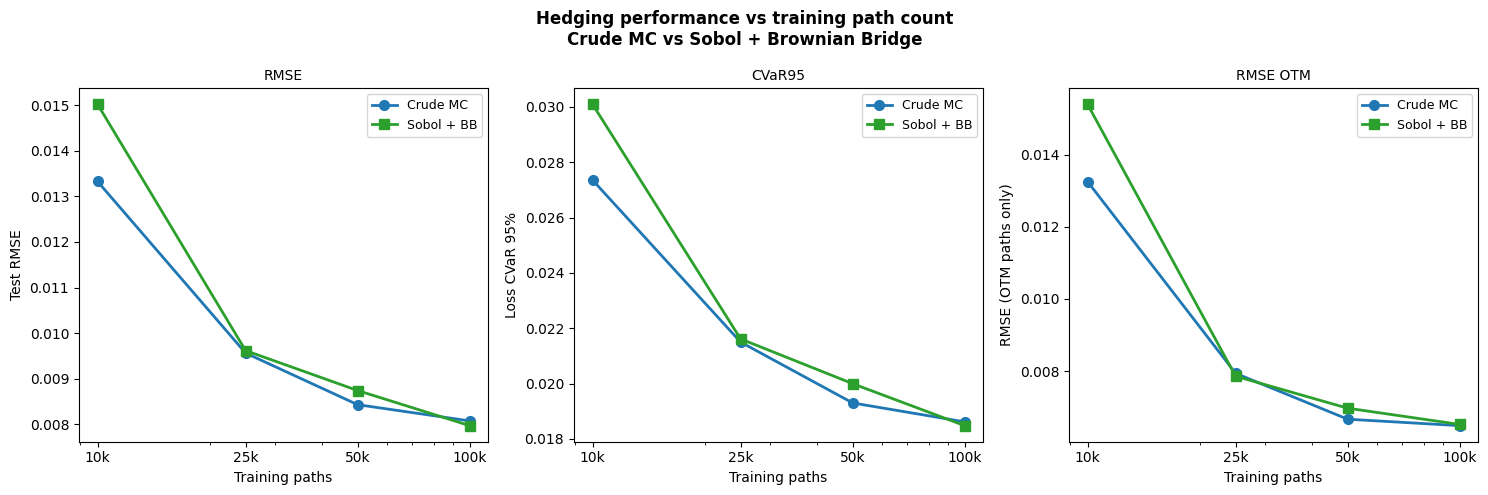

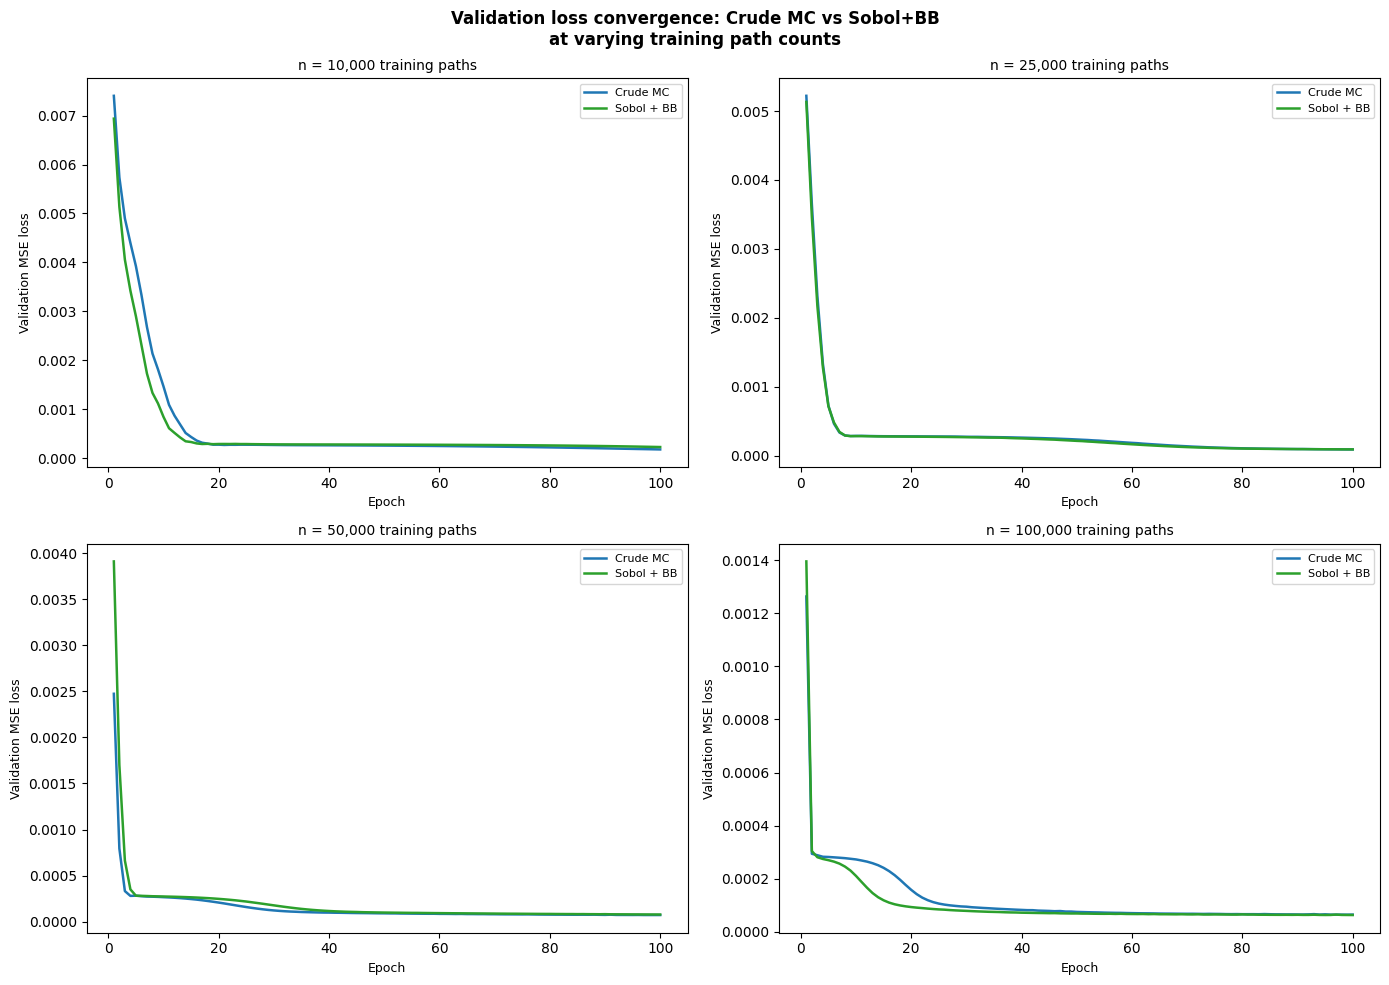


Saved path_count_comparison.csv, .tex, path_count_performance.png, path_count_learning_curves.png


In [35]:
# ============================================================
# 12c. Path count experiment
#      Crude MC vs Sobol+BB at varying training set sizes
# ============================================================

PATH_COUNTS = [10_000, 25_000, 50_000, 100_000]
FIXED_EPOCHS_PC = 100   # same fixed budget as before
SEED_PC         = 42

print("="*60)
print("Path count experiment: Crude MC vs Sobol + BB")
print(f"Fixed epochs: {FIXED_EPOCHS_PC}")
print("="*60)

path_count_results = []
path_count_histories = {}

for n_paths in PATH_COUNTS:
    for method_label, gen_fn in [
        ("Crude MC",   generate_crude_mc),
        ("Sobol + BB", generate_sobol_brownian_bridge),
    ]:
        label = f"{method_label} | n={n_paths:,}"
        print(f"\nTraining: {label}")
        print("-"*40)

        # Generate training and validation paths
        paths_tr = gen_fn(n_paths,  cfg, seed=SEED_PC)
        paths_vl = gen_fn(N_VAL_C,  cfg, seed=SEED_PC+1)

        he_te, hist_df, runtime, epochs, best_epoch, best_val = \
            train_comparison_model(
                paths_tr, paths_vl, cfg,
                label=label,
                seed=SEED_PC,
                fixed_epochs=FIXED_EPOCHS_PC,
            )

        metrics = comparison_metrics(
            he_te, label, runtime, epochs, best_epoch, best_val)
        metrics["n_paths"]      = n_paths
        metrics["method_clean"] = method_label
        path_count_results.append(metrics)
        path_count_histories[label] = hist_df

        print(f"  Done. RMSE={metrics['RMSE']:.6f}, "
              f"CVaR95={metrics['CVaR95']:.6f}, "
              f"Runtime={metrics['Runtime (s)']:.1f}s")

pc_df = pd.DataFrame(path_count_results)
pc_df.to_csv(out_dir/"path_count_comparison.csv", index=False)


# ── Display: pivot table format ──
print("\n--- RMSE by path count and method ---")
rmse_pivot = pc_df.pivot(
    index="n_paths", columns="method_clean", values="RMSE")
print(rmse_pivot.round(6).to_string())

print("\n--- CVaR95 by path count and method ---")
cvar_pivot = pc_df.pivot(
    index="n_paths", columns="method_clean", values="CVaR95")
print(cvar_pivot.round(6).to_string())

print("\n--- RMSE OTM by path count and method ---")
otm_pivot = pc_df.pivot(
    index="n_paths", columns="method_clean", values="RMSE OTM")
print(otm_pivot.round(6).to_string())


# ── Styled display table ──
display_cols = [
    "method_clean", "n_paths", "RMSE", "CVaR95",
    "RMSE OTM", "RMSE ATM", "RMSE ITM",
    "Best epoch", "Runtime (s)",
]
styled_pc = (
    pc_df[display_cols]
    .rename(columns={"method_clean": "Method", "n_paths": "Paths"})
    .style
    .set_caption(
        "Path count experiment: Crude MC vs Sobol+BB. "
        f"Fixed {FIXED_EPOCHS_PC} epochs, evaluated on same "
        f"{len(paths_test):,}-path test set.")
    .format({
        "RMSE":        "{:.6f}",
        "CVaR95":      "{:.6f}",
        "RMSE OTM":    "{:.6f}",
        "RMSE ATM":    "{:.6f}",
        "RMSE ITM":    "{:.6f}",
        "Runtime (s)": "{:.1f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th",
         "props": [("font-weight", "bold"), ("text-align", "center")]},
    ])
    .highlight_min(
        subset=["RMSE", "CVaR95", "RMSE OTM", "RMSE ATM", "RMSE ITM"],
        color="#d4edda",
    )
)
display(styled_pc)


# ── LaTeX ──
latex_pc = pc_df[display_cols].rename(
    columns={"method_clean": "Method", "n_paths": "Paths"}
).to_latex(
    index=False, escape=False,
    caption=(
        r"Path count experiment: Crude Monte Carlo vs Sobol with "
        r"Brownian bridge construction. All models use the "
        r"64$\times$3 tanh/sigmoid shared Markov MLP trained for "
        r"a fixed " + str(FIXED_EPOCHS_PC) + r" epochs. "
        r"OTM: $S_T < 0.85K$; ATM: $0.95K \leq S_T \leq 1.05K$; "
        r"ITM: $S_T > 1.15K$."
    ),
    label="tab:path_count",
)
with open(out_dir/"path_count_comparison.tex", "w") as f:
    f.write(latex_pc)


# ── Figure 1: RMSE vs path count ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Hedging performance vs training path count\n"
    "Crude MC vs Sobol + Brownian Bridge",
    fontweight="bold", fontsize=12,
)

crude_df = pc_df[pc_df["method_clean"] == "Crude MC"].sort_values("n_paths")
sobol_df = pc_df[pc_df["method_clean"] == "Sobol + BB"].sort_values("n_paths")

metrics_plot = [
    ("RMSE",     "Test RMSE",    "RMSE"),
    ("CVaR95",   "Loss CVaR 95%", "CVaR95"),
    ("RMSE OTM", "RMSE (OTM paths only)", "RMSE OTM"),
]

for ax, (col, ylabel, title) in zip(axes, metrics_plot):
    ax.plot(crude_df["n_paths"], crude_df[col],
            color="#1f77b4", lw=2.0, marker="o",
            markersize=7, label="Crude MC")
    ax.plot(sobol_df["n_paths"], sobol_df[col],
            color="#2ca02c", lw=2.0, marker="s",
            markersize=7, label="Sobol + BB")
    ax.set_xlabel("Training paths", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_xscale("log")
    ax.set_xticks(PATH_COUNTS)
    ax.set_xticklabels([f"{n//1000}k" for n in PATH_COUNTS])
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(out_dir/"path_count_performance.png",
            dpi=180, bbox_inches="tight")
plt.show()


# ── Figure 2: Learning curves at each path count ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Validation loss convergence: Crude MC vs Sobol+BB\n"
    "at varying training path counts",
    fontweight="bold", fontsize=12,
)

for ax, n_paths in zip(axes.flat, PATH_COUNTS):
    for method, colour in [("Crude MC", "#1f77b4"),
                            ("Sobol + BB", "#2ca02c")]:
        key  = f"{method} | n={n_paths:,}"
        hist = path_count_histories[key]
        ax.plot(hist["epoch"], hist["val_loss"],
                color=colour, lw=1.8, label=method)
    ax.set_title(f"n = {n_paths:,} training paths", fontsize=10)
    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel("Validation MSE loss", fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(out_dir/"path_count_learning_curves.png",
            dpi=180, bbox_inches="tight")
plt.show()

print("\nSaved path_count_comparison.csv, .tex, "
      "path_count_performance.png, path_count_learning_curves.png")

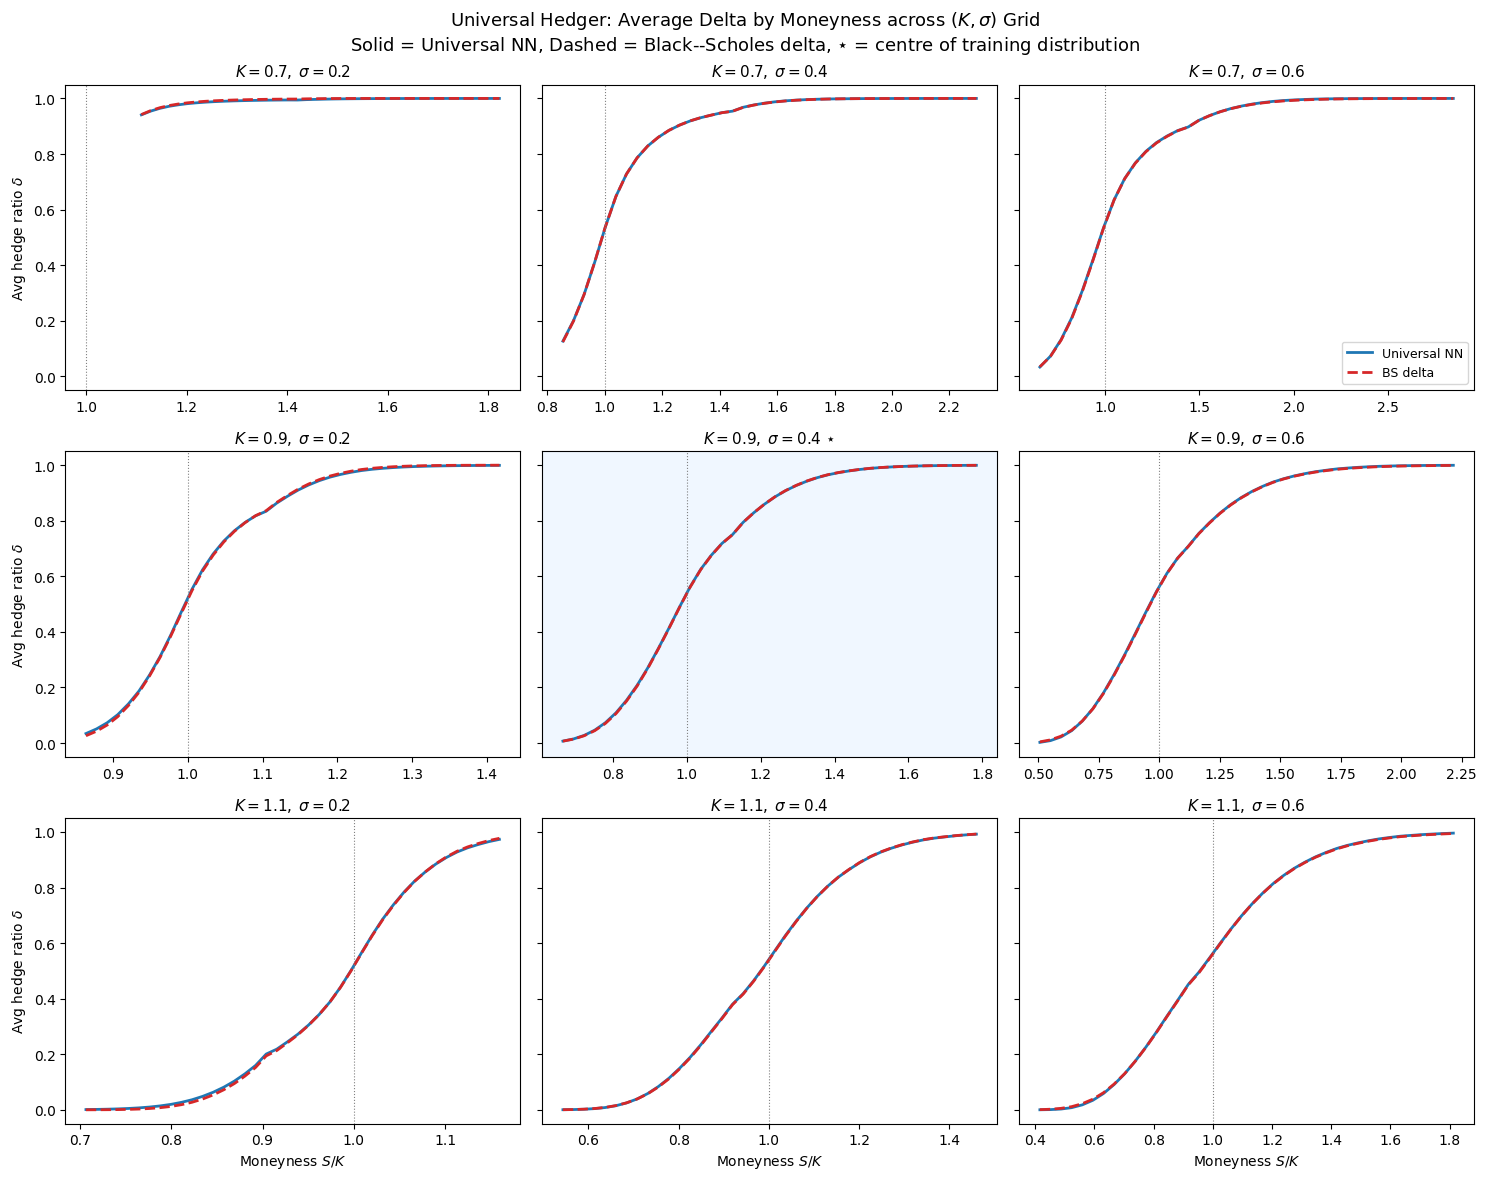

Saved universal_delta_curves_3x3.png


In [36]:
# ── 3x3 Delta curves: universal NN vs BS delta across full (K, sigma) grid ──

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)

K_axis     = [0.7, 0.9, 1.1]
sigma_axis = [0.2, 0.4, 0.6]
n_plot     = 30_000
n_bins     = 40

for i, K_val in enumerate(K_axis):
    for j, sigma_val in enumerate(sigma_axis):
        ax = axes[i, j]

        rng_p   = np.random.default_rng(42)
        K_arr   = np.full(n_plot, K_val,   dtype=np.float32)
        sig_arr = np.full(n_plot, sigma_val, dtype=np.float32)

        paths_p  = simulate_universal_paths(
            n_plot, cfg.N, cfg.T, cfg.S0, cfg.r,
            K_arr, sig_arr, rng_p)
        payoff_p = make_payoff(paths_p, K_arr)
        prem_p   = bs_price_scenario(K_arr, sig_arr)

        # Universal NN deltas
        feat_p      = make_features_universal(
            paths_p, K_arr, sig_arr, cfg.N, cfg.T)
        _, deltas_p = univ_model(
            (tf.constant(feat_p),
             tf.constant(paths_p),
             tf.constant(payoff_p),
             tf.constant(prem_p)),
            training=False,
        )
        deltas_nn_p = deltas_p.numpy()

        # BS delta
        dt_eval_p   = cfg.T / cfg.N
        tau_g_p     = cfg.T - np.arange(cfg.N) * dt_eval_p
        S_p         = paths_p[:, :-1].astype(np.float64)
        tau_2d_p    = np.maximum(tau_g_p[None, :], 1e-12)
        deltas_bs_p = bs_delta_scenario(S_p, tau_2d_p, K_val, sigma_val)

        # Bin by moneyness S/K
        moneyness   = (paths_p[:, :-1] / K_val).reshape(-1)
        delta_nn_f  = deltas_nn_p.reshape(-1)
        delta_bs_f  = deltas_bs_p.reshape(-1)

        lo   = np.quantile(moneyness, 0.01)
        hi   = np.quantile(moneyness, 0.99)
        bins    = np.linspace(lo, hi, n_bins + 1)
        centers = 0.5 * (bins[:-1] + bins[1:])

        mean_nn = []
        mean_bs = []
        for b in range(n_bins):
            mask = (moneyness >= bins[b]) & (moneyness < bins[b+1])
            mean_nn.append(np.mean(delta_nn_f[mask]) if mask.any() else np.nan)
            mean_bs.append(np.mean(delta_bs_f[mask]) if mask.any() else np.nan)

        ax.plot(centers, mean_nn, color="#1f77b4", lw=2.0,
                label="Universal NN")
        ax.plot(centers, mean_bs, color="#d62728", lw=2.0,
                ls="--", label="BS delta")
        ax.axvline(1.0, color="grey", lw=0.8, ls=":")

        # Mark training centre
        if K_val == 0.9 and sigma_val == 0.4:
            ax.set_facecolor("#f0f7ff")
            ax.set_title(
                f"$K={K_val},\\;\\sigma={sigma_val}$ $\\star$",
                fontsize=11, fontweight="bold"
            )
        else:
            ax.set_title(
                f"$K={K_val},\\;\\sigma={sigma_val}$",
                fontsize=11
            )

        ax.set_ylim(-0.05, 1.05)

        # Only label outer axes to keep it clean
        if i == 2:
            ax.set_xlabel("Moneyness $S/K$", fontsize=10)
        if j == 0:
            ax.set_ylabel("Avg hedge ratio $\\delta$", fontsize=10)

        # Only show legend in top-right panel
        if i == 0 and j == 2:
            ax.legend(fontsize=9)

fig.suptitle(
    "Universal Hedger: Average Delta by Moneyness across $(K, \\sigma)$ Grid\n"
    "Solid = Universal NN, Dashed = Black--Scholes delta, "
    "$\\star$ = centre of training distribution",
    fontsize=13,
)
plt.tight_layout()
fig.savefig(out_dir/"universal_delta_curves_3x3.png", dpi=180)
plt.show()
print("Saved universal_delta_curves_3x3.png")

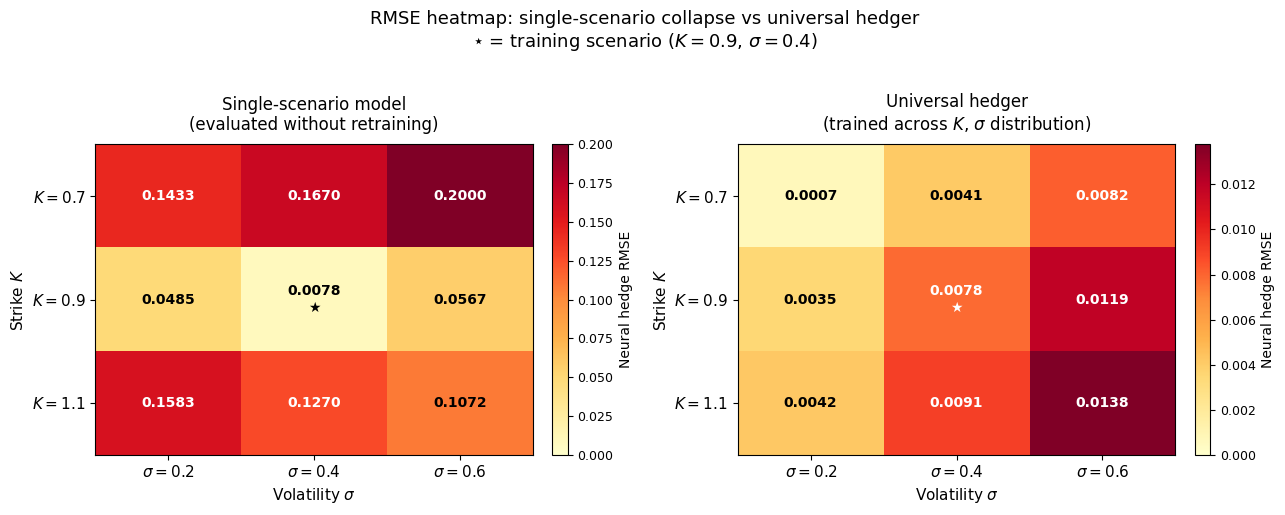

Saved universal_heatmap.png


In [37]:
import matplotlib.colors as mcolors

K_axis     = [0.7, 0.9, 1.1]
sigma_axis = [0.2, 0.4, 0.6]

single_rmse = np.array([
    [rob_df[(rob_df["K"]==K_val) & (rob_df["sigma"]==sig_val)]["NN RMSE"].values[0]
     for sig_val in sigma_axis]
    for K_val in K_axis
], dtype=np.float64)

univ_rmse = np.array([
    [univ_df[univ_df["K"].str.contains(str(K_val)) &
             univ_df["σ"].str.contains(str(sig_val))]["Universal NN RMSE"].values[0]
     for sig_val in sigma_axis]
    for K_val in K_axis
], dtype=np.float64)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

configs = [
    {
        "matrix":  single_rmse,
        "title":   "Single-scenario model\n(evaluated without retraining)",
        "cmap":    "YlOrRd",
        "vmin":    0.0,
        "vmax":    single_rmse.max(),
        "clabel":  "Neural hedge RMSE",
    },
    {
        "matrix":  univ_rmse,
        "title":   "Universal hedger\n(trained across $K$, $\\sigma$ distribution)",
        "cmap":    "YlOrRd",
        "vmin":    0.0,
        "vmax":    univ_rmse.max(),
        "clabel":  "Neural hedge RMSE",
    },
]

for ax, cfg_p in zip(axes, configs):
    norm = mcolors.Normalize(vmin=cfg_p["vmin"], vmax=cfg_p["vmax"])
    im   = ax.imshow(
        cfg_p["matrix"],
        norm=norm,
        cmap=cfg_p["cmap"],
        aspect="auto",
    )

    ax.set_xticks(range(len(sigma_axis)))
    ax.set_xticklabels([f"$\\sigma={s}$" for s in sigma_axis], fontsize=11)
    ax.set_yticks(range(len(K_axis)))
    ax.set_yticklabels([f"$K={k}$" for k in K_axis], fontsize=11)
    ax.set_xlabel("Volatility $\\sigma$", fontsize=11)
    ax.set_ylabel("Strike $K$", fontsize=11)
    ax.set_title(cfg_p["title"], fontsize=12, pad=10)

    # Annotate cells
    for i in range(len(K_axis)):
        for j in range(len(sigma_axis)):
            val        = cfg_p["matrix"][i, j]
            brightness = (val - cfg_p["vmin"]) / (cfg_p["vmax"] - cfg_p["vmin"])
            txt_color  = "white" if brightness > 0.55 else "black"
            star       = "\n★" if (K_axis[i]==0.9 and sigma_axis[j]==0.4) else ""
            ax.text(j, i, f"{val:.4f}{star}",
                    ha="center", va="center",
                    fontsize=10, color=txt_color, fontweight="bold")

    # Individual colorbar per panel
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cfg_p["clabel"], fontsize=10)
    cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "RMSE heatmap: single-scenario collapse vs universal hedger\n"
    "$\\star$ = training scenario ($K=0.9$, $\\sigma=0.4$)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
fig.savefig(out_dir/"universal_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved universal_heatmap.png")

/tmp/ipykernel_107416/2087774218.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


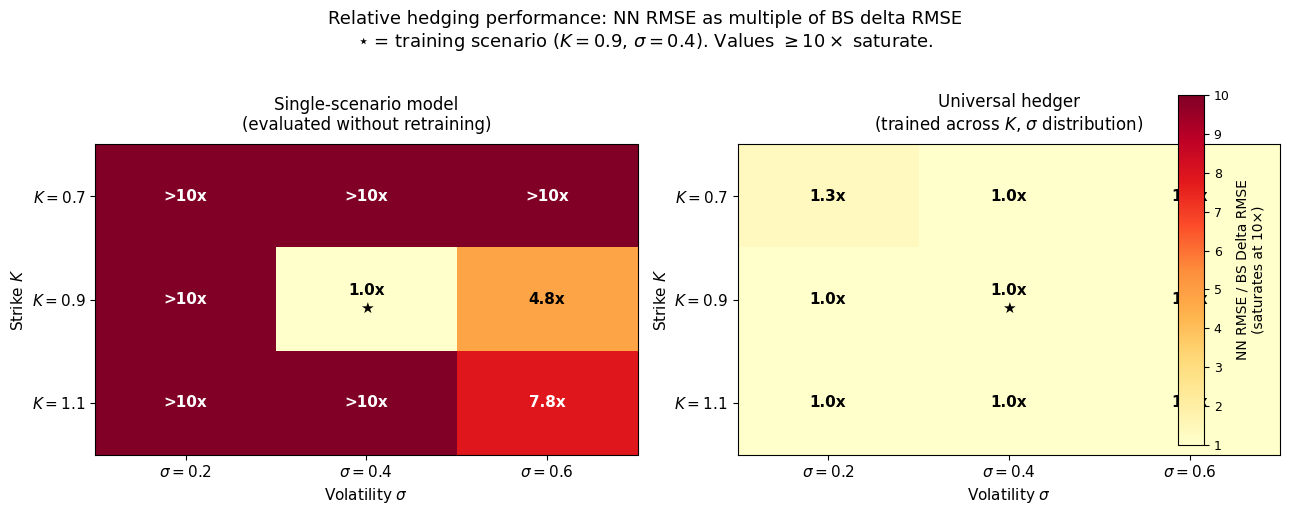

Saved universal_heatmap.png


In [38]:
# ── RMSE ratio heatmap: NN/BS across both models ──

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

K_axis     = [0.7, 0.9, 1.1]
sigma_axis = [0.2, 0.4, 0.6]

# ── Build ratio matrices ──
# Single-scenario: NN RMSE / BS RMSE (without retraining)
single_ratio = np.array([
    [rob_df[(rob_df["K"]==K_val) & (rob_df["sigma"]==sig_val)]["NN RMSE"].values[0] /
     rob_df[(rob_df["K"]==K_val) & (rob_df["sigma"]==sig_val)]["BS RMSE"].values[0]
     for sig_val in sigma_axis]
    for K_val in K_axis
], dtype=np.float64)

# Universal hedger: Universal NN RMSE / BS RMSE
# Pull BS RMSE from univ_df
univ_ratio = np.array([
    [univ_df[univ_df["K"].str.contains(str(K_val)) &
             univ_df["σ"].str.contains(str(sig_val))]["Universal NN RMSE"].values[0] /
     univ_df[univ_df["K"].str.contains(str(K_val)) &
             univ_df["σ"].str.contains(str(sig_val))]["BS Delta RMSE"].values[0]
     for sig_val in sigma_axis]
    for K_val in K_axis
], dtype=np.float64)

# ── Shared colour scale ──
# Cap at 10x so the universal hedger variation is visible
# Single-scenario failures (20x-200x) will saturate at the top
vmin = 1.0
vmax = 10.0
cmap = "YlOrRd"
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

titles = [
    "Single-scenario model\n(evaluated without retraining)",
    "Universal hedger\n(trained across $K$, $\\sigma$ distribution)",
]
matrices = [single_ratio, univ_ratio]

for ax, matrix, title in zip(axes, matrices, titles):
    im = ax.imshow(
        np.clip(matrix, vmin, vmax),
        norm=norm,
        cmap=cmap,
        aspect="auto",
    )

    ax.set_xticks(range(len(sigma_axis)))
    ax.set_xticklabels([f"$\\sigma={s}$" for s in sigma_axis], fontsize=11)
    ax.set_yticks(range(len(K_axis)))
    ax.set_yticklabels([f"$K={k}$" for k in K_axis], fontsize=11)
    ax.set_xlabel("Volatility $\\sigma$", fontsize=11)
    ax.set_ylabel("Strike $K$", fontsize=11)
    ax.set_title(title, fontsize=12, pad=10)

    for i in range(len(K_axis)):
        for j in range(len(sigma_axis)):
            val        = matrix[i, j]
            brightness = (min(val, vmax) - vmin) / (vmax - vmin)
            txt_color  = "white" if brightness > 0.55 else "black"
            star       = "\n★" if (K_axis[i]==0.9 and sigma_axis[j]==0.4) else ""
            # Show ">10x" for saturated cells
            label = f">{vmax:.0f}x" if val >= vmax else f"{val:.1f}x"
            ax.text(j, i, f"{label}{star}",
                    ha="center", va="center",
                    fontsize=11, color=txt_color, fontweight="bold")

# ── Single shared colorbar ──
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("NN RMSE / BS Delta RMSE\n(saturates at 10×)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "Relative hedging performance: NN RMSE as multiple of BS delta RMSE\n"
    "$\\star$ = training scenario ($K=0.9$, $\\sigma=0.4$). "
    "Values $\\geq 10\\times$ saturate.",
    fontsize=13, y=1.02,
)
plt.tight_layout()
fig.savefig(out_dir/"universal_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved universal_heatmap.png")

## Report wording template

After running this notebook, the benchmark table can be described in the report using wording like:

> The neural hedge was compared against an unhedged short-call position, the standard Black--Scholes delta hedge sampled on the discrete rebalancing grid, a discrete-time MSE-optimal hedge, and a polynomial approximation to the discrete-time optimal hedge. The discrete-time MSE-optimal hedge is the fairest analytic benchmark because it matches the finite rebalancing grid and mean-square objective used to train the neural network. The neural network is not expected to materially outperform this benchmark under the correctly specified Black--Scholes model; rather, strong performance is indicated by matching its hedging-error distribution and producing a learned premium close to the analytic Black--Scholes price.

Remember the sign convention:

\[
HE = V_T - \Phi(S_T).
\]

Thus, more negative lower-tail hedge errors correspond to larger seller shortfalls.